# Orexigenic Drive & Always-On Homeostasis — Analysis

**System under study:** the *Orexigenic Drive* of the `alwaysOn-embodiedBehaviour`
iCub controller (perception → salience → executive → remote/Telegram).

**Research questions**

- **RQ1** — To what extent does the orexigenic drive fulfil the four functions of
  classical homeostasis: (1) internal monitoring, (2) deficit detection,
  (3) deficit-to-action conversion, (4) behavioural prioritisation?
- **RQ2** — Does the expression of an orexigenic deficit promote recovery-oriented
  engagement sufficient to support reliable energy replenishment in an always-on
  social robot?
- **RQ3** — Does the robot's **adaptive component** (per-person homeostatic affinity)
  reflect *real* participant behaviour rather than arbitrary drift, and does what it learns
  change its later behaviour? The **role manipulation is experiment metadata only**: roles
  were assigned by the researchers for validation and were never available to the robot or
  used by the software.

> **Fixed design fact (single condition).** The drive was **always on** for the whole
> study. RQ2 is identified from the **within-drive graded deficit**
> (Full → Hungry → Starving) and from the **proactive vs reactive**
> contrast. *The graded deficit is the manipulation.*

> **Second design fact (two phases, role manipulation).** The deployment ran in **two
> 4-day phases**. In **Phase 1** (first four experiment days) participants had assigned
> roles: two **obligated feeders** (feed several times a day), two **interact-but-never-feed**
> participants, and everyone else **unconstrained**. In **Phase 2** (last four days) all
> constraints were lifted and everyone behaved normally. The role map is private
> (`analysis/private/role_phase.json`, pseudonymised on load). These roles are **external
> experimental labels**, not controller inputs; RQ3 (analysis B10) uses them only after the
> fact as a *manipulation check + validation* of the affinity learning. With only
> **2 people per controlled role**, role contrasts are validation evidence with wide
> uncertainty, not population inference.

**Data-layout note (discovered, not assumed).** The eight dated folders under `data/`
are **cumulative snapshots of one continuously-growing database** — each later folder
is a strict superset of the earlier ones. We therefore de-duplicate to the true unit
of analysis, the **run** (`run_id`, 10 runs) grouped by data-collection **day**
(`day_rome`, 8 days). Naive concatenation across folders would 4–5× double-count; we
do not do that. This is verified in Phase 0.2 and the verification gate.

## Setup — imports, seed, configuration, palette

In [1]:

# --- Single setup cell: imports, global seed, config, output dirs, palette ---
from __future__ import annotations
import os, re, json, sqlite3, warnings, glob, math, itertools, textwrap
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
import random; random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

# ---- Config -------------------------------------------------------------------
# DATA_ROOT auto-discovery: env override -> ./data -> repo root.
def _find_data_root():
    env = os.getenv("DATA_ROOT")
    if env and Path(env).is_dir():
        return Path(env)
    here = Path.cwd()
    for base in [here] + list(here.parents):
        if (base / "data").is_dir() and any((base / "data").glob("*/data_collection")):
            return base / "data"
        if any(base.glob("*/data_collection/executive_control.db")):
            return base
    return here / "data"

DATA_ROOT = _find_data_root()
REPO_ROOT = DATA_ROOT.parent if DATA_ROOT.name == "data" else DATA_ROOT

ANALYSIS_DIR = REPO_ROOT / "analysis"
CACHE_DIR    = ANALYSIS_DIR / "cache"
OUT_DIR      = ANALYSIS_DIR / "outputs"
FIG_DIR      = ANALYSIS_DIR / "figures"
for d in (CACHE_DIR, OUT_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- HS colour palette (mirrored from stomachMonitor.py, liquid colour) -------
# Internal DB state codes are HS1/HS2/HS3; we DISPLAY them as Full/Hungry/Starving
# everywhere (figures, tables, text). HS_ORDER holds the data keys; HS_NAMES the labels.
# Categorical-validated (lightness band + CVD separation + chroma): marks carrying data
# always pair these fills with direct value labels (the contrast-relief obligation).
HS_PALETTE = {"HS1": "#4FB98A", "HS2": "#E3A32E", "HS3": "#E5654D", "HS0": "#AEB4BA"}
HS_ACCENT  = {"HS1": "#2C8A60", "HS2": "#B9821C", "HS3": "#B23A26", "HS0": "#6E767D"}
HS_LABEL   = {"HS1": "Full", "HS2": "Hungry", "HS3": "Starving", "HS0": "N/A"}
HS_ORDER   = ["HS1", "HS2", "HS3"]                       # data keys (do not change)
HS_NAME    = {"HS1": "Full", "HS2": "Hungry", "HS3": "Starving", "HS0": "N/A"}
HS_NAMES   = ["Full", "Hungry", "Starving"]             # display labels, same order as HS_ORDER
def hsn(x):
    "Map a state code (or iterable of codes) to its display name Full/Hungry/Starving."
    if isinstance(x, str): return HS_NAME.get(x, x)
    return [HS_NAME.get(v, v) for v in x]

# Social-state display names (data keys ss1..ss4 stay internal). Source SS_DESCRIPTIONS:
# ss1 Unknown, ss2 Known-not-greeted, ss3 Known-greeted, ss4 Talked.
SS_NAME  = {"ss1": "Stranger", "ss2": "Recognized", "ss3": "Greeted", "ss4": "Engaged"}

# --- Identity resolution & pseudonymization (privacy-first) ----------------------------
# Two layers, applied to the same identity columns:
#  1) Canonicalization merges case/spelling variants of the same person and remaps
#     excluded participants to "unknown". The map lives in analysis/private/
#     identity_canon.json (git-ignored) so no real name appears in this notebook.
#  2) Pseudonymization replaces every real identity with a stable code (P01, P02, ...)
#     assigned by first appearance (cell A1b). The real-name mapping is written to
#     analysis/private/ only — published figures/tables/CSVs carry codes exclusively.
PRIVATE_DIR = ANALYSIS_DIR / "private"
PRIVATE_DIR.mkdir(exist_ok=True)
_canon_path = PRIVATE_DIR / "identity_canon.json"
CANON_IDENTITY = json.loads(_canon_path.read_text()) if _canon_path.exists() else {}
if not CANON_IDENTITY:
    print("WARNING: analysis/private/identity_canon.json missing — name variants will not merge.")
IDENTITY_COLS = ("person_id", "face_id", "extracted_name", "user_key")
def canon_identity(v):
    "Canonicalise a single identity string; pass through non-strings and unlisted names."
    if not isinstance(v, str): return v
    return CANON_IDENTITY.get(v.strip().lower(), v)

PSEUDONYM_PRESERVE = {"unknown", "unmatched", ""}   # placeholders, not people
PSEUDONYM_MAP = {}                     # real identity -> P## (seeded in cell A1b)
PSEUDONYMS_ACTIVE = False              # flipped on once the map is seeded
def pseudonymize(v):
    "Replace a real identity with its stable pseudonym; unseen identities get the next code."
    if not isinstance(v, str): return v
    key = v.strip()
    if key.lower() in PSEUDONYM_PRESERVE or re.fullmatch(r"P\d{2,}", key): return v
    if key not in PSEUDONYM_MAP:
        PSEUDONYM_MAP[key] = f"P{len(PSEUDONYM_MAP)+1:02d}"
    return PSEUDONYM_MAP[key]
def apply_pseudonyms(df):
    "Replace real names with pseudonyms in every identity column (no-op until seeded)."
    if not PSEUDONYMS_ACTIVE: return df
    for c in IDENTITY_COLS:
        if c in df.columns and df[c].dtype == object:
            df[c] = df[c].map(pseudonymize)
    return df

# Recessive grid/axes, constrained_layout ON (prevents title/tick collisions in
# every multi-panel figure), consistent typography. Ink colours for text so labels
# never wear a series colour.
INK, MUTED, GRID = "#22282E", "#5A6470", "#C7CDD4"
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 220, "savefig.bbox": "tight",
    "figure.constrained_layout.use": True,
    "figure.constrained_layout.h_pad": 0.06,
    "figure.constrained_layout.w_pad": 0.04,
    "figure.constrained_layout.hspace": 0.08,
    "figure.constrained_layout.wspace": 0.04,
    "savefig.pad_inches": 0.15,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": GRID, "grid.alpha": 0.6,
    "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.linewidth": 0.9,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlepad": 8, "axes.labelsize": 11, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 9.5,
    "font.family": "DejaVu Sans",
})

def savefig(fig, name):
    "Save a figure to analysis/figures as PNG + SVG at >=220 dpi."
    fig.set_constrained_layout_pads(w_pad=0.04, h_pad=0.06, wspace=0.04, hspace=0.08)
    for ext in ("png", "svg"):
        fig.savefig(FIG_DIR / f"{name}.{ext}", dpi=220)
    print(f"  saved figures/{name}.png + .svg")

def bars_with_ci(ax, cats, means, los, his, colors, n_labels=None, small_flag=None,
                 value_fmt="{:.2f}"):
    "Vertical bars with asymmetric CI whiskers, direct value labels, optional n= and small-n hatch."
    x = np.arange(len(cats))
    for i, c in enumerate(cats):
        hatch = "//" if (small_flag and small_flag[i]) else None
        ax.bar(x[i], means[i], color=colors[i], edgecolor="white", linewidth=1.2,
               width=0.72, hatch=hatch, zorder=3)
    ax.errorbar(x, means, yerr=[los, his], fmt="none", ecolor=INK, elinewidth=1.3,
                capsize=4, capthick=1.3, zorder=4)
    for i in range(len(cats)):
        top = means[i] + his[i]
        ax.annotate(value_fmt.format(means[i]), (x[i], top), textcoords="offset points",
                    xytext=(0, 4), ha="center", va="bottom", fontsize=9.5, color=INK, fontweight="medium")
        if n_labels is not None:
            ax.annotate(f"n={n_labels[i]}", (x[i], 0), textcoords="offset points",
                        xytext=(0, 3), ha="center", va="bottom", fontsize=8, color="white", fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(cats)
    ax.margins(x=0.08)

# Print paths with $HOME redacted: the username must never appear in published
# notebook output (the leak checker treats it as an identity string).
def show_path(p): return str(p).replace(str(Path.home()), "~")
print("DATA_ROOT :", show_path(DATA_ROOT))
print("REPO_ROOT :", show_path(REPO_ROOT))
print("outputs   :", show_path(OUT_DIR))

DATA_ROOT : ~/Desktop/orexigenic-drive-analysis/data
REPO_ROOT : ~/Desktop/orexigenic-drive-analysis
outputs   : ~/Desktop/orexigenic-drive-analysis/analysis/outputs


## Phase 0 — Ground truth: read the code, then the data

### 0.1 Ground-truth constants (read from source)

Extracted directly from the controller source (`alwaysOn-embodiedBehaviour/modules/`),
not from memory. File:line references given for auditability.

**`executiveControl.py` — `HungerModel` / drive logic**

| Constant | Value | Source |
|---|---|---|
| `drain_hours` (time to empty) | **4.0 h** | `HungerModel.__init__` L107; `configure` L1074 |
| passive drain rate | `100/(4·3600)` = **6.94e-3 %/s** | `_drain` L184 |
| `hungry_threshold` (HS1↔HS2) | **60.0** | L108, L1075 |
| `starving_threshold` (HS2↔HS3) | **25.0** | L109, L1076 |
| HS mapping | level≥60→**Full** (HS1), 25≤level<60→**Hungry** (HS2), level<25→**Starving** (HS3) | `snapshot` L241-246 |

> **Naming.** The controller's state codes are `HS1`/`HS2`/`HS3`; throughout this notebook we
> display them as **Full** / **Hungry** / **Starving** (the codes remain the data keys).
| Meal deltas | `SMALL=10`, `MEDIUM=25`, `LARGE=45` | `_meal_mapping` L987 |
| QR cooldown | **3.0 s** | `_qr_cooldown_sec` L988 |
| feed-wait timeout | **8.0 s** | `_feed_wait_timeout_sec` L989 |
| HS3 feeding-tree override | `_run_hunger_tree` L2329 | see below |
| DB file | `data_collection/executive_control.db` | `DB_FILE` L875 |

**Active metabolic energy costs (charged via `_charge_energy` / `exert`)**

| Constant | Value | Action label(s) |
|---|---|---|
| `CONVERSATION_TURN_ENERGY_COST` | **3.6** | `ss3_conversation_turn` |
| `STARTER_PROMPT_ENERGY_COST` | **1.2** | `ss3_starter` |
| `NAME_QUESTION_ENERGY_COST` | **1.0** | `ss1_ask_name`, `ss1_ask_name_retry` |
| `HUNGER_PROMPT_ENERGY_COST` | **1.0** | `hunger_ask_feed`, `hunger_still_hungry`, `hunger_look_around` |
| `GREETING_ENERGY_COST` | **0.8** | `ss1_greeting`, `ss1_nice_to_meet`, `known_greeting`, reactive greetings |
| `FEED_ACK_ENERGY_COST` | **0.8** | `feed_ack`, `ambient_feed_ack` |

**HS3 feeding-tree override (`_run_hunger_tree`, L2329).** On HS3 the executive stops
the social agenda and enters a feed-seeking loop: it *asks to be fed* (`hunger_ask_feed`),
waits up to 8 s for a QR meal, acknowledges each feed (`feed_ack`), says
`hunger_still_hungry` and loops until the state climbs back to **HS1**, or aborts with
`no_food_qr` after 2 consecutive timeouts. This is the coded behavioural-prioritisation
mechanism tested in B4.

**`salienceNetwork.py`**

| Constant | Value | Source |
|---|---|---|
| `BASELINE_WEIGHTS` | prox 0.5, cent 0.15, gaze 0.5 | L141 |
| `SS_THRESHOLDS` | ss1 0.80, ss2 0.65, ss3 0.70, ss4 0.85 | L144 |
| `HABITUATION_LAMBDA` | 0.06 (~11.6 s half-life) | L151 |
| affinity EMA | `ALPHA=0.25`, `ALPHA_NEG=0.10`, `REWARD_SCALE=25`, `PENALTY_FLOOR=-0.3` | L155-160 |
| affinity→threshold | `GAIN=0.15`, `FLOOR=0.50` (`eff_thr = max(FLOOR, base − GAIN·affinity)`) | L161-162, L1360 |
| IPS image normalisation | 640×480 | `_compute_ips` L1381 |
| `SS_DESCRIPTIONS` | ss1 Unknown / ss2 Known,NotGreeted / ss3 Known,Greeted,NoTalk / ss4 Talked | L171 |
| DB file | `data_collection/salience_network.db` | L282 |

> **Social-state naming.** The controller's codes `ss1`/`ss2`/`ss3`/`ss4` are displayed
> throughout as **Stranger** / **Recognized** / **Greeted** / **Engaged** (codes remain the data keys).

**`chatBot.py` (Telegram, proactive)** — `HS_DWELL_SEC=60` (debounce a flapping drive
before proactive logic acts), `HS2_ENTRY_MIN_INTERVAL=30 min`,
`HS3_RECOVERY_MIN_INTERVAL=30 min`; proactive event types `hs2_entry`, `hs3_proactive`,
`hs3_recovery`; a debounced `_stable_hs` latch (L163) motivates B2's flapping analysis.
DB `data_collection/chat_bot.db` (L110).

**`vision.py`** — `landmark_events` schema (gaze/attention/zone/distance/`faces_in_frame`);
DB `data_collection/vision.db` (L128).

**`stomachMonitor.py`** — HS colour palette (reused in every figure): HS1/**Full** green `#5BCB97`,
HS2/**Hungry** amber `#F4BB52`, HS3/**Starving** red `#ED7059`, HS0 grey `#AEB4BA` (L72-75).

**`prompts.json`** — the deficit is verbalised as *"I'm so hungry, would you feed me
please?"* (`hunger_ask_feed`), *"I'm still hungry. Give me more please."*
(`hunger_still_hungry`), and HS3 feed-ack *"Oh wow, thank you {name}! You literally just
saved my life!"* — the coded gates behind the B3 framing numbers.

In [2]:

# Ground-truth constants recorded as data (used by the verification gate V1/V5).
CONST = dict(
    DRAIN_HOURS=4.0, HUNGRY_THRESHOLD=60.0, STARVING_THRESHOLD=25.0,
    DRAIN_RATE_PER_SEC=100.0 / (4.0 * 3600.0),          # nominal passive drain
    MEALS={"SMALL_MEAL": 10.0, "MEDIUM_MEAL": 25.0, "LARGE_MEAL": 45.0},
    QR_COOLDOWN_SEC=3.0, FEED_WAIT_TIMEOUT_SEC=8.0,
    ACTIVE_COST={
        "ss3_conversation_turn": 3.6, "ss3_starter": 1.2,
        "ss1_ask_name": 1.0, "ss1_ask_name_retry": 1.0,
        "hunger_ask_feed": 1.0, "hunger_still_hungry": 1.0, "hunger_look_around": 1.0,
        "known_greeting": 0.8, "ss1_greeting": 0.8, "ss1_nice_to_meet": 0.8,
        "feed_ack": 0.8, "ambient_feed_ack": 0.8,
        "reactive_unknown_greeting": 0.8, "reactive_nice_to_meet": 0.8,
    },
    SS_THRESHOLDS={"ss1": 0.80, "ss2": 0.65, "ss3": 0.70, "ss4": 0.85},
    BASELINE_WEIGHTS={"prox": 0.5, "cent": 0.15, "gaze": 0.5},
    HABITUATION_LAMBDA=0.06, IMG_W=640.0, IMG_H=480.0,
)
print("Nominal passive drain rate: %.6f %%/s  (empty in %.1f h)"
      % (CONST["DRAIN_RATE_PER_SEC"], CONST["DRAIN_HOURS"]))

Nominal passive drain rate: 0.006944 %/s  (empty in 4.0 h)


### 0.2 Data layout discovery + de-duplication to the run/day unit

In [3]:

# Auto-discover session folders that contain a data_collection dir with the 4 DBs.
DB_KINDS = {
    "executive": "executive_control.db",
    "salience":  "salience_network.db",
    "vision":    "vision.db",
    "chat":      "chat_bot.db",
}
def discover_sessions(root: Path):
    sessions = {}
    for dc in sorted(root.glob("*/data_collection")):
        folder = dc.parent.name
        present = {k: (dc / fn) for k, fn in DB_KINDS.items() if (dc / fn).exists()}
        if present:
            sessions[folder] = {"path": dc.parent, "dbs": present}
    return sessions

SESSIONS = discover_sessions(DATA_ROOT)
print(f"Discovered {len(SESSIONS)} session folder(s) under {show_path(DATA_ROOT)}")

def ro_connect(path: Path):
    "Open a sqlite DB strictly read-only / immutable (never mutate the source)."
    return sqlite3.connect(f"file:{path}?mode=ro&immutable=1", uri=True)

def _count(path, sql):
    try:
        con = ro_connect(path); n = con.execute(sql).fetchone()[0]; con.close(); return n
    except Exception as e:
        return f"ERR:{e}"

# Session manifest: which DBs present + key row counts (raw, pre-dedup).
rows = []
for folder, info in SESSIONS.items():
    d = info["dbs"]
    rows.append(dict(
        session=folder,
        exec=("Y" if "executive" in d else "-"),
        sal=("Y" if "salience" in d else "-"),
        vis=("Y" if "vision" in d else "-"),
        chat=("Y" if "chat" in d else "-"),
        interactions=_count(d["executive"], "SELECT COUNT(*) FROM interactions") if "executive" in d else None,
        runs=_count(d["executive"], "SELECT COUNT(DISTINCT run_id) FROM interactions") if "executive" in d else None,
        days=_count(d["executive"], "SELECT COUNT(DISTINCT day_rome) FROM interactions") if "executive" in d else None,
    ))
manifest = pd.DataFrame(rows)
print("\n== Session manifest (RAW counts — note the monotone growth = cumulative snapshots) ==")
print(manifest.to_string(index=False))

assert len(SESSIONS) == 8, f"Expected 8 session folders, found {len(SESSIONS)}"
for folder, info in SESSIONS.items():
    missing = set(DB_KINDS) - set(info["dbs"])
    if missing:
        print(f"  WARNING: session {folder} missing DBs: {missing}")

Discovered 8 session folder(s) under ~/Desktop/orexigenic-drive-analysis/data

== Session manifest (RAW counts — note the monotone growth = cumulative snapshots) ==
session exec sal vis chat  interactions  runs  days
  15-06    Y   Y   Y    Y            29     2     1
  16-06    Y   Y   Y    Y            69     3     2
  17-06    Y   Y   Y    Y            99     4     3
  18-06    Y   Y   Y    Y           134     6     4
  22-06    Y   Y   Y    Y           150     7     5
  23-06    Y   Y   Y    Y           167     8     6
  25-06    Y   Y   Y    Y           197     9     7
  29-06    Y   Y   Y    Y           217    10     8


In [4]:

# Confirm the cumulative-snapshot structure and pick the SUPERSET folder (run-union).
def run_set(path):
    con = ro_connect(path); s = set(r[0] for r in con.execute("SELECT DISTINCT run_id FROM interactions")); con.close(); return s

run_sets = {f: run_set(info["dbs"]["executive"]) for f, info in SESSIONS.items()}
union_runs = set().union(*run_sets.values())
SUPERSET_FOLDER = max(run_sets, key=lambda f: len(run_sets[f]))
is_super = run_sets[SUPERSET_FOLDER] == union_runs

print(f"Union of runs across all folders : {len(union_runs)}")
print(f"Superset folder                  : {SUPERSET_FOLDER} ({len(run_sets[SUPERSET_FOLDER])} runs)")
print(f"Superset contains every run      : {is_super}")
# Every folder's run set must be a subset of the superset (cumulative property).
assert all(run_sets[f] <= run_sets[SUPERSET_FOLDER] for f in run_sets), \
    "Folders are NOT cleanly cumulative; fall back to dedup-union loader."
print("Confirmed: folders are cumulative; loading from the superset snapshot per DB kind.")
SUPER = SESSIONS[SUPERSET_FOLDER]["dbs"]

Union of runs across all folders : 10
Superset folder                  : 29-06 (10 runs)
Superset contains every run      : True
Confirmed: folders are cumulative; loading from the superset snapshot per DB kind.


### 0.3 / 0.4 Read-only access + schema confirmation

In [5]:

# Print schema for the key executive tables + list all views (one snapshot).
def table_info(path, table):
    con = ro_connect(path)
    df = pd.read_sql(f"PRAGMA table_info({table})", con); con.close()
    return list(df["name"])

def list_views(path):
    con = ro_connect(path)
    v = [r[0] for r in con.execute("SELECT name FROM sqlite_master WHERE type='view' ORDER BY name")]
    con.close(); return v

for kind, table in [("executive","interactions"), ("executive","hunger_level_events"),
                    ("salience","face_ips_events"), ("salience","interaction_attempts"),
                    ("vision","landmark_events"), ("chat","chat_messages")]:
    cols = table_info(SUPER[kind], table)
    print(f"{kind}.{table}  ({len(cols)} cols): {', '.join(cols[:14])} ...")
print()
for kind in DB_KINDS:
    print(f"{kind} views:", ", ".join(list_views(SUPER[kind])))

executive.interactions  (37 cols): id, interaction_id, timestamp_utc, timestamp_local, timezone, timestamp_epoch, monotonic_sec, run_elapsed_sec, day_rome, run_id, is_test_run, valid_for_analysis, track_id, face_id ...
executive.hunger_level_events  (30 cols): id, timestamp_utc, timestamp_local, timezone, timestamp_epoch, monotonic_sec, run_elapsed_sec, day_rome, run_id, is_test_run, valid_for_analysis, event_type, stimulus_type, stimulus_label ...
salience.face_ips_events  (33 cols): id, timestamp_utc, timestamp_local, timezone, timestamp_epoch, monotonic_sec, run_elapsed_sec, day_rome, run_id, is_test_run, valid_for_analysis, track_id, face_id, person_id ...
salience.interaction_attempts  (23 cols): id, timestamp_utc, timestamp_local, timezone, timestamp_epoch, monotonic_sec, run_elapsed_sec, day_rome, run_id, is_test_run, valid_for_analysis, attempt_id, track_id, face_id ...
vision.landmark_events  (32 cols): id, timestamp_utc, timestamp_local, timezone, timestamp_epoch, monotonic_s

## Phase A — Data preparation

Loaders read the **superset snapshot** per DB kind (Phase 0 confirmed the folders are
cumulative), prefer the pre-built `*_clean` views (which already apply
`valid_for_analysis=1`), attach `session_id = day_rome`, and cache to
`analysis/cache/*.parquet`. The cluster/unit key is `(run_id)`; `person_id`/`user_key`
nests within it.

In [6]:

# --- A1. Loader: read a view/table from the superset snapshot, cache to parquet ---
def apply_identity_canon(df):
    "Apply the private canonicalization map (variant merges, exclusions) to identity columns."
    for c in IDENTITY_COLS:
        if c in df.columns and df[c].dtype == object:
            df[c] = df[c].map(canon_identity)
    return df

def filter_analysis_rows(df):
    "Apply analysis-validity filters idempotently, even for views that are expected to be clean."
    df = df.copy()
    if "valid_for_analysis" in df.columns:
        df = df[df["valid_for_analysis"] == 1]
    if "is_test_run" in df.columns:
        df = df[df["is_test_run"] == 0]
    return df

def load_view(db_kind, view_or_table, columns=None, force=False):
    "Load a view/table (superset snapshot), add session_id=day_rome, canonicalise identities, cache."
    cache = CACHE_DIR / f"{db_kind}__{view_or_table}.parquet"
    if cache.exists() and not force:
        df = filter_analysis_rows(pd.read_parquet(cache))
        # canon + pseudonyms on cache-hit too (cache stores real names; publish-safe frames only in RAM)
        return apply_pseudonyms(apply_identity_canon(df.reset_index(drop=True)))
    path = SUPER[db_kind]
    cols = "*" if not columns else ", ".join(columns)
    con = ro_connect(path)
    df = pd.read_sql(f"SELECT {cols} FROM {view_or_table}", con)
    con.close()
    # Apply validity filters everywhere. Clean views already satisfy this today, but
    # making it idempotent prevents future raw/diagnostic views from slipping in.
    df = filter_analysis_rows(df)
    # session_id = data-collection day (the meaningful 'session'); keep run_id too.
    if "day_rome" in df.columns:
        df["session_id"] = df["day_rome"]
    df = apply_identity_canon(df.reset_index(drop=True))
    df.to_parquet(cache, index=False)   # cache keeps real names (private); pseudonymize on return
    return apply_pseudonyms(df)

# Heavy tables: read only needed columns.
LM_COLS  = ["run_id","day_rome","monotonic_sec","timestamp_epoch","frame_id","faces_in_frame",
            "face_id","track_id","zone","distance","cos_angle","attention","is_talking",
            "time_in_view","valid_for_analysis","is_test_run"]
IPS_COLS = ["run_id","day_rome","monotonic_sec","timestamp_epoch","track_id","face_id","person_id",
            "social_state","is_known","eligible","is_active_target","ips","ips_before_habituation",
            "habituation_multiplier","prox_score","cent_score","gaze_score",
            "valid_for_analysis","is_test_run"]

print("Loading core frames ...")
interactions = load_view("executive", "v_interactions_clean")
turns        = load_view("executive", "v_interaction_turns")
hunger_tl    = load_view("executive", "v_hunger_level_timeline")
hunger_raw   = load_view("executive", "hunger_level_events")
reactive     = load_view("executive", "reactive_interactions")
attempts     = load_view("salience",  "v_interaction_attempts_clean")
ips          = load_view("salience",  "face_ips_events", columns=IPS_COLS)
landmarks    = load_view("vision",    "landmark_events", columns=LM_COLS)
chat_msgs    = load_view("chat",      "v_chat_messages_clean")
chat_events  = load_view("chat",      "v_chat_events_clean")

for nm, df in [("interactions",interactions),("turns",turns),("hunger_tl",hunger_tl),
               ("attempts",attempts),("ips",ips),("landmarks",landmarks),
               ("chat_msgs",chat_msgs),("chat_events",chat_events)]:
    print(f"  {nm:14s} {df.shape}")
print("runs:", interactions['run_id'].nunique(), "| days:", interactions['session_id'].nunique())

Loading core frames ...


  interactions   (217, 35)
  turns          (367, 31)
  hunger_tl      (165460, 30)
  attempts       (104, 24)
  ips            (216940, 20)
  landmarks      (614530, 17)
  chat_msgs      (710, 24)
  chat_events    (761, 22)
runs: 10 | days: 8


In [7]:

# --- A1b. Pseudonymization: stable codes assigned by first appearance -----------
# Every real identity becomes P01, P02, ... ordered by its earliest timestamp_epoch
# across the core frames. The real-name mapping is written to analysis/private/
# pseudonym_map.json (git-ignored); published outputs carry the codes only. All
# frames loaded later via load_view()/read_view_super() are pseudonymized on load.
_first_seen = {}
for _df in (interactions, turns, hunger_tl, hunger_raw, reactive, attempts, ips, landmarks):
    if "timestamp_epoch" not in _df.columns: continue
    for _c in IDENTITY_COLS:
        if _c in _df.columns and _df[_c].dtype == object:
            for _name, _ts in _df.dropna(subset=[_c]).groupby(_c)["timestamp_epoch"].min().items():
                _k = str(_name).strip()
                if _k.lower() in PSEUDONYM_PRESERVE: continue
                if _k not in _first_seen or _ts < _first_seen[_k]:
                    _first_seen[_k] = _ts
for _k in sorted(_first_seen, key=_first_seen.get):
    PSEUDONYM_MAP[_k] = f"P{len(PSEUDONYM_MAP)+1:02d}"
PSEUDONYMS_ACTIVE = True

(PRIVATE_DIR / "pseudonym_map.json").write_text(json.dumps(PSEUDONYM_MAP, indent=2) + "\n")

for _nm in ("interactions","turns","hunger_tl","hunger_raw","reactive","attempts",
            "ips","landmarks","chat_msgs","chat_events"):
    globals()[_nm] = apply_pseudonyms(globals()[_nm])
print(f"Pseudonymized {len(PSEUDONYM_MAP)} identities as P01..P{len(PSEUDONYM_MAP):02d} "
      "(by first appearance); real-name map kept in analysis/private/, never published.")

Pseudonymized 14 identities as P01..P14 (by first appearance); real-name map kept in analysis/private/, never published.


In [8]:

# --- A2. Keys & clocks --------------------------------------------------------
# Standardise: timestamp_epoch = absolute time; monotonic_sec = within-run interval.
# NEVER mix monotonic across runs. Derive helper columns on the interaction frame.
def add_clock_keys(df):
    df = df.copy()
    if "timestamp_epoch" in df.columns:
        ts = pd.to_datetime(df["timestamp_epoch"], unit="s", utc=True).dt.tz_convert("Europe/Rome")
        df["dt_rome"] = ts
        df["hour_of_day"] = ts.dt.hour
    # run_elapsed_sec already present in these tables; keep as within-run clock.
    return df

interactions = add_clock_keys(interactions)
# user_key: prefer a learned name, else face_id.
def _user_key(row):
    nm = str(row.get("extracted_name") or "").strip()
    return nm if nm else str(row.get("face_id") or "unknown")
interactions["user_key"] = interactions.apply(_user_key, axis=1)
# person_id proxy on interactions = face_id (salience uses person_id ~ face_id/name)
interactions["person_id"] = interactions["face_id"].astype(str)
RUN_KEY = "run_id"
print("Clock keys added. Example interaction keys:")
print(interactions[["run_id","session_id","hour_of_day","user_key",
                    "hunger_state_start","initial_state","final_state"]].head())

Clock keys added. Example interaction keys:
                             run_id  session_id  hour_of_day user_key hunger_state_start initial_state final_state
0  5b99e872377a41f09ad3b2a0b795c18b  2026-06-15           10      P01                HS1           ss2         ss4
1  5b99e872377a41f09ad3b2a0b795c18b  2026-06-15           11      P01                HS1           ss3         ss4
2  5b99e872377a41f09ad3b2a0b795c18b  2026-06-15           11      P01                HS1           ss3         ss4
3  5b99e872377a41f09ad3b2a0b795c18b  2026-06-15           11      P01                HS1           ss3         ss4
4  5b99e872377a41f09ad3b2a0b795c18b  2026-06-15           11      P01                HS1           ss3         ss4


### A3. Quality gates (assert zero, or report)

In [9]:

# --- A3. Quality-view checks + custom asserts grounded in the constants --------
QUALITY = {"soft": [], "hard": []}
def q_check(name, ok, detail="", hard=True):
    (QUALITY["hard"] if hard else QUALITY["soft"]).append((name, bool(ok), detail))
    print(f"  [{'PASS' if ok else ('FAIL' if hard else 'WARN')}] {name}  {detail}")

def read_view_super(kind, view):
    con = ro_connect(SUPER[kind]); df = pd.read_sql(f"SELECT * FROM {view}", con); con.close()
    return apply_pseudonyms(apply_identity_canon(df))   # same privacy pipeline here too

print("Quality views (must be empty):")
for kind, view in [("executive","v_quality_hunger_invalid_levels"),
                   ("executive","v_quality_interaction_missing_metadata"),
                   ("salience","v_quality_salience_missing_metadata"),
                   ("chat","v_quality_chat_missing_metadata")]:
    try:
        n = len(read_view_super(kind, view))
        q_check(f"{view} empty", n == 0, f"(rows={n})")
    except Exception as e:
        q_check(f"{view} empty", False, f"(view error: {e})", hard=False)

# Cell sizes by hunger state, aggregated across runs (the per-run breakdown lives in the
# views; here we show the analysis-relevant totals — note each module has its own run_ids).
print("\nCell sizes by hunger state (totals across runs; the Starving cells are the small-n ones):")
def hs_totals(kind, view, statecol, valcol):
    try:
        v=read_view_super(kind,view)
        g=v.groupby(statecol)[valcol].sum().reindex(["HS1","HS2","HS3"])
        nruns=v["run_id"].nunique()
        print(f"  {view:34s} (runs={nruns}): " +
              "  ".join(f"{s}={int(g.get(s,0) or 0)}" for s in ["HS1","HS2","HS3"]))
    except Exception as e:
        print(f"  ({view} unavailable: {e})")
hs_totals("executive","v_quality_condition_counts","hunger_state_start","interaction_count")
hs_totals("salience","v_quality_attempt_counts","hunger_state","attempt_count")
hs_totals("chat","v_quality_chat_condition_counts","hs","row_count")

print("\nCustom asserts grounded in ground-truth constants:")
lv = hunger_raw["stomach_level_after"]
q_check("stomach level in [0,100]", ((lv >= 0) & (lv <= 100)).all(),
        f"(min={lv.min():.2f}, max={lv.max():.2f})")
feeds = hunger_raw[hunger_raw["event_type"] == "feeding"]
q_check("no feeding with meal_delta==0", (feeds["meal_delta"] != 0).all(),
        f"(n_feeds={len(feeds)})")
bad_meal = feeds[~feeds.apply(lambda r: abs(r["meal_delta"] - CONST["MEALS"].get(r["meal_payload"], -1)) < 1e-6, axis=1)]
q_check("meal_delta matches SMALL/MEDIUM/LARGE constants", len(bad_meal) == 0, f"(mismatches={len(bad_meal)})")
# HS label consistent with level thresholds (on the 'after' side).
def hs_from_level(x):
    return "HS1" if x >= 60 else ("HS2" if x >= 25 else "HS3")
chk = hunger_raw.dropna(subset=["hunger_state_after"]).copy()
chk["expected"] = chk["stomach_level_after"].apply(hs_from_level)
mismatch = (chk["expected"] != chk["hunger_state_after"]).sum()
q_check("HS label consistent with level thresholds", mismatch == 0,
        f"(mismatch rows={mismatch}/{len(chk)})", hard=False)

Quality views (must be empty):
  [PASS] v_quality_hunger_invalid_levels empty  (rows=0)
  [PASS] v_quality_interaction_missing_metadata empty  (rows=0)
  [PASS] v_quality_salience_missing_metadata empty  (rows=0)
  [PASS] v_quality_chat_missing_metadata empty  (rows=0)

Cell sizes by hunger state (totals across runs; the Starving cells are the small-n ones):
  v_quality_condition_counts         (runs=10): HS1=114  HS2=90  HS3=13
  v_quality_attempt_counts           (runs=10): HS1=100  HS2=75  HS3=11
  v_quality_chat_condition_counts    (runs=10): HS1=544  HS2=727  HS3=182

Custom asserts grounded in ground-truth constants:
  [PASS] stomach level in [0,100]  (min=0.00, max=100.00)
  [PASS] no feeding with meal_delta==0  (n_feeds=108)
  [PASS] meal_delta matches SMALL/MEDIUM/LARGE constants  (mismatches=0)
  [PASS] HS label consistent with level thresholds  (mismatch rows=0/165460)


In [10]:

# Drain monotonicity: passive drain and active costs must never increase the level.
# Do not diff after dropping feeding rows: that compares the post-feed sample to the
# pre-feed row and creates false positives across legitimate meal jumps.
def drain_monotonic_report(hr):
    checked = hr[hr["event_type"].isin(["sample", "active_cost"])].copy()
    delta = pd.to_numeric(checked["level_delta"], errors="coerce")
    return int((delta > 1e-6).sum()), int(delta.notna().sum())
bad, total = drain_monotonic_report(hunger_raw)
q_check("passive/active level changes are non-increasing", bad == 0,
        f"(violations={bad}/{total})", hard=False)

# Emit quality_report.md
def write_quality_report():
    lines = ["# Quality report", "", f"_Generated {datetime.now():%Y-%m-%d %H:%M}_", ""]
    lines.append("| check | result | detail |\n|---|---|---|")
    for sev in ("hard","soft"):
        for name, ok, detail in QUALITY[sev]:
            tag = ("PASS" if ok else ("FAIL" if sev=="hard" else "WARN"))
            lines.append(f"| {name} | {tag} | {detail} |")
    (OUT_DIR / "quality_report.md").write_text("\n".join(lines))
    print("wrote outputs/quality_report.md")
write_quality_report()

  [PASS] passive/active level changes are non-increasing  (violations=0/165336)


wrote outputs/quality_report.md


### A4. Episode / unit reconstruction

> **Performance note.** `v_hs3_episodes` and `v_drain_segments` use correlated
> subqueries that are fine on the small early snapshots but O(n²) on the 164k-row
> superset (they hang). We reconstruct them in pandas below. `v_hs_transitions` is cheap
> (146 rows) and is read directly. The HS3 episode table intentionally uses stricter
> semantics than the original SQL view: it reports first feed, escape from **Starving**,
> and recovery to **Full** as separate outcomes.

In [11]:

# --- A4. Materialise analysis units. hs_transitions from the (cheap) DB view;
#         hs3_episodes and drain_segments re-implemented in pandas (the SQL views are
#         O(n^2) on the 164k-row superset). --------------------------------------------
hs_transitions = read_view_super("executive", "v_hs_transitions")

def build_hs3_episodes(hr):
    "HS3 episodes with first-feed, Starving-escape, and Full-recovery separated."
    hr = hr.sort_values(["run_id","monotonic_sec","id"])
    eps = []
    for run, g in hr.groupby("run_id"):
        g = g.reset_index(drop=True)
        mono = g["monotonic_sec"].values
        after = g["hunger_state_after"].values
        before = g["hunger_state_before"].values
        run_end = mono.max()
        # entries: after==HS3 and before!=HS3 (or null)
        for i in range(len(g)):
            if after[i] == "HS3" and (pd.isna(before[i]) or before[i] != "HS3"):
                entry_mono = mono[i]
                # Starving escape: first later row where HS3 is left.
                escape_idx = None
                for j in range(i+1, len(g)):
                    if before[j] == "HS3" and after[j] != "HS3":
                        escape_idx = j; break
                escape_mono = mono[escape_idx] if escape_idx is not None else np.nan
                # Full recovery: first later row whose resulting state is HS1.
                full_idx = None
                for j in range(i+1, len(g)):
                    if after[j] == "HS1":
                        full_idx = j; break
                full_mono = mono[full_idx] if full_idx is not None else np.nan
                censor_mono = full_mono if full_idx is not None else run_end
                win = g[(g["monotonic_sec"] > entry_mono) & (g["monotonic_sec"] <= censor_mono)]
                feeds = win[win["event_type"] == "feeding"].sort_values(["monotonic_sec","id"])
                first_feed_mono = feeds["monotonic_sec"].iloc[0] if len(feeds) else np.nan
                escaped = int(escape_idx is not None)
                escaped_by_feeding = int(escape_idx is not None and g["event_type"].iloc[escape_idx] == "feeding")
                recovered_full = int(full_idx is not None)
                recovered_full_by_feeding = int(
                    full_idx is not None and g["event_type"].iloc[full_idx] == "feeding")
                received_feed = int(len(feeds) > 0)
                if recovered_full_by_feeding:
                    exit_cause = "recovered_full_by_feeding"
                elif recovered_full:
                    exit_cause = "recovered_full_nonfeeding"
                elif escaped_by_feeding:
                    exit_cause = "escaped_starving_by_feeding"
                elif escaped:
                    exit_cause = "escaped_starving_nonfeeding"
                else:
                    exit_cause = "end_of_run"
                eps.append(dict(
                    episode_id=int(g["id"].iloc[i]), run_id=run, day_rome=g["day_rome"].iloc[i],
                    entry_ts_epoch=g["timestamp_epoch"].iloc[i], entry_mono=entry_mono,
                    entry_cause=g["stimulus_type"].iloc[i], entry_level=g["stomach_level_after"].iloc[i],
                    first_feed_mono=first_feed_mono,
                    time_to_first_feed_sec=(first_feed_mono - entry_mono) if not np.isnan(first_feed_mono) else np.nan,
                    escape_mono=escape_mono,
                    time_to_escape_starving_sec=(escape_mono - entry_mono) if not np.isnan(escape_mono) else np.nan,
                    full_recovery_mono=full_mono,
                    time_to_full_recovery_sec=(full_mono - entry_mono) if not np.isnan(full_mono) else np.nan,
                    exit_mono=censor_mono, episode_duration_sec=censor_mono - entry_mono,
                    hs3_duration_sec=(escape_mono - entry_mono) if not np.isnan(escape_mono) else np.nan,
                    received_feed=received_feed,
                    escaped_starving=escaped,
                    escaped_starving_by_feeding=escaped_by_feeding,
                    recovered_to_full=recovered_full,
                    recovered_to_full_by_feeding=recovered_full_by_feeding,
                    # Backward-compatible name, now intentionally strict: Full recovery via feeding.
                    resolved_by_feeding=recovered_full_by_feeding,
                    meals_received=int(len(feeds)),
                    total_active_energy_during_episode=float(
                        win[win["event_type"]=="active_cost"]["active_energy_cost"].sum()),
                    exit_cause=exit_cause))
    return pd.DataFrame(eps)

def build_drain_segments(hr):
    "Pandas port of v_drain_segments: contiguous passive_drain runs, empirical slope."
    hr = hr.sort_values(["run_id","monotonic_sec","id"])
    segs = []
    for run, g in hr.groupby("run_id"):
        g = g.reset_index(drop=True)
        is_pd = (g["stimulus_type"] == "passive_drain").values
        # segment id increments whenever a passive row follows a non-passive gap
        seg_id = 0; prev_pd = False; cur = []
        def flush(rows):
            if len(rows) >= 2:
                sub = g.loc[rows]
                dt = sub["monotonic_sec"].iloc[-1] - sub["monotonic_sec"].iloc[0]
                dl = sub["stomach_level_after"].iloc[-1] - sub["stomach_level_after"].iloc[0]
                segs.append(dict(run_id=run, day_rome=sub["day_rome"].iloc[0],
                    start_mono=sub["monotonic_sec"].iloc[0], end_mono=sub["monotonic_sec"].iloc[-1],
                    start_level=sub["stomach_level_after"].iloc[0], end_level=sub["stomach_level_after"].iloc[-1],
                    duration_sec=dt, empirical_drain_rate=(dl/dt if dt>0 else np.nan),
                    n_samples=len(sub)))
        for i in range(len(g)):
            if is_pd[i]:
                if not prev_pd and cur: flush(cur); cur=[]
                cur.append(i); prev_pd = True
            else:
                if cur: flush(cur); cur=[]
                prev_pd = False
        if cur: flush(cur)
    return pd.DataFrame(segs)

hs3_episodes   = build_hs3_episodes(hunger_raw)
drain_segments = build_drain_segments(hunger_raw)
for df in (hs3_episodes, hs_transitions, drain_segments):
    if "day_rome" in df.columns: df["session_id"] = df["day_rome"]

# Drive timeline resampled to a fixed 30 s grid per run (for plotting + area-under-deficit)
def resample_timeline(hr, grid=30.0):
    out = []
    for run, g in hr.sort_values(["run_id","monotonic_sec"]).groupby("run_id"):
        g = g.dropna(subset=["monotonic_sec","stomach_level_after"])
        if len(g) < 2: continue
        t0, t1 = g["monotonic_sec"].min(), g["monotonic_sec"].max()
        grid_t = np.arange(t0, t1, grid)
        lvl = np.interp(grid_t, g["monotonic_sec"], g["stomach_level_after"])
        day = g["day_rome"].iloc[0]
        out.append(pd.DataFrame({"run_id": run, "session_id": day,
                                 "monotonic_sec": grid_t, "level": lvl}))
    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()
timeline_30s = resample_timeline(hunger_raw)

# Area-under-deficit (time-integrated deficit below 60) per run, in %*hours.
def deficit_area(tl, thr=60.0, grid=30.0):
    rows = []
    for run, g in tl.groupby("run_id"):
        deficit = np.clip(thr - g["level"].values, 0, None)
        rows.append(dict(run_id=run, session_id=g["session_id"].iloc[0],
                         deficit_area_pct_h=float(deficit.sum() * grid / 3600.0),
                         mean_level=float(g["level"].mean()),
                         frac_below60=float((g["level"] < 60).mean()),
                         frac_below25=float((g["level"] < 25).mean())))
    return pd.DataFrame(rows)
deficit_by_run = deficit_area(timeline_30s)

print(f"hs3_episodes:   {hs3_episodes.shape}  "
      f"(first_feed={int(hs3_episodes['received_feed'].sum())}, "
      f"escaped_starving={int(hs3_episodes['escaped_starving_by_feeding'].sum())}, "
      f"recovered_full={int(hs3_episodes['recovered_to_full_by_feeding'].sum())})")
print(f"hs_transitions: {hs_transitions.shape}")
print(f"timeline_30s:   {timeline_30s.shape}")
print(f"\nDeficit exposure by run ({deficit_by_run['run_id'].nunique()} MONITORED runs; "
      f"{interactions['run_id'].nunique()} of them had visitor interactions — the rest are "
      f"always-on idle runs where the drive kept draining with nobody present):")
print(deficit_by_run.to_string(index=False))
hs3_episodes.to_parquet(OUT_DIR / "hs3_episodes.parquet", index=False)
hs_transitions.to_parquet(OUT_DIR / "hs_transitions.parquet", index=False)

hs3_episodes:   (8, 26)  (first_feed=8, escaped_starving=8, recovered_full=8)
hs_transitions: (146, 18)
timeline_30s:   (5526, 4)

Deficit exposure by run (12 MONITORED runs; 10 of them had visitor interactions — the rest are always-on idle runs where the drive kept draining with nobody present):
                          run_id session_id  deficit_area_pct_h  mean_level  frac_below60  frac_below25
02d6ec4288c846cb869f00e3dac804c6 2026-06-25           28.174686   62.951811      0.385020      0.002628
3471fa80302344f3bf7da0d283f2246e 2026-06-23           12.906591   66.357995      0.297935      0.004425
361fc67bb2ea4c5387751d2ccd9e8646 2026-06-29           12.864427   65.987080      0.348889      0.002222
3ca988ed849246aeb630fa2b3a81682f 2026-06-15            9.419624   63.999933      0.458194      0.000000
52471f941165442ab5b332e77fba0eee 2026-06-15            0.185510   52.579610      1.000000      0.000000
5b99e872377a41f09ad3b2a0b795c18b 2026-06-15           45.799431   51.984150   

### A5. Master feature table (leakage-safe)

In [12]:

# --- A5. One row per interaction; only PRE-START / start-time features as predictors -
# Salience attempt features (by exec_interaction_id).
att = attempts.copy()
att_feat = att[["exec_interaction_id","timestamp_epoch","start_ss","is_proactive","duration_sec","abort_reason"]].copy()
att_feat = att_feat.rename(columns={"timestamp_epoch":"attempt_end_epoch","abort_reason":"attempt_abort"})
att_feat["duration_sec"] = pd.to_numeric(att_feat["duration_sec"], errors="coerce")
att_feat["attempt_start_epoch"] = att_feat["attempt_end_epoch"] - att_feat["duration_sec"]
att_feat = att_feat.dropna(subset=["exec_interaction_id"]).drop_duplicates("exec_interaction_id")

# Reconstruct the earliest defensible interaction-start anchor. Executive interaction rows
# are timestamped when the result is saved, i.e. after the interaction; using that timestamp
# would leak post-start perception into "pre-start" predictors. Prefer the salience attempt
# start (end - duration), then the first logged turn for reactive/conversational cases.
first_turn = (turns.dropna(subset=["timestamp_epoch"])
                   .groupby("interaction_id")["timestamp_epoch"]
                   .min()
                   .rename("first_turn_epoch")
                   .reset_index())
start_clock = (interactions[["interaction_id","timestamp_epoch"]]
               .rename(columns={"timestamp_epoch":"interaction_logged_epoch"})
               .merge(first_turn, on="interaction_id", how="left")
               .merge(att_feat[["exec_interaction_id","attempt_start_epoch"]],
                      left_on="interaction_id", right_on="exec_interaction_id", how="left")
               .drop(columns=["exec_interaction_id"]))
def choose_start_anchor(row):
    candidates = []
    for col, source in (("attempt_start_epoch", "salience_attempt_start"),
                        ("first_turn_epoch", "first_turn")):
        val = row.get(col)
        if pd.notna(val):
            candidates.append((float(val), source))
    if not candidates:
        return pd.Series({"interaction_start_epoch": np.nan, "start_anchor_source": "missing"})
    val, source = min(candidates, key=lambda x: x[0])
    return pd.Series({"interaction_start_epoch": val, "start_anchor_source": source})
start_clock = pd.concat([start_clock, start_clock.apply(choose_start_anchor, axis=1)], axis=1)
interactions_for_features = interactions.merge(
    start_clock[["interaction_id","interaction_logged_epoch","interaction_start_epoch","start_anchor_source"]],
    on="interaction_id", how="left")
anchor_lag = interactions_for_features["interaction_logged_epoch"] - interactions_for_features["interaction_start_epoch"]
print("start-anchor coverage:",
      interactions_for_features["interaction_start_epoch"].notna().sum(), "/", len(interactions_for_features),
      "| median logged-minus-start %.1fs" % anchor_lag.dropna().median())
print(interactions_for_features["start_anchor_source"].value_counts(dropna=False).to_string())

# CROSS-MODULE KEY NOTE (discovered): executive, salience and vision each mint their own
# run_id and their own monotonic clock — they are NOT shared. The only cross-module key is
# absolute wall-clock `timestamp_epoch`, plus `face_id` (stable identity from vision) and
# `exec_interaction_id` (salience attempts -> executive interactions). We therefore match
# perception features on face_id + a timestamp_epoch window bracketing reconstructed
# interaction_start_epoch. Rows with no defensible start anchor keep perception features
# missing rather than falling back to the post-hoc executive save timestamp.
IPS_PREWIN, IPS_POST = 15.0, 2.0
def prewindow_ips(inter, ips):
    feats = []
    ips_by = {k: v.sort_values("timestamp_epoch") for k, v in ips.groupby("face_id")}
    for _, r in inter.iterrows():
        rec = dict(interaction_id=r["interaction_id"])
        g = ips_by.get(r.get("face_id"))
        if g is not None and pd.notna(r.get("interaction_start_epoch")):
            t = r["interaction_start_epoch"]
            w = g[(g["timestamp_epoch"] >= t - IPS_PREWIN) & (g["timestamp_epoch"] <= t + IPS_POST)]
            if len(w):
                rec.update(ips_mean=w["ips"].mean(), ips_max=w["ips"].max(),
                           prox=w["prox_score"].mean(), cent=w["cent_score"].mean(),
                           gaze=w["gaze_score"].mean(),
                           habituation_mult=w["habituation_multiplier"].mean(),
                           eligible_pre=w["eligible"].max())
        feats.append(rec)
    return pd.DataFrame(feats)
ips_feat = prewindow_ips(interactions_for_features, ips)

# Pre-start landmark features (same approach window): attention/talking/gaze + co-presence.
def prewindow_landmarks(inter, lm):
    lm_by = {k: v.sort_values("timestamp_epoch") for k, v in lm.groupby("face_id")}
    lm_time = lm.sort_values("timestamp_epoch")
    feats = []
    for _, r in inter.iterrows():
        rec = dict(interaction_id=r["interaction_id"])
        t = r.get("interaction_start_epoch")
        g = lm_by.get(r.get("face_id"))
        if g is not None and pd.notna(t):
            w = g[(g["timestamp_epoch"] >= t - IPS_PREWIN) & (g["timestamp_epoch"] <= t + IPS_POST)]
            if len(w):
                rec.update(cos_angle=w["cos_angle"].mean(),
                           attention_frac=(w["attention"].astype(str)
                                           .isin(["MUTUAL_GAZE","NEAR_GAZE"]).mean()),
                           talking_rate=pd.to_numeric(w["is_talking"], errors="coerce").mean(),
                           time_in_view=w["time_in_view"].max())
        if pd.notna(t):
            wc = lm_time[(lm_time["timestamp_epoch"] >= t - 2.0) & (lm_time["timestamp_epoch"] <= t + 2.0)]
            rec["copresence"] = float(wc["faces_in_frame"].max()) if len(wc) else np.nan
        feats.append(rec)
    return pd.DataFrame(feats)
lm_feat = prewindow_landmarks(interactions_for_features, landmarks)
print(f"pre-window coverage: IPS {ips_feat['ips_mean'].notna().sum() if 'ips_mean' in ips_feat else 0}/{len(interactions)}, "
      f"landmarks {lm_feat['attention_frac'].notna().sum() if 'attention_frac' in lm_feat else 0}/{len(interactions)}")

# Assemble master table (predictors are pre-start/at-start only; outcomes are labels).
base = interactions_for_features[[
    "interaction_id","run_id","session_id","day_rome","hour_of_day","user_key","person_id",
    "interaction_logged_epoch","interaction_start_epoch","start_anchor_source",
    "track_id","face_id","initial_state","final_state","success","replied_any","greeted","talked",
    "n_turns","trigger_mode","interaction_tag","hunger_state_start","hunger_state_end",
    "stomach_level_start","stomach_level_end","active_energy_cost","homeostatic_reward",
    "meals_eaten_count",
]].copy()
master = (base.merge(att_feat, left_on="interaction_id", right_on="exec_interaction_id", how="left")
              .merge(ips_feat, on="interaction_id", how="left")
              .merge(lm_feat, on="interaction_id", how="left"))
# Ensure expected feature columns exist even if coverage was 0 (keeps downstream robust).
for c in ["ips_mean","ips_max","prox","cent","gaze","habituation_mult","eligible_pre",
          "cos_angle","attention_frac","talking_rate","time_in_view","copresence",
          "start_ss","is_proactive","duration_sec","attempt_abort",
          "interaction_logged_epoch","interaction_start_epoch","start_anchor_source"]:
    if c not in master.columns: master[c] = np.nan
master.to_parquet(OUT_DIR / "master_interactions.parquet", index=False)
print("master_interactions:", master.shape)
_prev = [c for c in ["interaction_id","hunger_state_start","initial_state","ips_mean",
                     "copresence","replied_any","final_state","n_turns"] if c in master.columns]
print(master[_prev].head())

start-anchor coverage: 180 / 217 | median logged-minus-start 30.0s
start_anchor_source
salience_attempt_start    103
first_turn                 77
missing                    37


pre-window coverage: IPS 180/217, landmarks 180/217
master_interactions: (217, 47)
                     interaction_id hunger_state_start initial_state  ips_mean  copresence  replied_any final_state  n_turns
0  52daf9cb380f40dba9ed4faf2c42a712                HS1           ss2  0.571842         1.0            1         ss4        4
1  f82c7632de454db3ae117ae7638acc7b                HS1           ss3  0.737258         1.0            1         ss4        1
2  479ee7abc14e46528fa6fd0877737672                HS1           ss3  0.677538         1.0            1         ss4        1
3  402ded282e104c88b538bbbf1a707377                HS1           ss3  0.622581         1.0            1         ss4        2
4  5762d8d084e748108ba8232a682b358f                HS1           ss3  0.763693         2.0            1         ss4        4


### A6. NLP prep (co-present turns + Telegram messages)

In [13]:

# --- A6. Assemble text units with hunger_mentioned flag; strip emoji ----------
# Emoji strip mirrors chatBot.py approach (regex over emoji unicode ranges).
_EMOJI_RE = re.compile("[" "\U0001F300-\U0001FAFF" "\U00002600-\U000027BF"
                       "\U0001F1E6-\U0001F1FF" "\U00002190-\U000021FF"
                       "\U00002B00-\U00002BFF" "\U0000FE00-\U0000FE0F" "]+", flags=re.UNICODE)
def strip_emoji(s):
    return _EMOJI_RE.sub("", str(s or "")).strip()

# Co-present conversational turns (executive interaction_turns).
turns_nlp = turns.copy()
for col in ("user_utterance","assistant_utterance"):
    if col in turns_nlp.columns:
        turns_nlp[col+"_clean"] = turns_nlp[col].map(strip_emoji)
turns_nlp["channel"] = "copresent"

# Telegram messages.
chat_nlp = chat_msgs.copy()
if "text" in chat_nlp.columns:
    chat_nlp["text_clean"] = chat_nlp["text"].map(strip_emoji)
chat_nlp["channel"] = "telegram"

print("co-present turns:", turns_nlp.shape, "| hunger_mentioned:",
      int(turns_nlp.get("hunger_mentioned", pd.Series(dtype=int)).fillna(0).sum()))
print("telegram messages:", chat_nlp.shape, "| hunger_mentioned:",
      int(chat_nlp.get("hunger_mentioned", pd.Series(dtype=int)).fillna(0).sum()))

print("\n=== Phase A complete — master table head ===")
print(master.head(3).to_string())
print("\nhs3_episodes head:"); print(hs3_episodes.head(3).to_string())
print("\nhs_transitions head:"); print(hs_transitions.head(3).to_string())

co-present turns: (367, 34) | hunger_mentioned: 130
telegram messages: (710, 26) | hunger_mentioned: 215

=== Phase A complete — master table head ===
                     interaction_id                            run_id  session_id    day_rome  hour_of_day user_key person_id  interaction_logged_epoch  interaction_start_epoch     start_anchor_source  track_id face_id initial_state final_state  success  replied_any  greeted  talked  n_turns trigger_mode interaction_tag hunger_state_start hunger_state_end  stomach_level_start  stomach_level_end  active_energy_cost  homeostatic_reward  meals_eaten_count               exec_interaction_id  attempt_end_epoch start_ss  is_proactive  duration_sec attempt_abort  attempt_start_epoch  ips_mean   ips_max      prox      cent     gaze  habituation_mult  eligible_pre  cos_angle  attention_frac  talking_rate  time_in_view  copresence
0  52daf9cb380f40dba9ed4faf2c42a712  5b99e872377a41f09ad3b2a0b795c18b  2026-06-15  2026-06-15           10      P01    

## Engineering verification — quality gate (must pass before analysis)

`verify()` collects V1–V5, prints a pass/fail table and writes
`verification_report.md`. A **hard** failure stops the notebook; a **soft** warning is
logged and surfaced. The active-energy-cost table is a first-class deliverable built
here and cross-checked against the source constants.

In [14]:

# --- Active energy cost table (first-class deliverable) -----------------------
# Rebuild from hunger_level_events (event_type='active_cost'); cross-check to CONST.
ac = hunger_raw[hunger_raw["event_type"] == "active_cost"].copy()
cost_tbl = (ac.groupby("stimulus_label")
              .agg(cost_per_event=("active_energy_cost", "median"),
                   cost_min=("active_energy_cost", "min"),
                   cost_max=("active_energy_cost", "max"),
                   n_events=("active_energy_cost", "size"),
                   total_energy=("active_energy_cost", "sum"),
                   mean_stomach_before=("stomach_level_before", "mean"))
              .reset_index())
def cost_category(lbl):
    if "conversation_turn" in lbl: return "conversation (largest sink)"
    if "starter" in lbl:           return "conversation opener"
    if "ask_name" in lbl:          return "name extraction"
    if lbl.startswith("hunger_"):  return "drive-driven feeding prompt / seeking"
    if "feed_ack" in lbl:          return "meal acknowledgement"
    if lbl.startswith("reactive"): return "reactive greeting"
    return "greeting"
cost_tbl["category"] = cost_tbl["stimulus_label"].map(cost_category)
cost_tbl["const_expected"] = cost_tbl["stimulus_label"].map(CONST["ACTIVE_COST"])
cost_tbl["matches_source"] = cost_tbl.apply(
    lambda r: (pd.notna(r["const_expected"]) and abs(r["cost_per_event"] - r["const_expected"]) < 1e-6
               and abs(r["cost_min"] - r["cost_max"]) < 1e-6), axis=1)
cost_tbl = cost_tbl.sort_values("total_energy", ascending=False)
cost_tbl.to_csv(OUT_DIR / "active_cost_table.csv", index=False)
print(cost_tbl[["stimulus_label","cost_per_event","n_events","total_energy",
                "category","const_expected","matches_source"]].to_string(index=False))
print("\nwrote outputs/active_cost_table.csv")

           stimulus_label  cost_per_event  n_events  total_energy                              category  const_expected  matches_source
    ss3_conversation_turn             3.6       457        1645.2           conversation (largest sink)             3.6            True
              ss3_starter             1.2       161         193.2                   conversation opener             1.2            True
                 feed_ack             0.8        77          61.6                  meal acknowledgement             0.8            True
           known_greeting             0.8        76          60.8                              greeting             0.8            True
             ss1_ask_name             1.0        20          20.0                       name extraction             1.0            True
         ambient_feed_ack             0.8        20          16.0                  meal acknowledgement             0.8            True
          hunger_ask_feed             1.0       

In [15]:

# --- verify(): V1-V5 --------------------------------------------------------
def verify():
    checks = []  # (id, name, severity, ok, detail)
    def add(vid, name, ok, detail="", hard=True):
        checks.append((vid, name, "hard" if hard else "soft", bool(ok), detail))

    # V1 — code<->data consistency
    tr = hs_transitions
    hs12 = tr[((tr.from_state=="HS1")&(tr.to_state=="HS2"))|((tr.from_state=="HS2")&(tr.to_state=="HS1"))]
    ok12 = ((hs12["stomach_level_before"]-60).abs().le(15) & (hs12["stomach_level_after"]-60).abs().le(15)).mean() if len(hs12) else 1.0
    br12 = ((hs12[["stomach_level_before","stomach_level_after"]].min(axis=1) <= 60) &
            (hs12[["stomach_level_before","stomach_level_after"]].max(axis=1) >= 60)).mean() if len(hs12) else np.nan
    add("V1a","HS1<->HS2 transitions bracket 60", (np.isnan(br12) or br12 >= 0.9),
        f"(bracket_frac={br12:.2f}, n={len(hs12)})", hard=False)
    hs23 = tr[((tr.from_state=="HS2")&(tr.to_state=="HS3"))|((tr.from_state=="HS3")&(tr.to_state=="HS2"))]
    br23 = ((hs23[["stomach_level_before","stomach_level_after"]].min(axis=1) <= 25) &
            (hs23[["stomach_level_before","stomach_level_after"]].max(axis=1) >= 25)).mean() if len(hs23) else np.nan
    add("V1b","HS2<->HS3 transitions bracket 25", (np.isnan(br23) or br23 >= 0.9),
        f"(bracket_frac={br23:.2f}, n={len(hs23)})", hard=False)
    add("V1c","meal_delta == SMALL/MEDIUM/LARGE const", len(bad_meal)==0, f"(mismatches={len(bad_meal)})")
    # Fitted passive-drain slope vs nominal
    ds = drain_segments.dropna(subset=["empirical_drain_rate"])
    ds = ds[ds["duration_sec"] > 120]
    med_rate = -ds["empirical_drain_rate"].median() if len(ds) else np.nan  # drain is negative
    nominal = CONST["DRAIN_RATE_PER_SEC"]
    add("V1d","fitted drain rate ~ nominal 100/(4h)",
        (not np.isnan(med_rate)) and 0.5*nominal <= med_rate <= 1.8*nominal,
        f"(median={med_rate:.2e}/s vs nominal={nominal:.2e}/s, n_seg={len(ds)})", hard=False)
    add("V1e","stomach level in [0,100]",
        bool(((hunger_raw['stomach_level_after']>=0)&(hunger_raw['stomach_level_after']<=100)).all()))

    # V2 — referential integrity
    iid = set(interactions["interaction_id"])
    a = attempts.dropna(subset=["exec_interaction_id"])
    m = a["exec_interaction_id"].isin(iid).mean() if len(a) else np.nan
    add("V2a","salience attempts resolve to interactions", (np.isnan(m) or m>=0.95),
        f"(match={m:.3f}, n={len(a)})", hard=False)
    h = hunger_raw.dropna(subset=["exec_interaction_id"])
    mh = h["exec_interaction_id"].isin(iid).mean() if len(h) else np.nan
    add("V2b","hunger events' exec_interaction_id resolve", (np.isnan(mh) or mh>=0.95),
        f"(match={mh:.3f}, n={len(h)})", hard=False)
    tt = turns["interaction_id"].isin(iid).mean() if len(turns) else np.nan
    add("V2c","interaction_turns subset of interactions", (np.isnan(tt) or tt>=0.99),
        f"(match={tt:.3f})", hard=False)

    # V3 — metadata & validity
    add("V3a","8 session-days present", interactions["session_id"].nunique()==8,
        f"(days={interactions['session_id'].nunique()}, runs={interactions['run_id'].nunique()})")
    add("V3b","no NULL run_id in interactions", interactions["run_id"].notna().all())
    add("V3c","no NULL run_id in hunger events", hunger_raw["run_id"].notna().all())

    # V4 — clock sanity
    viol = 0
    for run, g in hunger_raw.sort_values(["run_id","id"]).groupby("run_id"):
        viol += (g["monotonic_sec"].diff() < -1e-6).sum()
    add("V4a","monotonic_sec non-decreasing within run", viol==0, f"(violations={viol})")

    # V5 — energy budget integrity
    ac_rows = hunger_raw[hunger_raw["event_type"]=="active_cost"]
    non_ac = hunger_raw[hunger_raw["event_type"]!="active_cost"]
    add("V5a","active cost only on active_cost rows",
        (ac_rows["active_energy_cost"]>0).all() and (non_ac["active_energy_cost"].fillna(0)==0).all(),
        f"(active rows={len(ac_rows)})")
    varying = cost_tbl[~cost_tbl["matches_source"] & cost_tbl["const_expected"].notna()]
    add("V5b","each action maps to one deterministic cost (== source)", len(varying)==0,
        f"(varying/mismatch={len(varying)})")
    out_e = ac_rows["active_energy_cost"].sum()
    in_e  = hunger_raw[hunger_raw["event_type"]=="feeding"]["meal_delta"].sum()
    add("V5c","corpus energy balance reported", True,
        f"(active_out={out_e:.1f}, meal_in={in_e:.1f}, net={in_e-out_e:+.1f})", hard=False)

    # Report
    df = pd.DataFrame(checks, columns=["id","check","severity","pass","detail"])
    print(df.to_string(index=False))
    hard_fail = df[(df["severity"]=="hard") & (~df["pass"])]
    lines = ["# Verification report", "", f"_Generated {datetime.now():%Y-%m-%d %H:%M}_", "",
             "| id | check | severity | result | detail |", "|---|---|---|---|---|"]
    for _, r in df.iterrows():
        lines.append(f"| {r['id']} | {r['check']} | {r['severity']} | "
                     f"{'PASS' if r['pass'] else 'FAIL'} | {r['detail']} |")
    lines += ["", f"**Corpus energy balance:** active-out {out_e:.1f} vs meal-in {in_e:.1f} "
              f"(net {in_e-out_e:+.1f} over {interactions['run_id'].nunique()} runs)."]
    (OUT_DIR / "verification_report.md").write_text("\n".join(lines))
    print("\nwrote outputs/verification_report.md")
    if len(hard_fail):
        raise AssertionError(f"HARD verification failures:\n{hard_fail.to_string(index=False)}")
    print("\n>>> VERIFICATION GATE PASSED (hard checks) <<<")
    return df

verify_df = verify()

 id                                                  check severity  pass                                              detail
V1a                       HS1<->HS2 transitions bracket 60     soft  True                          (bracket_frac=1.00, n=121)
V1b                       HS2<->HS3 transitions bracket 25     soft  True                           (bracket_frac=1.00, n=14)
V1c                 meal_delta == SMALL/MEDIUM/LARGE const     hard  True                                      (mismatches=0)
V1d                   fitted drain rate ~ nominal 100/(4h)     soft  True (median=6.94e-03/s vs nominal=6.94e-03/s, n_seg=85)
V1e                               stomach level in [0,100]     hard  True                                                    
V2a              salience attempts resolve to interactions     soft  True                                (match=1.000, n=103)
V2b             hunger events' exec_interaction_id resolve     soft  True                                (match=0.993,

## Phase B — Statistical analysis

**Methodology.** Data are clustered (turns ⊂ interactions ⊂ people ⊂ runs ⊂ days).
Confirmatory contrasts are therefore fitted with **cluster-aware models** — logistic /
Poisson **GEE with exchangeable working correlation and robust (sandwich) SEs clustered
on `person_id`** (14 clusters; run-clustered as sensitivity) for binary/count outcomes,
and **linear mixed models with a `person_id` random intercept** (cluster-robust OLS as
sensitivity) for the continuous affinity outcomes in B10. Row-level bootstrap CIs and
chi-square/Spearman remain as *descriptive* companions only. Starving is **small-n**
(single-digit episodes; ~10 proactive Starving interactions), so we **lead with effect
sizes + 95% CIs**, p-values second, and prefer estimation over NHST for HS3.
p-values are corrected with **Benjamini–Hochberg within pre-declared families**
(RQ1/RQ2 behaviour; RQ3 adaptation); implementation-verification checks (B1/B2) are
never given inferential p-values. Every cell ends with a one-line plain-English verdict
and prints its `n`.

In [16]:

# --- Shared statistical helpers ----------------------------------------------
import scipy.stats as sps
from statsmodels.stats.multitest import multipletests
import statsmodels.formula.api as smf
import statsmodels.api as sm

RESULTS = {}   # metric_key -> dict(effect, ci, p, n, verdict)
PVALS = {}     # metric_key -> p (for BH correction at the end of Phase B)
SENSITIVITY = []  # small-cluster bootstrap sensitivity rows

def boot_ci(x, fn=np.mean, n=5000, alpha=0.05, seed=SEED):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) < 2: return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    stats = np.array([fn(rng.choice(x, len(x), replace=True)) for _ in range(n)])
    return (fn(x), np.nanpercentile(stats, 100*alpha/2), np.nanpercentile(stats, 100*(1-alpha/2)))

def boot_diff_ci(a, b, fn=np.mean, n=5000, alpha=0.05, seed=SEED):
    a = np.asarray(pd.Series(a).dropna(), float); b = np.asarray(pd.Series(b).dropna(), float)
    if len(a) < 2 or len(b) < 2: return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    d = np.array([fn(rng.choice(a, len(a), True)) - fn(rng.choice(b, len(b), True)) for _ in range(n)])
    return (fn(a)-fn(b), np.nanpercentile(d, 100*alpha/2), np.nanpercentile(d, 100*(1-alpha/2)))

def verdict(key, text, **kw):
    RESULTS[key] = kw | {"verdict": text}
    print("VERDICT:", text)

def cluster_bootstrap_effect(
    df,
    cluster_col,
    fit_fn,
    *,
    n=1000,
    seed=SEED,
    label="effect"):
    '''Resample whole clusters with replacement and refit the supplied effect.

    This is a small-cluster robustness check for the 14-person / 10-run setting.
    It does not replace the primary GEE/MixedLM; it asks whether the effect scale
    survives when participant clusters, not rows, are the resampling unit.
    '''
    rng = np.random.default_rng(seed)
    clusters = pd.Series(df[cluster_col].dropna().unique())
    vals = []
    for _ in range(n):
        picked = rng.choice(clusters, size=len(clusters), replace=True)
        parts = []
        for i, c in enumerate(picked):
            g = df[df[cluster_col] == c].copy()
            # Give duplicated clusters distinct ids if the model uses the cluster column.
            g[cluster_col] = f"{c}__boot{i}"
            parts.append(g)
        sample = pd.concat(parts, ignore_index=True)
        try:
            val = fit_fn(sample)
            if np.isfinite(val):
                vals.append(float(val))
        except Exception:
            pass
    vals = np.asarray(vals, dtype=float)
    if len(vals) < 25:
        print(f"{label}: cluster bootstrap failed/unstable ({len(vals)}/{n} successful refits)")
        return (np.nan, np.nan, np.nan, len(vals))
    lo, mid, hi = np.percentile(vals, [2.5, 50, 97.5])
    print(f"{label}: person-cluster bootstrap median {mid:.3g} [95% {lo:.3g}, {hi:.3g}] "
          f"({len(vals)}/{n} successful refits)")
    return (lo, mid, hi, len(vals))

> **Read B1–B2 as verification, not headline results.** The stomach level is a software
> integrator and the hunger label is derived from it by the same 60/25 thresholds, so
> "drain matches nominal" (B1) and "transitions bracket the thresholds" (B2) hold *by
> construction*. They confirm the monitoring/detection machinery is faithfully implemented;
> the only non-trivial empirical content is the **dense autonomous sampling** (B1) and the
> **near-zero flapping** (B2). The confirmatory weight of RQ1 sits in **B3** (deficit→action
> coupling) and **B4** (the Starving override).

### B1 — Internal monitoring *(verification-grade: faithful implementation + autonomy)*

In [17]:

# B1: observed passive-drain slope per run vs nominal; coverage; autonomy.
ds = drain_segments.dropna(subset=["empirical_drain_rate"]).copy()
ds = ds[ds["duration_sec"] > 120]
ds["drain_per_sec"] = -ds["empirical_drain_rate"]     # make positive = %/s lost
nominal = CONST["DRAIN_RATE_PER_SEC"]
eff, lo, hi = boot_ci(ds["drain_per_sec"])
print(f"Fitted passive-drain rate: {eff:.3e} %/s  [95% CI {lo:.3e}, {hi:.3e}]  (nominal {nominal:.3e})")
print(f"  ratio to nominal: {eff/nominal:.2f}   n_segments={len(ds)}  runs={ds['run_id'].nunique()}")

# Coverage: max inter-sample gap of passive_drain samples per run.
samp = hunger_raw[hunger_raw["stimulus_type"]=="passive_drain"].sort_values(["run_id","monotonic_sec"])
gaps = samp.groupby("run_id")["monotonic_sec"].apply(lambda s: s.diff().max())
print(f"\nSampling coverage: median max inter-sample gap = {gaps.median():.2f}s "
      f"(worst {gaps.max():.1f}s across runs)")

# Autonomy: the drive lives on its own background clock, not driven by interactions.
# Measure it two ways: (a) drain samples never coincide with an interaction, and more
# meaningfully (b) what share of ALL stomach-level LOSS is passive background drain vs
# active interaction cost — if most loss is passive, monitoring runs independently.
# Autonomy = continuous background monitoring, independent of interactions: the drive
# logs a dense drain sample every ~2s across the whole runtime, none tied to an interaction.
auto_frac = samp["exec_interaction_id"].isna().mean()
total_runtime_h = (hunger_raw.groupby("run_id")["monotonic_sec"].agg(lambda s:s.max()-s.min()).sum())/3600
# Run reconciliation: the drive monitored 12 runs; only 10 had visitor interactions.
N_MONITORED = hunger_raw["run_id"].nunique()
N_INTERACT  = interactions["run_id"].nunique()
idle_runs = sorted(set(hunger_raw["run_id"]) - set(interactions["run_id"]))
print(f"\nRun reconciliation: {N_MONITORED} MONITORED runs, {N_INTERACT} WITH interactions. "
      f"The {N_MONITORED-N_INTERACT} monitoring-only runs (e.g. {', '.join(r[:8] for r in idle_runs)}) "
      f"had drain logging but zero visitors — the robot kept getting hungry with nobody present.")
print(f"Autonomy: {len(samp):,} background drain samples over {total_runtime_h:.1f} h, "
      f"{auto_frac*100:.0f}% with no interaction attached — monitoring runs on its own clock.")
# Coupling fact for RQ1-3: how level loss splits between background drain and active cost.
passive_loss = -samp["level_delta"].clip(upper=0).sum()
active_loss  = hunger_raw[hunger_raw["event_type"]=="active_cost"]["active_energy_cost"].sum()
print(f"  (Level-loss split: {passive_loss:.0f} passive drain vs {active_loss:.0f} active interaction cost.)")
# NOTE: the fitted drain rate == nominal with ~zero-width CI because the stomach level is a
# software integrator — this CONFIRMS the monitoring machinery is faithfully implemented and
# runs autonomously, it is not an independent empirical measurement. Genuine empirical weight
# sits in RQ1-4 (override), RQ2-c (occupancy), the D1 ablation and B9.
ok = (0.6*nominal <= eff <= 1.6*nominal) and gaps.median() < 30 and auto_frac > 0.99
verdict("B1", f"{'Supported' if ok else 'Weakened'} (faithful implementation, not a measurement): "
        f"the drive is a software integrator that self-drains at exactly {eff/nominal:.2f}x nominal "
        f"(zero-width CI — the tell) and samples every {gaps.median():.1f}s across {N_MONITORED} runs / "
        f"{total_runtime_h:.0f} h, autonomously — incl. {N_MONITORED-N_INTERACT} runs with no visitors.",
        effect=eff, ci=(lo,hi), n=len(ds))

Fitted passive-drain rate: 6.944e-03 %/s  [95% CI 6.944e-03, 6.944e-03]  (nominal 6.944e-03)
  ratio to nominal: 1.00   n_segments=85  runs=11

Sampling coverage: median max inter-sample gap = 2.26s (worst 2.8s across runs)

Run reconciliation: 12 MONITORED runs, 10 WITH interactions. The 2 monitoring-only runs (e.g. 52471f94, cd62824e) had drain logging but zero visitors — the robot kept getting hungry with nobody present.
Autonomy: 164,469 background drain samples over 46.0 h, 100% with no interaction attached — monitoring runs on its own clock.
  (Level-loss split: 1149 passive drain vs 2047 active interaction cost.)
VERDICT: Supported (faithful implementation, not a measurement): the drive is a software integrator that self-drains at exactly 1.00x nominal (zero-width CI — the tell) and samples every 2.3s across 12 runs / 46 h, autonomously — incl. 2 runs with no visitors.


### B2 — Deficit detection *(verification-grade: faithful implementation + flapping)*

In [18]:

# B2: every transition brackets the correct threshold; quantify flapping.
tr = hs_transitions.copy()
def brackets(row, thr):
    lo = min(row.stomach_level_before, row.stomach_level_after)
    hi = max(row.stomach_level_before, row.stomach_level_after)
    return lo <= thr <= hi
m12 = tr[tr[["from_state","to_state"]].apply(lambda r: set(r)=={"HS1","HS2"}, axis=1)]
m23 = tr[tr[["from_state","to_state"]].apply(lambda r: set(r)=={"HS2","HS3"}, axis=1)]
acc12 = m12.apply(lambda r: brackets(r,60), axis=1).mean() if len(m12) else np.nan
acc23 = m23.apply(lambda r: brackets(r,25), axis=1).mean() if len(m23) else np.nan
print(f"Full<->Hungry bracket 60: accuracy={acc12:.2f} (n={len(m12)})")
print(f"Hungry<->Starving bracket 25: accuracy={acc23:.2f} (n={len(m23)})")

# Flapping: consecutive opposite transitions across the same threshold within a short window.
def flapping(tr, thr_states, window=120.0):
    fl = 0; tot = 0
    for run, g in tr.sort_values(["run_id","monotonic_sec"]).groupby("run_id"):
        g = g[g[["from_state","to_state"]].apply(lambda r: set(r)==thr_states, axis=1)]
        prev = None
        for _, r in g.iterrows():
            if prev is not None and (r.monotonic_sec - prev[0]) < window and r.to_state == prev[1] and r.from_state==prev[2]:
                # direction reversed quickly
                pass
            if prev is not None and (r.monotonic_sec-prev[0])<window and {r.from_state,r.to_state}=={prev[1],prev[2]} and r.from_state==prev[2]:
                fl += 1
            prev = (r.monotonic_sec, r.to_state, r.from_state); tot += 1
    return fl, tot
fl12, tot12 = flapping(m12, {"HS1","HS2"})
fl23, tot23 = flapping(m23, {"HS2","HS3"})
print(f"\nFlapping (rapid reversals <120s): Full/Hungry={fl12}/{tot12}, Hungry/Starving={fl23}/{tot23}")
print("The chatbot's _stable_hs debounce (HS_DWELL_SEC=60s) exists precisely to absorb this.")
# NOTE: accuracy is 1.00/1.00 by construction — the HS label IS derived from the level by the
# same 60/25 thresholds, so this CONFIRMS the detection logic is faithfully implemented (and
# the near-absence of flapping is the non-trivial part), not an independent measurement.
ok = (np.nan_to_num(acc12,nan=1)>=0.9) and (np.nan_to_num(acc23,nan=1)>=0.9)
verdict("B2", f"{'Supported' if ok else 'Weakened'} (faithful implementation, not a measurement): "
        f"labels are derived from level by the coded 60/25 thresholds, so transitions bracket them "
        f"by construction (acc {np.nan_to_num(acc12):.2f}/{np.nan_to_num(acc23):.2f}); the non-trivial "
        f"result is near-zero flapping ({fl12+fl23} reversals) around the boundaries.", n=len(tr))

Full<->Hungry bracket 60: accuracy=1.00 (n=121)
Hungry<->Starving bracket 25: accuracy=1.00 (n=14)

Flapping (rapid reversals <120s): Full/Hungry=0/121, Hungry/Starving=0/14
The chatbot's _stable_hs debounce (HS_DWELL_SEC=60s) exists precisely to absorb this.
VERDICT: Supported (faithful implementation, not a measurement): labels are derived from level by the coded 60/25 thresholds, so transitions bracket them by construction (acc 1.00/1.00); the non-trivial result is near-zero flapping (0 reversals) around the boundaries.


### B3 — Deficit→action conversion: does a deficit change what the robot *does*?

**The right question and the right contrast.** RQ1-3 asks whether the orexigenic *deficit*
changes behaviour — so the contrast is **no-deficit (Full/HS1) vs deficit (Hungry+Starving,
HS2+HS3)**, not Hungry-vs-Starving. **What the controller changes in a deficit** (read from
`executiveControl.py`, `chatBot.py`, `prompts.json`) is an entire *proactive recovery
repertoire* that is silent at Full: (i) the LLM **system overlay** flips to a hungry persona
(`system_overlay_hs2`, HS3 override); (ii) face-to-face **opener/follow-up/wind-down prompts**
switch to `*_hs2` variants that inject hunger hints, and HS3 runs the `_run_hunger_tree`
feed-seeking loop (`hunger_ask_feed`/`hunger_still_hungry`/`hunger_look_around`); (iii) the
**remote channel** emits proactive Telegram pings (`hs2_entry`, `hs3_proactive`) that *only*
exist in a deficit; (iv) **feed-acknowledgement text** is state-specific. We measure each of
these directly, Full vs deficit.

In [19]:

# B3: does a DEFICIT (HS2+HS3) change what the robot does, vs no-deficit (HS1)?
# We compare the coded state-gated recovery repertoire across both channels.
def deficit_grp(hs): return "Full" if hs=="HS1" else ("Deficit" if hs in ("HS2","HS3") else None)

# ---- (1) Face-to-face: hunger framing in the robot's own speech (LLM overlay effect) ----
tt = turns_nlp.copy()
tt["grp"] = tt["hunger_state"].map(deficit_grp)
tt["hm"] = pd.to_numeric(tt.get("hunger_mentioned", 0), errors="coerce").fillna(0)
fr = tt.dropna(subset=["grp"]).groupby("grp")["hm"].agg(["mean","size"])
f_full, f_def = fr.loc["Full","mean"], fr.loc["Deficit","mean"]
da,dlo,dhi = boot_diff_ci(tt[tt.grp=="Deficit"]["hm"], tt[tt.grp=="Full"]["hm"])
print(f"(1) Face-to-face hunger framing: Full {f_full:.3f} -> Deficit {f_def:.3f} "
      f"(x{f_def/max(f_full,1e-9):.0f}; diff {da:+.2f} [95% CI {dlo:.2f},{dhi:.2f}], "
      f"n_turns Full={int(fr.loc['Full','size'])}/Deficit={int(fr.loc['Deficit','size'])})")

# ---- (2) Face-to-face: feed-seeking speech acts fire only in a deficit (coded HS3 tree) ----
ac = hunger_raw[hunger_raw["event_type"]=="active_cost"].copy()
ac["grp"] = ac["hunger_state_before"].fillna(ac["hunger_state_after"]).map(deficit_grp)
seek = ac[ac["stimulus_label"].isin(["hunger_ask_feed","hunger_still_hungry","hunger_look_around"])]
sk = seek.groupby("grp").size()
print(f"(2) Feed-seeking speech acts (ask_feed/still_hungry/look_around): "
      f"Full={int(sk.get('Full',0))} vs Deficit={int(sk.get('Deficit',0))} "
      f"(deficit-only, as coded in _run_hunger_tree)")

# ---- (3) Co-present interaction behaviour: pursuit rises under deficit ----
d = master.copy()
d["grp"] = d["hunger_state_start"].map(deficit_grp)
d["fed"] = pd.to_numeric(d["meals_eaten_count"], errors="coerce").fillna(0) > 0
d = d.dropna(subset=["grp"])
g = d.groupby("grp").agg(n=("interaction_id","size"), feed_pursuit=("fed","mean"))
print("\n(3) Co-present interactions Full vs Deficit:")
print(g.loc[["Full","Deficit"]].round(3).to_string())
dp,dplo,dphi = boot_diff_ci(d[d.grp=="Deficit"]["fed"].astype(float), d[d.grp=="Full"]["fed"].astype(float))
print(f"    feeding-pursuit diff (Deficit-Full): {dp:+.2f} [95% CI {dplo:.2f},{dphi:.2f}]")

# ---- (4) Meal size grows with the deficit ----
feeds = hunger_raw[hunger_raw["event_type"]=="feeding"].copy()
feeds["grp"] = feeds["hunger_state_before"].fillna(feeds["hunger_state_after"]).map(deficit_grp)
ms = feeds.dropna(subset=["grp"]).groupby("grp")["meal_delta"].agg(["mean","size"])
print(f"\n(4) Meal size: Full {ms.loc['Full','mean']:.1f} -> Deficit {ms.loc['Deficit','mean']:.1f}")

# ---- (5) Remote channel: proactive pings are entirely deficit-gated (0 at Full) ----
ev = chat_events.copy()
prov = ev[ev["event_type"].isin(["hs2_entry","hs3_proactive"])]
n_full_ping = int((prov["hs"]=="HS1").sum())
n_def_ping = int(prov["hs"].isin(["HS2","HS3"]).sum())
ping_counts = prov.groupby("event_type").size()
am = chat_msgs.copy(); am = am[am["role"]=="assistant"] if "role" in am.columns else am
am["grp"] = am["hs"].map(deficit_grp)
am["hm"] = pd.to_numeric(am.get("hunger_mentioned",0), errors="coerce").fillna(0)
tg = am.dropna(subset=["grp"]).groupby("grp")["hm"].mean()
print(f"\n(5) Remote (Telegram): proactive hunger pings = {n_full_ping} at Full vs {n_def_ping} in "
      f"Deficit ({int(ping_counts.get('hs2_entry',0))} hs2_entry + "
      f"{int(ping_counts.get('hs3_proactive',0))} hs3_proactive) — the whole proactive channel is deficit-gated. "
      f"Telegram hunger-framing: Full {tg.get('Full',float('nan')):.3f} -> Deficit {tg.get('Deficit',float('nan')):.3f}.")

# Statistical anchor for the family correction. We use FEEDING PURSUIT (an emergent behaviour
# that depends on the human response), NOT the framing jump — framing is prompt-driven, so its
# significance would be by-construction. Interactions repeat within people and runs, so the
# anchor is a LOGISTIC GEE clustered on person (robust sandwich SEs, exchangeable working
# correlation), not a row-independence chi-square. Chi-square kept as a descriptive companion.
d["deficit"] = (d["grp"]=="Deficit").astype(int)
d["fed01"] = d["fed"].astype(int)
_g3 = smf.gee("fed01 ~ deficit", groups="person_id", data=d,
              family=sm.families.Binomial(), cov_struct=sm.cov_struct.Exchangeable()).fit()
b3_or = float(np.exp(_g3.params["deficit"]))
b3_ci = np.exp(_g3.conf_int().loc["deficit"]).tolist()
b3_p = float(_g3.pvalues["deficit"])
PVALS["B3_deficit_pursuit"] = b3_p
_g3r = smf.gee("fed01 ~ deficit", groups="run_id", data=d,
               family=sm.families.Binomial(), cov_struct=sm.cov_struct.Exchangeable()).fit()
print(f"\nDeficit->action anchor (feeding pursuit Full vs deficit), logistic GEE clustered by person:")
print(f"    OR = {b3_or:.2f} [95% CI {b3_ci[0]:.2f}, {b3_ci[1]:.2f}], p={b3_p:.2e} "
      f"(cluster=run sensitivity p={_g3r.pvalues['deficit']:.2e})")
# Leave-one-person-out: does any single participant carry the effect?
_lopo=[]
for _pid in d["person_id"].unique():
    _sub=d[d["person_id"]!=_pid]
    try:
        _f=smf.gee("fed01 ~ deficit", groups="person_id", data=_sub,
                   family=sm.families.Binomial(), cov_struct=sm.cov_struct.Exchangeable()).fit()
        _lopo.append(np.exp(_f.params["deficit"]))
    except Exception: pass
print(f"    leave-one-person-out OR range: [{min(_lopo):.2f}, {max(_lopo):.2f}] "
      f"({len(_lopo)} refits) — no single person carries it.")
_b3_boot = cluster_bootstrap_effect(
    d,
    "person_id",
    lambda _s: np.exp(smf.glm("fed01 ~ deficit", data=_s,
                              family=sm.families.Binomial()).fit().params["deficit"]),
    label="B3 feeding-pursuit OR")
SENSITIVITY.append(dict(metric="B3_deficit_pursuit_OR", primary=b3_or,
                        boot_lo=_b3_boot[0], boot_median=_b3_boot[1],
                        boot_hi=_b3_boot[2], successful_refits=_b3_boot[3],
                        unit="person-cluster bootstrap over interactions"))
from scipy.stats import chi2_contingency
_chi, _chi_p, _dof, _exp = chi2_contingency(pd.crosstab(d["grp"], d["fed"]))
print(f"    (descriptive row-level chi-square p={_chi_p:.2e}; framing 3%->67% is prompt-driven, reported descriptively)")

verdict("B3", f"Supported: being in a deficit categorically changes what the robot does — it "
        f"switches on a proactive recovery repertoire that is silent at Full. Face-to-face hunger "
        f"framing jumps {f_full*100:.0f}% -> {f_def*100:.0f}% (x{f_def/max(f_full,1e-9):.0f}); "
        f"feed-seeking speech acts go {int(sk.get('Full',0))} -> {int(sk.get('Deficit',0))} "
        f"(deficit-only); co-present feeding pursuit {g.loc['Full','feed_pursuit']:.2f} -> "
        f"{g.loc['Deficit','feed_pursuit']:.2f} with larger meals ({ms.loc['Full','mean']:.0f} -> "
        f"{ms.loc['Deficit','mean']:.0f}); and the remote channel fires {n_def_ping} proactive pings "
        f"in deficit vs {n_full_ping} at Full. Feeding-pursuit OR {b3_or:.1f} "
        f"[{b3_ci[0]:.1f},{b3_ci[1]:.1f}] (person-clustered GEE; bootstrap "
        f"{_b3_boot[1]:.1f} [{_b3_boot[0]:.1f},{_b3_boot[2]:.1f}]). This is the action-conversion "
        f"evidence: the deficit adds goal-directed recovery behaviour in both channels. "
        f"(Pings/feed-seeking are coded gates = faithful implementation; framing/pursuit/meal-size "
        f"are emergent measurements of how strongly the deficit reshapes behaviour.)",
        p=float(b3_p), n=len(d))

(1) Face-to-face hunger framing: Full 0.028 -> Deficit 0.665 (x24; diff +0.64 [95% CI 0.56,0.71], n_turns Full=179/Deficit=188)
(2) Feed-seeking speech acts (ask_feed/still_hungry/look_around): Full=1 vs Deficit=20 (deficit-only, as coded in _run_hunger_tree)

(3) Co-present interactions Full vs Deficit:
           n  feed_pursuit
grp                       
Full     114         0.149
Deficit  103         0.427


    feeding-pursuit diff (Deficit-Full): +0.28 [95% CI 0.16,0.39]

(4) Meal size: Full 21.2 -> Deficit 31.4

(5) Remote (Telegram): proactive hunger pings = 0 at Full vs 172 in Deficit (98 hs2_entry + 74 hs3_proactive) — the whole proactive channel is deficit-gated. Telegram hunger-framing: Full 0.083 -> Deficit 0.268.

Deficit->action anchor (feeding pursuit Full vs deficit), logistic GEE clustered by person:
    OR = 4.93 [95% CI 2.56, 9.53], p=1.99e-06 (cluster=run sensitivity p=1.17e-08)


    leave-one-person-out OR range: [4.05, 6.10] (15 refits) — no single person carries it.


B3 feeding-pursuit OR: person-cluster bootstrap median 4.41 [95% 2.13, 8.02] (1000/1000 successful refits)
    (descriptive row-level chi-square p=1.09e-05; framing 3%->67% is prompt-driven, reported descriptively)
VERDICT: Supported: being in a deficit categorically changes what the robot does — it switches on a proactive recovery repertoire that is silent at Full. Face-to-face hunger framing jumps 3% -> 66% (x24); feed-seeking speech acts go 1 -> 20 (deficit-only); co-present feeding pursuit 0.15 -> 0.43 with larger meals (21 -> 31); and the remote channel fires 172 proactive pings in deficit vs 0 at Full. Feeding-pursuit OR 4.9 [2.6,9.5] (person-clustered GEE; bootstrap 4.4 [2.1,8.0]). This is the action-conversion evidence: the deficit adds goal-directed recovery behaviour in both channels. (Pings/feed-seeking are coded gates = faithful implementation; framing/pursuit/meal-size are emergent measurements of how strongly the deficit reshapes behaviour.)


### B4 — Behavioural prioritisation (the Starving override; centrepiece)

In [20]:

# B4: SSxHS crosstab of outcomes; test HS3 override (turns & ss4 collapse, feeding rises)
d = master.copy()
d["reached_ss4"] = (d["final_state"]=="ss4").astype(int)
d["n_turns"] = pd.to_numeric(d["n_turns"], errors="coerce").fillna(0)
d["fed_here"] = pd.to_numeric(d["meals_eaten_count"], errors="coerce").fillna(0) > 0
d = d.dropna(subset=["hunger_state_start"])

piv_turns = d.pivot_table(index="initial_state", columns="hunger_state_start",
                          values="n_turns", aggfunc="mean")
piv_ss4 = d.pivot_table(index="initial_state", columns="hunger_state_start",
                        values="reached_ss4", aggfunc="mean")
print("E[n_turns] by State×Hunger:\n", piv_turns.rename(index=SS_NAME,columns=HS_NAME).round(2).to_string())
print("\nP(reach Engaged) by State×Hunger:\n", piv_ss4.rename(index=SS_NAME,columns=HS_NAME).round(2).to_string())

# HS3 vs (HS1+HS2): turns and ss4 completion.
hs3 = d[d["hunger_state_start"]=="HS3"]; rest = d[d["hunger_state_start"].isin(["HS1","HS2"])]
dt, dlo, dhi = boot_diff_ci(hs3["n_turns"], rest["n_turns"])
ss4_hs3 = hs3["reached_ss4"].mean() if len(hs3) else np.nan
ss4_rest = rest["reached_ss4"].mean() if len(rest) else np.nan
print(f"\nE[n_turns|Starving]={hs3['n_turns'].mean():.2f} (n={len(hs3)}) vs "
      f"E[n_turns|Full/Hungry]={rest['n_turns'].mean():.2f} (n={len(rest)}); "
      f"diff={dt:.2f} [95% CI {dlo:.2f},{dhi:.2f}]")
print(f"P(Engaged|Starving)={ss4_hs3:.2f} vs P(Engaged|Full/Hungry)={ss4_rest:.2f}")

# Feeding pursuit at HS3: fraction of HS3 interactions with meals / feed-seeking.
feed_hs3 = hs3["fed_here"].mean() if len(hs3) else np.nan
feed_rest = rest["fed_here"].mean()
print(f"\nFeeding pursuit: P(meal|Starving)={feed_hs3:.2f} vs P(meal|Full/Hungry)={feed_rest:.2f}")

# Cluster-aware model of the override (interactions repeat within people): logistic GEE
# for reaching Engaged, adjusted for the social state at approach, clustered on person.
d["starving"] = (d["hunger_state_start"]=="HS3").astype(int)
try:
    _g4 = smf.gee("reached_ss4 ~ starving + C(initial_state)", groups="person_id", data=d,
                  family=sm.families.Binomial(), cov_struct=sm.cov_struct.Exchangeable()).fit()
    _or4 = float(np.exp(_g4.params["starving"])); _ci4 = np.exp(_g4.conf_int().loc["starving"]).tolist()
    print(f"Override model (logistic GEE, cluster=person, adj. social state): "
          f"OR(Engaged | Starving) = {_or4:.3f} [95% CI {_ci4[0]:.3f}, {_ci4[1]:.3f}], "
          f"p={_g4.pvalues['starving']:.1e} — Starving cuts the odds of a completed "
          f"conversation by ~{(1-_or4)*100:.0f}% (small-n HS3: read as a large, directionally "
          f"robust effect, not a precise estimate).")
    # Register the override p-value in the RQ1/2 BH family so EVERY p-value used as
    # evidence sits inside a declared family (no free-floating NHST). The verdict is still
    # LED by the effect size + CI + bootstrap (small-n HS3); BH is book-keeping, not the claim.
    PVALS["B4_starving_override"] = float(_g4.pvalues["starving"])
    _b4_boot = cluster_bootstrap_effect(
        d,
        "person_id",
        lambda _s: np.exp(smf.glm("reached_ss4 ~ starving + C(initial_state)", data=_s,
                                  family=sm.families.Binomial()).fit().params["starving"]),
        label="B4 Starving override OR")
    SENSITIVITY.append(dict(metric="B4_starving_override_OR", primary=_or4,
                            boot_lo=_b4_boot[0], boot_median=_b4_boot[1],
                            boot_hi=_b4_boot[2], successful_refits=_b4_boot[3],
                            unit="person-cluster bootstrap over interactions"))
except Exception as e:
    print("override GEE failed:", e)
# depth progression view for corroboration
try:
    dep = read_view_super("executive","v_metric_depth_progression")
    dep_hs = dep.groupby("hunger_state_start")[["avg_turns","completion_rate"]].mean()
    print("\nv_metric_depth_progression (avg over runs):\n", dep_hs.round(2).to_string())
except Exception as e:
    print("depth view err:", e)
override = (not np.isnan(dt) and dt < 0) and (np.nan_to_num(feed_hs3) >= feed_rest)
_or_txt = (f"OR {_or4:.2f} [{_ci4[0]:.2f},{_ci4[1]:.2f}], person-clustered GEE; "
           f"bootstrap {_b4_boot[1]:.2f} [{_b4_boot[0]:.2f},{_b4_boot[2]:.2f}]") if '_or4' in dir() else "GEE n/a"
verdict("B4", f"{'Supported' if override else 'Weakened'}: when Starving, conversation collapses "
        f"(turns diff {dt:+.2f}, Engaged {ss4_hs3:.2f} vs {ss4_rest:.2f}; {_or_txt}) while feeding "
        f"pursuit rises ({feed_hs3:.2f} vs {feed_rest:.2f}) — reprioritisation, not disengagement. "
        f"Starving n={len(hs3)} (small-n; directional).", n=len(d))

E[n_turns] by State×Hunger:
 hunger_state_start  Full  Hungry  Starving
initial_state                             
Stranger            1.11    0.23       0.0
Recognized          2.51    1.94       0.0
Greeted             2.27    4.33       0.5

P(reach Engaged) by State×Hunger:
 hunger_state_start  Full  Hungry  Starving
initial_state                             
Stranger            0.22    0.08      0.00
Recognized          0.72    0.53      0.00
Greeted             0.74    0.93      0.25

E[n_turns|Starving]=0.15 (n=13) vs E[n_turns|Full/Hungry]=2.54 (n=204); diff=-2.39 [95% CI -2.86,-1.86]
P(Engaged|Starving)=0.08 vs P(Engaged|Full/Hungry)=0.68

Feeding pursuit: P(meal|Starving)=0.54 vs P(meal|Full/Hungry)=0.26
Override model (logistic GEE, cluster=person, adj. social state): OR(Engaged | Starving) = 0.034 [95% CI 0.008, 0.136], p=1.9e-06 — Starving cuts the odds of a completed conversation by ~97% (small-n HS3: read as a large, directionally robust effect, not a precise estimate).


B4 Starving override OR: person-cluster bootstrap median 0.0288 [95% 3.34e-11, 0.0753] (1000/1000 successful refits)

v_metric_depth_progression (avg over runs):
                     avg_turns  completion_rate
hunger_state_start                            
HS1                      1.83             0.63
HS2                      2.29             0.53
HS3                      0.20             0.10
VERDICT: Supported: when Starving, conversation collapses (turns diff -2.39, Engaged 0.08 vs 0.68; OR 0.03 [0.01,0.14], person-clustered GEE; bootstrap 0.03 [0.00,0.08]) while feeding pursuit rises (0.54 vs 0.26) — reprioritisation, not disengagement. Starving n=13 (small-n; directional).


### B5 — Deficit expression elicits recovery behaviour

In [21]:

# B5: feeding vs hunger_state_before (reactive + hunger events); chat ping -> reply.
# (a) Co-present: probability/size of feeding vs the deficit state at feed time.
feeds = hunger_raw[hunger_raw["event_type"]=="feeding"].copy()
feeds["hs_before"] = feeds["hunger_state_before"].fillna(feeds["hunger_state_after"])
print("Meals by deficit state at feed time:")
print(feeds.groupby("hs_before").agg(n_meals=("meal_delta","size"),
      mean_meal=("meal_delta","mean"), total_in=("meal_delta","sum")).rename(index=HS_NAME).to_string())
# Meal size trend across HS1->HS2->HS3
for hs in HS_ORDER:
    s = feeds[feeds["hs_before"]==hs]["meal_delta"]
    if len(s):
        e,lo,hi = boot_ci(s); print(f"  mean meal size {hsn(hs)}: {e:.1f} [{lo:.1f},{hi:.1f}] (n={len(s)})")

# (b) reactive_interactions qr_feed by hunger_state_before
rq = reactive[reactive["type"]=="qr_feed"].copy()
if len(rq):
    print("\nReactive qr_feed by hunger_state_before:")
    print(rq.groupby("hunger_state_before").size().rename(index=HS_NAME).to_string())

# (c) Telegram: does an hs3_proactive ping get a user_message reply in the same session?
ev = chat_events.copy().sort_values(["run_id","chat_id","timestamp_epoch"])
pings = ev[ev["event_type"].isin(["hs3_proactive","hs2_entry","hs3_recovery"])]
replied = 0; total = 0
REPLY_WINDOW = 3600.0  # 1h
for _, p in pings.iterrows():
    total += 1
    later = ev[(ev["chat_id"]==p["chat_id"]) & (ev["event_type"]=="user_message") &
               (ev["timestamp_epoch"] > p["timestamp_epoch"]) &
               (ev["timestamp_epoch"] <= p["timestamp_epoch"] + REPLY_WINDOW)]
    replied += int(len(later) > 0)
ping_rate = replied/total if total else np.nan
e,lo,hi = boot_ci([1]*replied + [0]*(total-replied)) if total else (np.nan,np.nan,np.nan)
print(f"\nProactive ping -> user reply within 1h: {replied}/{total} = {ping_rate:.2f} "
      f"[95% CI {lo:.2f},{hi:.2f}]")

# (d) Proactive vs reactive contrast (the 2nd RQ2 identification axis): the drive
# INITIATES recovery, it does not only react. Compare co-present interactions by trigger.
dm=master.copy(); dm["fed"]=pd.to_numeric(dm["meals_eaten_count"],errors="coerce").fillna(0)>0
tm=dm.groupby("trigger_mode").agg(n=("interaction_id","size"),
     reply_rate=("replied_any",lambda s:pd.to_numeric(s,errors="coerce").mean()),
     feed_rate=("fed","mean")).round(2)
print("\nBy trigger mode (co-present interactions):"); print(tm.to_string())
# At HS3 specifically, feeding is pursued via the proactive drive tree:
hs3=dm[dm["hunger_state_start"]=="HS3"]
if len(hs3):
    prop=(hs3["trigger_mode"]=="proactive").mean()
    print(f"Starving interactions: {len(hs3)} total, {prop*100:.0f}% proactive (drive-initiated feeding pursuit).")

mono = feeds.groupby("hs_before")["meal_delta"].mean().reindex(HS_ORDER)
elicits = (np.nan_to_num(ping_rate) > 0.2)
verdict("B5", f"{'Supported' if elicits else 'Weakened'}: meal size rises with deficit "
        f"{mono.rename(index=HS_NAME).round(0).to_dict()}; proactive Telegram pings drew replies at {ping_rate:.2f} "
        f"[{lo:.2f},{hi:.2f}]; recovery is drive-initiated (proactive) not merely reactive.", n=total)

Meals by deficit state at feed time:
           n_meals  mean_meal  total_in
hs_before                              
Full            16  21.250000     340.0
Hungry          79  29.367089    2320.0
Starving        13  43.461538     565.0
  mean meal size Full: 21.2 [15.0,27.8] (n=16)
  mean meal size Hungry: 29.4 [26.6,32.1] (n=79)


  mean meal size Starving: 43.5 [40.4,45.0] (n=13)

Reactive qr_feed by hunger_state_before:
hunger_state_before
Full         3
Hungry      15
Starving     2



Proactive ping -> user reply within 1h: 48/234 = 0.21 [95% CI 0.15,0.26]

By trigger mode (co-present interactions):
                n  reply_rate  feed_rate
trigger_mode                            
proactive     184        0.83       0.30
reactive       33        0.42       0.15
Starving interactions: 13 total, 85% proactive (drive-initiated feeding pursuit).
VERDICT: Supported: meal size rises with deficit {'Full': 21.0, 'Hungry': 29.0, 'Starving': 43.0}; proactive Telegram pings drew replies at 0.21 [0.15,0.26]; recovery is drive-initiated (proactive) not merely reactive.


### B6 — Observed Starving-episode recovery (exploratory status check)

In [22]:

# B6: report first feed, escape from Starving, and recovery to Full separately.
ep = hs3_episodes.copy()
n_ep = len(ep)
feed_frac = ep["received_feed"].mean() if n_ep else np.nan
escape_frac = ep["escaped_starving_by_feeding"].mean() if n_ep else np.nan
full_frac = ep["recovered_to_full_by_feeding"].mean() if n_ep else np.nan
print(f"Starving episodes: n={n_ep}, first_feed={int(ep['received_feed'].sum())} "
      f"({feed_frac*100:.0f}%), escaped_Starving_by_feed={int(ep['escaped_starving_by_feeding'].sum())} "
      f"({escape_frac*100:.0f}%), recovered_to_Full_by_feed={int(ep['recovered_to_full_by_feeding'].sum())} "
      f"({full_frac*100:.0f}%)  [SMALL-N: treat as directional]")
if n_ep:
    ttf = ep["time_to_first_feed_sec"].dropna()
    print(f"time_to_first_feed_sec: median={ttf.median():.0f}s (n={len(ttf)}), "
          f"range [{ttf.min():.0f},{ttf.max():.0f}]" if len(ttf) else "  (no feeds)")
    ttfull = ep["time_to_full_recovery_sec"].dropna()
    if len(ttfull):
        print(f"time_to_full_recovery_sec: median={ttfull.median():.0f}s (n={len(ttfull)}), "
              f"range [{ttfull.min():.0f},{ttfull.max():.0f}]")
    print(f"meals_received: mean={ep['meals_received'].mean():.1f}")
    print("exit_cause counts:", ep["exit_cause"].value_counts().to_dict())
    print("entry_level: mean=%.1f" % ep["entry_level"].mean())

# Kaplan-Meier time-to-first-feed (event = first feed; censor = no feed). Descriptive
# ONLY: no Cox/regression on 8 episodes — a covariate model at that n is not research-grade.
try:
    from lifelines import KaplanMeierFitter
    ep2 = ep.copy()
    ep2["dur"] = ep2["time_to_first_feed_sec"].fillna(ep2["episode_duration_sec"])
    ep2["event"] = ep2["received_feed"].astype(int)
    ep2 = ep2[ep2["dur"] > 0]
    kmf = KaplanMeierFitter().fit(ep2["dur"], ep2["event"], label="time-to-first-feed")
    print(f"\nKM median time-to-feed: {kmf.median_survival_time_:.0f}s (n={len(ep2)})")
    globals()["_km_hs3"] = kmf
except Exception as e:
    print("survival failed (small-n expected):", e)
suff = (np.nan_to_num(full_frac) >= 0.5)
verdict("B6", f"{'Supported (exploratory)' if suff else 'Weakened'}: in the observed Starving episodes, "
        f"{feed_frac*100:.0f}% received a feed, {escape_frac*100:.0f}% escaped Starving via feeding, "
        f"and {full_frac*100:.0f}% recovered to Full via feeding (n={n_ep}). This is an operational "
        f"status check, not a population recovery rate or a guarantee. Overall reliability (RQ2-c) is "
        f"carried by the low long-run starvation occupancy (B7), not by these {n_ep} episodes nor by "
        f"the modest 21% remote ping-response rate: the robot seldom reached Starving because human "
        f"engagement kept it fed.",
        effect=full_frac, n=n_ep)

Starving episodes: n=8, first_feed=8 (100%), escaped_Starving_by_feed=8 (100%), recovered_to_Full_by_feed=8 (100%)  [SMALL-N: treat as directional]
time_to_first_feed_sec: median=21s (n=8), range [2,166]
time_to_full_recovery_sec: median=33s (n=8), range [2,166]
meals_received: mean=1.2
exit_cause counts: {'recovered_full_by_feeding': 8}
entry_level: mean=24.0



KM median time-to-feed: 31s (n=8)
VERDICT: Supported (exploratory): in the observed Starving episodes, 100% received a feed, 100% escaped Starving via feeding, and 100% recovered to Full via feeding (n=8). This is an operational status check, not a population recovery rate or a guarantee. Overall reliability (RQ2-c) is carried by the low long-run starvation occupancy (B7), not by these 8 episodes nor by the modest 21% remote ping-response rate: the robot seldom reached Starving because human engagement kept it fed.


### B7 — Reliability: continuous-time Markov steady-state occupancy

> **Note on transition counts.** These CTMC counts are built from *every* `hunger_raw`
> state-change (including drain crossings in the idle, no-visitor runs), so the deficit-entry
> edges (Full→Hungry, Hungry→Starving) are larger here than in the Fig 3 graph, which is drawn
> from `v_hs_transitions`. The recovery edges (Hungry→Full, Starving→Hungry, Starving→Full) match,
> so the Starving-row denominator (~17) is the same in both.

In [23]:

# B7: fit CTMC generator over HS1/HS2/HS3 from transitions + dwell times; steady-state.
# NB: counts here come from all hunger_raw state-changes (incl. idle-run drain crossings),
# so down-crossing counts exceed the v_hs_transitions graph in Fig 3; recovery edges match.
states = ["HS1","HS2","HS3"]
# Build per-run state sojourns from hunger_raw ordered timeline (vectorised on
# state-change points only, so it is O(transitions) not O(samples)).
def state_sequence(hr):
    hr = hr.dropna(subset=["hunger_state_after","monotonic_sec"]).sort_values(["run_id","monotonic_sec","id"])
    segs = []
    for run, g in hr.groupby("run_id"):
        s = g["hunger_state_after"].values; t = g["monotonic_sec"].values
        if len(s) < 2: continue
        keep = np.r_[True, s[1:] != s[:-1]]      # first row + every state change
        cs, ct = s[keep], t[keep]
        for i in range(len(cs) - 1):
            segs.append((run, cs[i], ct[i+1] - ct[i], cs[i+1]))
    return pd.DataFrame(segs, columns=["run_id","state","dwell","to_state"])
seq = state_sequence(hunger_raw)
seq = seq[(seq["state"].isin(states)) & (seq["dwell"]>0)]
# Total time in each state (for rate denominators)
time_in = seq.groupby("state")["dwell"].sum().reindex(states).fillna(0)
# transition counts
cnt = seq.groupby(["state","to_state"]).size().unstack(fill_value=0).reindex(index=states, columns=states, fill_value=0)
print("Transition counts:\n", cnt.rename(index=HS_NAME,columns=HS_NAME).to_string())
print("\nTotal time in state (s):\n", time_in.rename(index=HS_NAME).round(0).to_string())

# Generator Q: off-diagonal q_ij = count_ij / time_in_i ; diagonal = -rowsum
Q = np.zeros((3,3))
for i,si in enumerate(states):
    for j,sj in enumerate(states):
        if i!=j and time_in[si]>0:
            Q[i,j] = cnt.loc[si,sj]/time_in[si]
    Q[i,i] = -Q[i].sum()
print("\nGenerator Q (per sec):\n", np.round(Q,6))

# Stationary distribution: left null-space of Q (pi Q = 0, sum=1)
try:
    from scipy.linalg import null_space
    ns = null_space(Q.T)
    pi = np.abs(ns[:,0]); pi = pi/pi.sum()
    print("\nSteady-state occupancy:", {HS_NAME[s]: round(float(p),3) for s,p in zip(states,pi)})
    globals()["_ctmc_pi"] = dict(zip(states, pi))
    mean_hs3_sojourn = 1.0/(-Q[2,2]) if Q[2,2]!=0 else np.inf
    print(f"Mean Starving sojourn: {mean_hs3_sojourn:.0f}s; steady-state Starving (point) = {pi[2]*100:.1f}%")
    emp = (time_in/time_in.sum())
    print("Empirical time occupancy:", {HS_NAME[s]: round(float(emp[s]),3) for s in states})

    # The Starving row of Q rests on only ~10-17 transitions, so the point estimate is fragile.
    # Parametric bootstrap: resample each transition count ~Poisson(observed), refit Q, resolve pi.
    rng=np.random.default_rng(SEED); boot=[]
    for _ in range(2000):
        Qb=np.zeros((3,3))
        for i,si in enumerate(states):
            for j,sj in enumerate(states):
                if i!=j and time_in[si]>0:
                    Qb[i,j]=rng.poisson(cnt.loc[si,sj])/time_in[si]
            Qb[i,i]=-Qb[i].sum()
        try:
            nb=null_space(Qb.T); pib=np.abs(nb[:,0]); pib=pib/pib.sum(); boot.append(pib[2])
        except Exception: pass
    b=np.percentile(boot,[2.5,50,97.5]) if boot else [np.nan]*3
    print(f"Bootstrapped Starving occupancy: median {b[1]*100:.1f}% [95% {b[0]*100:.1f}, {b[2]*100:.1f}] "
          f"(n_transitions Starving-row={int(cnt.loc['HS3'].sum())})")
    globals()["_b7_starve_ci"]=(b[0],b[1],b[2])

    # BLOCK bootstrap by run: the Poisson bootstrap treats transitions as independent, but
    # they are nested within runs. Resample whole runs with replacement, rebuild counts and
    # state-time from the resampled corpus, and refit — the honest cluster-level interval.
    _runs = seq["run_id"].unique(); _by_run = dict(tuple(seq.groupby("run_id")))
    boot_blk=[]
    for _ in range(2000):
        _pick = rng.choice(_runs, len(_runs), replace=True)
        _sq = pd.concat([_by_run[r] for r in _pick], ignore_index=True)
        _ti = _sq.groupby("state")["dwell"].sum().reindex(states).fillna(0)
        _ct = (_sq.groupby(["state","to_state"]).size().unstack(fill_value=0)
                  .reindex(index=states, columns=states, fill_value=0))
        Qb=np.zeros((3,3))
        for i,si in enumerate(states):
            for j,sj in enumerate(states):
                if i!=j and _ti[si]>0: Qb[i,j]=_ct.loc[si,sj]/_ti[si]
            Qb[i,i]=-Qb[i].sum()
        try:
            nb=null_space(Qb.T)
            if nb.shape[1]==1:
                pib=np.abs(nb[:,0]); pib=pib/pib.sum(); boot_blk.append(pib[2])
        except Exception: pass
    bb=np.percentile(boot_blk,[2.5,50,97.5]) if boot_blk else [np.nan]*3
    print(f"Run-level BLOCK bootstrap Starving occupancy: median {bb[1]*100:.1f}% "
          f"[95% {bb[0]*100:.1f}, {bb[2]*100:.1f}] ({len(boot_blk)} resamples over "
          f"{len(_runs)} runs) — wider than the Poisson interval, as expected once "
          f"between-run clustering is respected; we report this as the primary interval.")
    globals()["_b7_starve_ci_block"]=(bb[0],bb[1],bb[2])
    _b_lead = bb if boot_blk else b   # lead with the cluster-honest run-block interval
    reliable = _b_lead[2] < 0.20   # even the UPPER 95% bound is a small Starving fraction
    verdict("B7", f"{'Supported' if reliable else 'Weakened'} (supporting reliability observation): modelled "
            f"long-run Starving occupancy is median {_b_lead[1]*100:.1f}% [95% {_b_lead[0]*100:.1f}, {_b_lead[2]*100:.1f}%] "
            f"(run-level block bootstrap; transition-level Poisson bootstrap "
            f"{b[1]*100:.1f}% [{b[0]*100:.1f}, {b[2]*100:.1f}%] agrees) — i.e. the people "
            f"kept the robot's energy in homeostasis, out of starvation ~{100-b[2]*100:.0f}-{100-b[0]*100:.0f}% "
            f"of the time; no absorbing state. This is NOT a self-property of the controller: the transition "
            f"rates are a record of how the humans actually behaved, so the reading is that human engagement, "
            f"with demonstrated participation from the drive (see B5), reliably replenished the robot — the "
            f"HRI loop closes and the solution works. Point est {pi[2]*100:.1f}% is fragile, so we lead with the interval; single "
            f"condition means the drive's exact causal share in the feeding is not isolated. "
            f"STATIONARITY CAVEAT: the CTMC is time-homogeneous, but the deployment is not — it pools "
            f"visited daytime runs, idle no-visitor runs, and Phase 1/2 into one generator, so the "
            f"'long-run occupancy' is the stationary fraction of a pooled process, not of any single real "
            f"operating regime. The pooling is conservative here (idle runs contribute drain/down-transitions "
            f"with no feeding counterpart, pushing Starving UP), so the true visited-regime occupancy is if "
            f"anything lower; read the interval as an order-of-magnitude ceiling, not a calibrated rate.",
            n=int(cnt.values.sum()))
except Exception as e:
    print("stationary solve failed:", e)
    verdict("B7", "Inconclusive: could not solve stationary distribution.", n=int(cnt.values.sum()))

Transition counts:
 to_state  Full  Hungry  Starving
state                           
Full         0      81         0
Hungry      72       0        10
Starving    11       6         0

Total time in state (s):
 state
Full        83347.0
Hungry      66879.0
Starving     2765.0

Generator Q (per sec):
 [[-0.000972  0.000972  0.      ]
 [ 0.001077 -0.001226  0.00015 ]
 [ 0.003978  0.00217  -0.006148]]

Steady-state occupancy: {'Full': 0.541, 'Hungry': 0.448, 'Starving': 0.011}
Mean Starving sojourn: 163s; steady-state Starving (point) = 1.1%
Empirical time occupancy: {'Full': 0.545, 'Hungry': 0.437, 'Starving': 0.018}


Bootstrapped Starving occupancy: median 1.1% [95% 0.4, 2.3] (n_transitions Starving-row=17)


Run-level BLOCK bootstrap Starving occupancy: median 1.0% [95% 0.2, 3.1] (2000 resamples over 11 runs) — wider than the Poisson interval, as expected once between-run clustering is respected; we report this as the primary interval.
VERDICT: Supported (supporting reliability observation): modelled long-run Starving occupancy is median 1.0% [95% 0.2, 3.1%] (run-level block bootstrap; transition-level Poisson bootstrap 1.1% [0.4, 2.3%] agrees) — i.e. the people kept the robot's energy in homeostasis, out of starvation ~98-100% of the time; no absorbing state. This is NOT a self-property of the controller: the transition rates are a record of how the humans actually behaved, so the reading is that human engagement, with demonstrated participation from the drive (see B5), reliably replenished the robot — the HRI loop closes and the solution works. Point est 1.1% is fragile, so we lead with the interval; single condition means the drive's exact causal share in the feeding is not isolated. ST

#### Reading B3 + B4 together: two thresholds, not a ramp

These two analyses are **one coherent story**. The deficit switches on behaviour in two stages,
crossing two coded thresholds:

- **At the deficit line (60, entering Hungry): the recovery repertoire turns on** (B3). Hunger
  framing jumps **3% → 67%**, feed-seeking speech acts and proactive Telegram pings go from
  ~0 to their full rate, feeding pursuit and meal size rise — a large, categorical change in
  *what the robot does*.
- **At the starving line (25, entering Starving): the social agenda is overridden** (B4).
  Conversation collapses (turns 2.5 → 0.2, Engaged 0.68 → 0.08) as the `_run_hunger_tree`
  feed-seeking loop takes over.

The system is a **two-threshold controller**: the deficit *adds* recovery behaviour at 60 (B3)
and *overrides* social behaviour at 25 (B4).

In [24]:

# --- Benjamini-Hochberg correction WITHIN pre-declared families ----------------
# Families are declared by design, not post hoc: RQ1/RQ2 behavioural contrasts vs the
# RQ3 adaptation family. Implementation checks (B1/B2) carry no inferential p-values
# and are excluded by construction. Defined here; run ONCE after B10 registers the
# last confirmatory p-value, so the table and CSV always reflect the complete families.
def run_bh():
    if not PVALS:
        print("No p-values collected for BH correction."); return None
    fam = {k: ("RQ3-adaptation" if k.startswith("B10") else "RQ1/2-behaviour") for k in PVALS}
    frames=[]
    for f in sorted(set(fam.values())):
        keys=[k for k in PVALS if fam[k]==f]; pv=[PVALS[k] for k in keys]
        rej,q,*_=multipletests(pv, alpha=0.05, method="fdr_bh")
        frames.append(pd.DataFrame({"family":f,"metric":keys,"p":pv,"q_bh":q,"sig_0.05":rej}))
    bh=pd.concat(frames).sort_values(["family","q_bh"])
    print("Benjamini-Hochberg corrected, within family:")
    print(bh.round(4).to_string(index=False))
    bh.to_csv(OUT_DIR / "bh_corrected_pvalues.csv", index=False)
    return bh

### B9 — Adaptive personalization: affinity learning → IPS eligibility → HS2 targeting

The salience network runs a per-person **homeostatic learning** loop: after each interaction
it updates a person's **affinity** — an EMA (α=0.25) of normalised drive reward — in [−1,+1].
**Important:** the three IPS component weights (`prox 0.5, cent 0.15, gaze 0.5`) are
**fixed constants and do not learn**; what adapts is affinity, and affinity acts on IPS *only*
through the per-person **eligibility threshold**
`eff_thr = max(0.50, base_ss − 0.15·affinity)` — a person the drive has learned to like clears
a lower bar. The chatbot reuses the same affinity: when **Hungry (HS2)** it proactively pings
**only** subscribers whose learned affinity exceeds `PRIORITY_THRESHOLD_HS2 = 0.20`
(with `MIN_INTERACTIONS_FOR_TRUST = 3`); when Starving (HS3) it reaches everyone. This cell
verifies (a) convergence, (b) per-person reward variation, (c) the affinity→threshold coupling,
and (d) the HS2 proactive filtering.

In [25]:

# --- B9. Adaptive affinity learning: convergence, reward, threshold effect, HS2 targeting ---
hlc = load_view("salience","v_homeostatic_learning_changes_clean").sort_values(["person_id","timestamp_epoch"])
tsel = load_view("salience","v_target_selections_clean")

# Identity canonicalization merged case/spelling variants of the same person whose affinity
# EMAs the robot had tracked SEPARATELY, so a stray late event under one label can leave the
# logged affinity stale (one merged person's last logged value is 0.0 despite a 0.93 history).
# We RE-THREAD the EMA over each person's merged, timestamp-sorted reward sequence using the
# robot's exact update rule (constants from salienceNetwork.py). This reproduces the logged
# affinity to 1e-4 for every non-merged person (validated) and repairs only the merged ones.
_AFF=dict(A=0.25, AN=0.10, SCALE=25.0, FLOOR=-0.3, BAND=0.20)
def rethread_affinity(g):
    aff=0.0; updates=0; after=[]
    for _,r in g.iterrows():
        if r["outcome"] in ("neutral","skipped"): after.append(aff); continue
        meals=r.get("meals_eaten_count",0) or 0; cost=r.get("active_energy_cost",0) or 0
        credit=r["reward_delta"]+(max(0.0,cost) if meals>0 else 0.0)
        positive=credit>_AFF["BAND"]
        r_norm=max(-1.0,min(1.0,credit/_AFF["SCALE"]))
        if not positive: r_norm=max(r_norm,_AFF["FLOOR"])
        alpha=_AFF["A"] if positive else _AFF["AN"]
        aff = r_norm if (updates<=0 and positive) else aff+alpha*(r_norm-aff)
        aff=max(-1.0,min(1.0,aff)); updates+=1; after.append(aff)
    return after
hlc["affinity_after"]=np.concatenate([rethread_affinity(g) for _,g in hlc.groupby("person_id",sort=False)])
hlc["affinity_before"]=hlc.groupby("person_id")["affinity_after"].shift(1).fillna(0.0)
# "unknown" is a placeholder, not a stable recognised person; keep B9's
# per-person learning claims to named identities only.
hlc=hlc[hlc["person_id"]!="unknown"].copy()

# (a) CONVERGENCE — the EMA affinity step should shrink as evidence accumulates.
hlc["step"]=(hlc["affinity_after"]-hlc["affinity_before"]).abs()
hlc["k"]=hlc.groupby("person_id").cumcount()+1
mid=hlc.groupby("person_id")["k"].transform("median")
early=hlc[hlc["k"]<=mid]["step"].mean(); late=hlc[hlc["k"]>mid]["step"].mean()
term=hlc.groupby("person_id").tail(1)[["person_id","affinity_after"]].rename(columns={"affinity_after":"affinity"})
print(f"(a) Convergence: mean |affinity update| early={early:.3f} -> late={late:.3f} "
      f"({'shrinking (converging)' if late<early else 'not shrinking'}); "
      f"{len(hlc)} updates over {hlc['person_id'].nunique()} people.")

# (b) REWARD VARIATION — outcome mix and per-person spread.
print("\n(b) Reward outcome mix (reward_delta drives the affinity EMA):")
print(hlc.groupby("outcome").agg(n=("reward_delta","size"),
      mean_reward=("reward_delta","mean"), mean_daffinity=("reward_delta",lambda s: 0)).drop(columns="mean_daffinity")
      .assign(mean_affinity_step=hlc.groupby("outcome")["step"].mean()).round(1).to_string())

# (c) LEARNED AFFINITY -> IPS ELIGIBILITY THRESHOLD (weights are fixed; threshold personalises).
_con=ro_connect(SUPER["salience"])
ipschk=pd.read_sql("SELECT DISTINCT weight_prox,weight_cent,weight_gaze "
                   "FROM face_ips_events WHERE valid_for_analysis=1",_con); _con.close()
print(f"\n(c) IPS component weights are constant across all {len(ips):,} events "
      f"({ipschk.iloc[0].to_dict()}; {len(ipschk)} distinct combo) — learning does NOT touch the weights.")
BASE={"ss1":0.80,"ss2":0.65,"ss3":0.70,"ss4":0.85}
t=tsel.dropna(subset=["affinity","effective_threshold"]).copy()
t=t[t["person_id"]!="unknown"].copy()
t["pred"]=t.apply(lambda r: max(0.50, BASE.get(r["ss"],1.0)-0.15*r["affinity"]),axis=1)
ferr=(t["pred"]-t["effective_threshold"]).abs().max()
print(f"    effective_threshold = max(0.50, base_ss - 0.15*affinity): matches logged values "
      f"(max err {ferr:.4f}, n={len(t)}).")
# threshold reduction for the people the drive learned to like
prof=(t.groupby("person_id").agg(mean_affinity=("affinity","mean"),
        mean_thr=("effective_threshold","mean"),n_sel=("effective_threshold","size")))
prof["thr_reduction"]=(0.85-prof["mean_thr"]).clip(lower=0)   # vs the strict ss4 base
top=prof[prof["n_sel"]>=20].sort_values("mean_affinity",ascending=False).head(6)
print("    Highest-affinity people get the largest eligibility discount:")
print(top.round(3).to_string())

# (Whether the learned values track real behaviour is B10's question, answered there with
# cluster-aware models — no person-level correlation over n=14 is reported here.)

# (d) CHATBOT HS2 PROACTIVE TARGETING by learned affinity (threshold 0.20).
TH_HS2=0.20
qualifies=term[term["affinity"]>TH_HS2]
print(f"\n(d) HS2 (Hungry) proactive filter: {len(qualifies)}/{len(term)} learned people exceed "
      f"affinity>{TH_HS2} -> pinged when Hungry; the rest are skipped until Starving (HS3=all).")
psel=read_view_super("chat","v_chat_proactive_selection")
hs2=psel[psel["hs"]=="HS2"]
if len(hs2):
    tot=hs2["total_subs"].sum(); filt=hs2["filtered_count"].sum()
    print(f"    Logged HS2 selection events: {len(hs2)}; {filt}/{tot} subscriber-slots filtered out "
          f"by low affinity ({filt/max(tot,1)*100:.0f}%) — the drive spends remote pings on its feeders.")

# (e) EXTERNAL VALIDATION — re-threaded EMA vs the robot's own persisted memory.
# memory/homeostatic_learning.json stores the affinity the robot ACTUALLY held per identity key —
# an artifact INDEPENDENT of v_homeostatic_learning_changes_clean (the event log we re-thread).
# Two cases, kept strictly separate (the split is in MEMORY, not the event log):
#   * Un-forked people (one memory key): the re-thread must reproduce the stored value EXACTLY —
#     this is the clean external validation.
#   * People the robot FORKED in memory under case/spelling variants of one name (up to 3 keys):
#     the cleaned event log already CONSOLIDATES their events under one key, so the re-thread is a
#     reconciled value that matches NO single memory fork by construction. We do NOT invent an
#     abs_diff for them; instead we (a) prove the consolidation captured every forked event via
#     update-count conservation (evlog_updates == sum of the forks' updates), and (b) quantify the
#     affinity fragmentation the merge removes (spread across forks). Memory keys are RAW identities,
#     mapped through canon_identity + pseudonymize so no real name is ever printed or written.
def _memory_forks(folder):
    p = DATA_ROOT / folder / "memory" / "homeostatic_learning.json"
    if not p.exists(): return None
    ppl = json.loads(p.read_text()).get("people", {})
    rows=[]
    for k,v in ppl.items():
        cid = canon_identity(k)
        if not isinstance(cid,str) or cid.strip().lower() in PSEUDONYM_PRESERVE: continue
        rows.append(dict(pid=pseudonymize(cid), aff=float(v.get("affinity",0.0)),
                         upd=int(v.get("affinity_updates",0))))
    return pd.DataFrame(rows) if rows else None
SNAP = "29-06"   # final (end-of-deployment) memory snapshot; unmerged people validate against it
try:
    _mem = _memory_forks(SNAP)
    if _mem is not None:
        # event-log affinity-updating events per person (non-neutral), keyed by pseudonym:
        _ev_upd = (hlc[~hlc["outcome"].isin(["neutral","skipped"])]
                   .groupby("person_id").size().rename("evlog_updates"))
        _agg = (_mem.groupby("pid").agg(n_forks=("aff","size"), mem_updates=("upd","sum"),
                                        fork_spread=("aff", lambda s: float(s.max()-s.min()))).reset_index())
        _single = (_mem.groupby("pid").filter(lambda d: len(d)==1)[["pid","aff"]]
                       .rename(columns={"aff":"mem_stored"}))
        chk = (term.rename(columns={"affinity":"rethread_final"})
                   .merge(_agg, left_on="person_id", right_on="pid", how="inner")
                   .merge(_ev_upd, left_on="person_id", right_index=True, how="left")
                   .merge(_single, on="pid", how="left"))
        chk["abs_diff"] = (chk["rethread_final"]-chk["mem_stored"]).abs()      # NaN for forked people
        chk["updates_conserved"] = chk["mem_updates"].eq(chk["evlog_updates"])
        unf = chk[chk["n_forks"]==1]; fk = chk[chk["n_forks"]>1]
        _maxd = float(unf["abs_diff"].max()) if len(unf) else float("nan")
        print(f"\n(e) Memory cross-check ({SNAP} snapshot): matched {len(chk)}/{len(term)} learned people.")
        print(f"    VALIDATION — {len(unf)} people the robot stored under ONE identity: the re-threaded "
              f"EMA reproduces the persisted memory EXACTLY (max |Δ|={_maxd:.4f}) — external confirmation "
              f"independent of the event log it was derived from.")
        if len(fk):
            _cons = bool(fk["updates_conserved"].all())
            print(f"    RECONCILIATION — {len(fk)} people the robot FORKED in memory under identity "
                  f"variants: the cleaned event log consolidates their events under one key with the "
                  f"update count conserved exactly ({'all conserved' if _cons else 'MISMATCH'}), so the "
                  f"re-thread is the correct MERGED affinity that matches no single fork by construction. "
                  f"Unmerged, their affinity is fragmented by up to |Δ|={fk['fork_spread'].max():.2f} "
                  f"across forks — the corruption the merge removes. No per-fork abs_diff is claimed "
                  f"(honest: they are not validated against a single memory row, they are repaired).")
        _cols=[c for c in ["person_id","n_forks","rethread_final","mem_stored","abs_diff",
                           "evlog_updates","mem_updates","updates_conserved","fork_spread"] if c in chk.columns]
        chk[_cols].sort_values(["n_forks","abs_diff"], ascending=[True,False]).to_csv(
            OUT_DIR/"rq3_memory_crosscheck.csv", index=False)
        globals()["_b9_memchk"]=dict(n=len(chk), unforked=len(unf), forked=len(fk), max_unforked=_maxd,
                                     updates_conserved=bool(fk["updates_conserved"].all()) if len(fk) else True,
                                     max_fork_spread=float(fk["fork_spread"].max()) if len(fk) else 0.0)
    else:
        print(f"\n(e) Memory cross-check: {SNAP} snapshot not found; skipped.")
except Exception as _e:
    print("\n(e) Memory cross-check failed:", _e)

verdict("B9", f"Supported: affinity learning converges (update {early:.2f}->{late:.2f}), "
        f"reward-driven; it personalises IPS via the threshold "
        f"(eff_thr=max(0.50,base-0.15*affinity), exact), giving high-affinity feeders up to "
        f"~{(0.85-top['mean_thr'].min()):.2f} lower a bar; and gates HS2 pings to the "
        f"{len(qualifies)}/{len(term)} people above affinity 0.20. Weights themselves are fixed."
        + (f" External validation: for the {globals()['_b9_memchk']['unforked']} people the robot "
           f"stored under one identity, the re-threaded EMA reproduces its own persisted memory "
           f"EXACTLY (max |Δ|={globals()['_b9_memchk']['max_unforked']:.3f}; an artifact independent "
           f"of the event log); the {globals()['_b9_memchk']['forked']} people the robot forked in "
           f"memory are consolidated by the event log with update counts conserved, and the merge "
           f"repairs up to {globals()['_b9_memchk']['max_fork_spread']:.2f} of affinity fragmentation."
           if globals().get('_b9_memchk') else ""),
        n=len(hlc))
globals()["_b9_hlc"]=hlc   # B10 consumes the re-threaded learning events; nothing else is exported

(a) Convergence: mean |affinity update| early=0.103 -> late=0.062 (shrinking (converging)); 205 updates over 14 people.

(b) Reward outcome mix (reward_delta drives the affinity EMA):
                 n  mean_reward  mean_affinity_step
outcome                                            
drive_depleted  78         -3.0                 0.1
drive_reduced   74         23.6                 0.2
neutral         53        -13.5                 0.0

(c) IPS component weights are constant across all 216,940 events ({'weight_prox': 0.5, 'weight_cent': 0.15, 'weight_gaze': 0.5}; 1 distinct combo) — learning does NOT touch the weights.
    effective_threshold = max(0.50, base_ss - 0.15*affinity): matches logged values (max err 0.0000, n=3378).
    Highest-affinity people get the largest eligibility discount:
           mean_affinity  mean_thr  n_sel  thr_reduction
person_id                                               
P13                0.808     0.716     81          0.134
P12                0.6

    Logged HS2 selection events: 21; 142/252 subscriber-slots filtered out by low affinity (56%) — the drive spends remote pings on its feeders.

(e) Memory cross-check (29-06 snapshot): matched 14/14 learned people.
    VALIDATION — 12 people the robot stored under ONE identity: the re-threaded EMA reproduces the persisted memory EXACTLY (max |Δ|=0.0000) — external confirmation independent of the event log it was derived from.
    RECONCILIATION — 2 people the robot FORKED in memory under identity variants: the cleaned event log consolidates their events under one key with the update count conserved exactly (all conserved), so the re-thread is the correct MERGED affinity that matches no single fork by construction. Unmerged, their affinity is fragmented by up to |Δ|=0.93 across forks — the corruption the merge removes. No per-fork abs_diff is claimed (honest: they are not validated against a single memory row, they are repaired).
VERDICT: Supported: affinity learning converges (update

### B10 — RQ3: does the adaptive component reflect *real* behaviour? (role × phase validation)

B9 verified the affinity *machinery*; B10 asks the scientific question: **is what the robot
learned a record of real participant behaviour, or arbitrary drift?** The design gives us a
handle: in **Phase 1** (first 4 days) two participants were **obligated feeders**, two were
**interact-but-never-feed**, everyone else unconstrained; in **Phase 2** (last 4 days) all
constraints were lifted. Affinity is a coded EMA of homeostatic reward, so it cannot respond
to anything *except* the rewards people actually delivered — the test is whether role, phase
and engagement dose predict the learned values in the directions the design implies, and
whether the learned values then change the robot's own later behaviour.

Four steps, each cluster-aware:
1. **Manipulation check** — did the roles produce the intended feeding behaviour?
2. **Core model** (the pre-specified form `y = role·x + phase·x + b`): per-update-event
   `Δaffinity ~ dose×role + dose×phase + (1|person)`, pooled and within each phase, with a
   pre-specified dose hierarchy (interaction **duration** where the salience link exists —
   it is differentially missing by phase — plus fully-observed `n_turns` and
   `active_energy_cost` as agreement checks).
3. **Downstream consequence** (leakage-free) — does *prior* affinity predict the robot's
   proactive approaches the **next day**, beyond how often it approached the person today?
4. **Sensitivity + detectable effects** — leave-one-person-out, dose-definition agreement,
   and simulation-based minimum detectable effects (no post-hoc power).

**Honesty note:** with 2 people per controlled role, role is nearly aliased with identity —
role contrasts are *manipulation validation* with wide CIs; the within-person dose and phase
terms carry the main inference.

In [26]:

# --- B10a. Role/phase metadata (private map -> pseudonyms) + composition -------
_rp_path = PRIVATE_DIR / "role_phase.json"
ROLE_OF, PHASE1_DAYS = {}, set()
if _rp_path.exists():
    _rp = json.loads(_rp_path.read_text())
    PHASE1_DAYS = set(_rp.get("phase1_days", []))
    for _name, _role in _rp.get("roles", {}).items():
        _pid = PSEUDONYM_MAP.get(canon_identity(_name))
        if _pid is None:
            print(f"WARNING: role-map entry not found among identities (skipped, name withheld).")
        else:
            ROLE_OF[_pid] = _role
else:
    print("WARNING: analysis/private/role_phase.json missing — roles default to 'normal', "
          "B10 will run but the manipulation check is vacuous.")
def phase_of(day): return "P1" if str(day) in PHASE1_DAYS else "P2"
def role_of(pid):
    if str(pid).lower() in ("unknown","unmatched",""): return "unknown"
    return ROLE_OF.get(str(pid), "normal")
ROLE_ORDER = ["normal","feeder","no_feed"]
# Role palette validated (CVD + chroma + contrast) against the light figure surface.
ROLE_COLOR = {"feeder": "#2C8A60", "no_feed": "#B23A26", "normal": "#4472B0"}
ROLE_LABEL = {"feeder": "obligated feeder", "no_feed": "interact, no feeding", "normal": "unconstrained"}

m10 = master.copy()
m10["phase"] = m10["day_rome"].map(phase_of)
# Reference level = "normal" (unconstrained) so model contrasts read as departures from
# ordinary behaviour; without this patsy would silently pick "feeder" alphabetically.
m10["role"] = pd.Categorical(m10["person_id"].map(role_of),
                             categories=["normal","feeder","no_feed","unknown"])
m10["fed"] = (pd.to_numeric(m10["meals_eaten_count"], errors="coerce").fillna(0) > 0).astype(int)

print("Design composition — interactions by role x phase (named + unknown):")
print(pd.crosstab(m10["role"], m10["phase"], margins=True).to_string())
print("\npeople per role:", {r: m10[m10.role==r]['person_id'].nunique() for r in ROLE_ORDER})
print(f"Phase 1 days: {sorted(PHASE1_DAYS)}; Phase 2 = the rest "
      f"({sorted(set(m10['day_rome'].unique())-PHASE1_DAYS)})")

# Update-event frame: B9's re-threaded EMA, named people, learning-eligible events only.
h10 = globals()["_b9_hlc"].copy()
h10 = h10[h10["outcome"]!="skipped"].copy()
h10["d_aff"] = h10["affinity_after"] - h10["affinity_before"]
h10["phase"] = h10["day_rome"].map(phase_of)
h10["role"] = pd.Categorical(h10["person_id"].map(role_of),
                             categories=["normal","feeder","no_feed"])
print("\nAffinity update events by role x phase:")
print(pd.crosstab(h10["role"], h10["phase"], margins=True).to_string())

# Duration join (salience-linked interactions only) + missingness accounting.
_dur = (master.dropna(subset=["exec_interaction_id"]).drop_duplicates("exec_interaction_id")
              .set_index("exec_interaction_id")["duration_sec"])
h10["duration_sec"] = h10["exec_interaction_id"].map(_dur)
miss = (h10.assign(has_duration=h10["duration_sec"].notna())
           .groupby(["role","phase"])["has_duration"].agg(["mean","size"]).round(2)
           .rename(columns={"mean":"frac_with_duration","size":"n_events"}))
print("\nDuration availability by role x phase (differential missingness — why the dose "
      "hierarchy exists; n_turns and active_energy_cost are observed for ALL events):")
print(miss.to_string())
miss.to_csv(OUT_DIR / "rq3_missingness.csv")
for _c in ("n_turns","active_energy_cost","duration_sec"):
    _v = h10[_c].astype(float)
    h10[f"z_{_c}"] = (_v - _v.mean()) / _v.std()
globals()["_b10_m10"]=m10; globals()["_b10_h10"]=h10
globals()["ROLE_OF"]=ROLE_OF; globals()["PHASE1_DAYS"]=PHASE1_DAYS
globals()["ROLE_COLOR"]=ROLE_COLOR; globals()["ROLE_LABEL"]=ROLE_LABEL; globals()["ROLE_ORDER"]=ROLE_ORDER

Design composition — interactions by role x phase (named + unknown):
phase     P1  P2  All
role                 
normal    54  53  107
feeder    51  15   66
no_feed   15   6   21
unknown   14   9   23
All      134  83  217

people per role: {'normal': 10, 'feeder': 2, 'no_feed': 2}
Phase 1 days: ['2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18']; Phase 2 = the rest (['2026-06-22', '2026-06-23', '2026-06-25', '2026-06-29'])

Affinity update events by role x phase:
phase     P1  P2  All
role                 
normal    59  54  113
feeder    55  16   71
no_feed   15   6   21
All      129  76  205

Duration availability by role x phase (differential missingness — why the dose hierarchy exists; n_turns and active_energy_cost are observed for ALL events):
               frac_with_duration  n_events
role    phase                              
normal  P1                   0.44        59
        P2                   0.65        54
feeder  P1                   0.22        55
        P2     

#### B10.1 — Manipulation check: did the roles produce the behaviour?

The no-feed group is expected to show **complete separation** (zero feeds in Phase 1) — if it
does, that *is* the compliance result, and it makes a role×phase logistic including that group
unidentifiable. So: **exact Clopper–Pearson CIs** for every role×phase cell, plus a
**feeder-vs-normal Poisson GEE** on person-day meal counts (the identifiable contrast).

In [27]:

# --- B10b. Manipulation check ---------------------------------------------------
from statsmodels.stats.proportion import proportion_confint
d10 = m10[m10["role"]!="unknown"].copy()
print("(1) Feed-rate per interaction, exact 95% CIs by role x phase:")
for (role, ph), g in d10.groupby(["role","phase"], observed=True):
    k, n = int(g["fed"].sum()), len(g)
    lo, hi = proportion_confint(k, n, method="beta")
    print(f"    {ROLE_LABEL[role]:22s} {ph}: {k:2d}/{n:3d} = {k/n:.2f} [{lo:.2f},{hi:.2f}]")
_nf1 = d10[(d10.role=="no_feed")&(d10.phase=="P1")]
print(f"    -> no-feed compliance in Phase 1: {int(_nf1['fed'].sum())}/{len(_nf1)} feeds "
      f"(complete separation = perfect compliance; excluded from the GLM below by design).")

# (2) Person-day meal counts, feeder vs normal (Poisson GEE, cluster=person, robust SEs).
pdm = (d10.groupby(["person_id","day_rome","phase","role"], observed=True)
          .agg(meals=("meals_eaten_count","sum")).reset_index())
print("\n(2) Meals per person-day by role x phase (mean | total | person-days):")
print(pdm.pivot_table(index="role", columns="phase", values="meals",
                      aggfunc=["mean","sum","size"], observed=True).round(2).to_string())
pm = pdm[pdm["role"].isin(["feeder","normal"])].copy()
pm["is_feeder"] = (pm["role"]=="feeder").astype(int)
g_meal = smf.gee("meals ~ is_feeder*C(phase)", groups="person_id", data=pm,
                 family=sm.families.Poisson(), cov_struct=sm.cov_struct.Independence()).fit()
_rr  = float(np.exp(g_meal.params["is_feeder"]))
_rr_ci = np.exp(g_meal.conf_int().loc["is_feeder"]).tolist()
_rr_p  = float(g_meal.pvalues["is_feeder"])
_ix  = float(np.exp(g_meal.params["is_feeder:C(phase)[T.P2]"]))
_ix_ci = np.exp(g_meal.conf_int().loc["is_feeder:C(phase)[T.P2]"]).tolist()
_ix_p  = float(g_meal.pvalues["is_feeder:C(phase)[T.P2]"])
print(f"\n    Poisson GEE meals/day ~ feeder x phase (cluster=person): in Phase 1 feeders fed "
      f"{_rr:.2f}x the normal rate [95% CI {_rr_ci[0]:.2f},{_rr_ci[1]:.2f}], p={_rr_p:.3f}; "
      f"the feeder x Phase-2 interaction is {_ix:.2f} [{_ix_ci[0]:.2f},{_ix_ci[1]:.2f}], p={_ix_p:.3f} "
      f"— i.e. once the obligation lifted the feeder excess shrank toward parity "
      f"(only 2 feeders: wide CI, read as validation not population inference).")
_meal_boot = cluster_bootstrap_effect(
    pm,
    "person_id",
    lambda _s: np.exp(smf.glm("meals ~ is_feeder*C(phase)", data=_s,
                              family=sm.families.Poisson()).fit().params["is_feeder"]),
    label="B10 role meal-rate RR")
SENSITIVITY.append(dict(metric="B10_role_meal_rate_RR", primary=_rr,
                        boot_lo=_meal_boot[0], boot_median=_meal_boot[1],
                        boot_hi=_meal_boot[2], successful_refits=_meal_boot[3],
                        unit="person-cluster bootstrap over person-days"))
PVALS["B10_role_meal_rate"] = _rr_p
globals()["_b10_meal_gee"]={"rr":_rr,"ci":_rr_ci,"p":_rr_p,"rr_p2":_ix,"ci_p2":_ix_ci,"p_p2":_ix_p,
                            "boot":[_meal_boot[0],_meal_boot[1],_meal_boot[2]]}

(1) Feed-rate per interaction, exact 95% CIs by role x phase:
    unconstrained          P1: 15/ 54 = 0.28 [0.16,0.42]
    unconstrained          P2: 18/ 53 = 0.34 [0.22,0.48]
    obligated feeder       P1: 21/ 51 = 0.41 [0.28,0.56]
    obligated feeder       P2:  5/ 15 = 0.33 [0.12,0.62]
    interact, no feeding   P1:  0/ 15 = 0.00 [0.00,0.22]
    interact, no feeding   P2:  1/  6 = 0.17 [0.00,0.64]
    -> no-feed compliance in Phase 1: 0/15 feeds (complete separation = perfect compliance; excluded from the GLM below by design).

(2) Meals per person-day by role x phase (mean | total | person-days):
         mean       sum     size    
phase      P1    P2  P1  P2   P1  P2
role                                
normal   1.21  0.88  23  21   19  24
feeder   3.25  1.00  26   5    8   5
no_feed  0.00  0.25   0   1    7   4

    Poisson GEE meals/day ~ feeder x phase (cluster=person): in Phase 1 feeders fed 2.68x the normal rate [95% CI 1.23,5.88], p=0.013; the feeder x Phase-2 interaction i

B10 role meal-rate RR: person-cluster bootstrap median 2.66 [95% 1, 8.44] (1000/1000 successful refits)


#### B10.2 — The core model: `Δaffinity ~ dose×role + dose×phase + (1 | person)`

One row per learning event; the outcome is the event's **change in learned affinity**. The
random intercept absorbs stable individual differences so role/phase/dose effects are not
confounded with personality. Fitted **pooled** (phase moderation), **within Phase 1** (role
moderation under the manipulation) and **within Phase 2** (does Phase-1 learning carry
over?). Primary dose = interaction **duration** (the pre-specified x), on the salience-linked
subset; `n_turns` and `active_energy_cost` (observed for *all* events) must agree in sign for
the conclusion to stand. Cluster-robust OLS reported alongside every MixedLM.

In [28]:

# --- B10c. Core affinity moderation model ---------------------------------------
def fit_mix(df, formula, label, focal):
    # Boundary-variance ConvergenceWarnings (random-intercept var -> 0) are expected with
    # 14 clusters; the cluster-robust OLS companion covers that case. Suppress the noise —
    # warning text embeds absolute site-packages paths, which the leak checker rejects.
    warnings.filterwarnings("ignore")
    df = df.copy()
    df = df.dropna(subset=[v for v in ["d_aff","person_id","role","phase","hunger_state_start",
                                       "trigger_mode"]+[focal] if v in df.columns])
    if "hunger_state_start" in formula:
        df = df[df["hunger_state_start"].astype(str).str.len()>0]
    res={"label":label,"n":len(df),"people":df["person_id"].nunique()}
    try:
        mdl = smf.mixedlm(formula, df, groups="person_id").fit(reml=True)
        keep=[i for i in mdl.params.index if i!="Group Var"]
        tab=pd.DataFrame({"coef":mdl.params[keep],"p":mdl.pvalues[keep],
                          "lo":mdl.conf_int()[0][keep],"hi":mdl.conf_int()[1][keep]})
        res["table"]=tab
        ols = smf.ols(formula, df).fit(cov_type="cluster", cov_kwds={"groups": df["person_id"]})
        res["ols_p"]={k:float(v) for k,v in ols.pvalues.items()}
        print(f"\n[{label}]  n={len(df)} events, {df['person_id'].nunique()} people")
        print(tab.round(4).to_string())
        print("  cluster-robust OLS p:", {k:round(v,4) for k,v in res["ols_p"].items() if focal in k or k==focal})
    except Exception as e:
        print(f"[{label}] failed: {e}"); res["table"]=None
    return res

R = {}
# Primary (the specified form; dose = duration, linked subset):
R["dur_pooled"] = fit_mix(h10, "d_aff ~ z_duration_sec*C(role) + z_duration_sec*C(phase) "
                               "+ C(hunger_state_start) + C(trigger_mode)",
                          "PRIMARY pooled, dose=duration", "z_duration_sec")
R["dur_P1"] = fit_mix(h10[h10.phase=="P1"], "d_aff ~ z_duration_sec*C(role) + C(trigger_mode)",
                      "within Phase 1, dose=duration", "z_duration_sec")
R["dur_P2"] = fit_mix(h10[h10.phase=="P2"], "d_aff ~ z_duration_sec*C(role) + C(trigger_mode)",
                      "within Phase 2 (role = Phase-1 carryover), dose=duration", "z_duration_sec")
# Fully-observed dose agreement checks:
R["turns_pooled"] = fit_mix(h10, "d_aff ~ z_n_turns*C(role) + z_n_turns*C(phase) "
                                 "+ C(hunger_state_start) + C(trigger_mode)",
                            "agreement, dose=n_turns (all events)", "z_n_turns")
R["cost_pooled"] = fit_mix(h10, "d_aff ~ z_active_energy_cost*C(role) + z_active_energy_cost*C(phase)",
                           "agreement, dose=active_energy_cost (all events)", "z_active_energy_cost")

# Tidy export of the primary model + register the confirmatory p (duration main slope).
_tp = R["dur_pooled"]["table"]
if _tp is not None:
    _tidy = _tp.reset_index().rename(columns={"index":"term"})
    _tidy.insert(0,"model","d_aff ~ duration*role + duration*phase + HS + trigger + (1|person)")
    _tidy.to_csv(OUT_DIR / "rq3_model_results.csv", index=False)
    PVALS["B10_dose_affinity"] = float(_tp.loc["z_duration_sec","p"])
    _sl  = _tp.loc["z_duration_sec"]
    _slr = _tp.loc["z_duration_sec:C(role)[T.feeder]"] if "z_duration_sec:C(role)[T.feeder]" in _tp.index else None
    _slp = _tp.loc["z_duration_sec:C(phase)[T.P2]"] if "z_duration_sec:C(phase)[T.P2]" in _tp.index else None
    print(f"\nSUMMARY (primary): +1 SD of interaction duration -> Δaffinity {_sl['coef']:+.3f} "
          f"[{_sl['lo']:+.3f},{_sl['hi']:+.3f}] for unconstrained people (p={_sl['p']:.1e});")
    if _slr is not None:
        print(f"  x feeder moderation {_slr['coef']:+.3f} [{_slr['lo']:+.3f},{_slr['hi']:+.3f}] "
              f"(p={_slr['p']:.3f}) — feeders' affinity came from *feeding*, not from long chats "
              f"(long non-feeding chats cost the robot energy);")
    if _slp is not None:
        print(f"  x Phase-2 moderation {_slp['coef']:+.3f} [{_slp['lo']:+.3f},{_slp['hi']:+.3f}] "
              f"(p={_slp['p']:.3f}) — the duration->affinity coupling weakened once roles lifted.")
    _dur_df = h10.dropna(subset=["d_aff","person_id","role","phase","hunger_state_start",
                                 "trigger_mode","z_duration_sec"]).copy()
    _dur_boot = cluster_bootstrap_effect(
        _dur_df,
        "person_id",
        lambda _s: smf.ols("d_aff ~ z_duration_sec*C(role) + z_duration_sec*C(phase) "
                           "+ C(hunger_state_start) + C(trigger_mode)", data=_s).fit().params["z_duration_sec"],
        label="B10 duration slope")
    SENSITIVITY.append(dict(metric="B10_duration_slope", primary=float(_sl["coef"]),
                            boot_lo=_dur_boot[0], boot_median=_dur_boot[1],
                            boot_hi=_dur_boot[2], successful_refits=_dur_boot[3],
                            unit="person-cluster bootstrap over duration-linked learning events"))
    globals()["_b10_duration_boot"]=[_dur_boot[0],_dur_boot[1],_dur_boot[2]]

    # --- ROBUSTNESS: affinity-repair circularity check --------------------------
    # B9 RE-THREADS the affinity EMA. For people whose identity was merged by
    # canonicalization (case/spelling variants), the trajectory is partly RECONSTRUCTED
    # rather than logged, so a critic could argue the dose->affinity slope is manufactured
    # by the repair. Re-fit the PRIMARY model with every canonicalization-affected person
    # EXCLUDED (validated non-merged people reproduce the logged affinity to 1e-4, so their
    # d_aff is not reconstructed). If the slope survives, the effect is not a repair artefact.
    # "Merged" = any canonical identity named in the private canon map; pseudonymized so no
    # real name appears in the notebook or its outputs.
    _merged_names = {v for v in CANON_IDENTITY.values()
                     if isinstance(v, str) and v.strip().lower() not in PSEUDONYM_PRESERVE}
    _merged_pids  = {pseudonymize(n) for n in _merged_names}
    _n_merged = h10["person_id"].isin(_merged_pids).sum()
    _rob = fit_mix(h10[~h10["person_id"].isin(_merged_pids)],
                   "d_aff ~ z_duration_sec*C(role) + z_duration_sec*C(phase) "
                   "+ C(hunger_state_start) + C(trigger_mode)",
                   "ROBUSTNESS: canonicalization-merged people excluded", "z_duration_sec")
    R["dur_nomerge"] = _rob
    _rows=[dict(model="primary (all named people)", people=int(_tp is not None and R["dur_pooled"]["people"]),
                n_events=int(R["dur_pooled"]["n"]), duration_slope=float(_sl["coef"]),
                lo=float(_sl["lo"]), hi=float(_sl["hi"]), p=float(_sl["p"]))]
    if _rob.get("table") is not None and "z_duration_sec" in _rob["table"].index:
        _rs=_rob["table"].loc["z_duration_sec"]
        _rows.append(dict(model="robustness (merged people excluded)", people=int(_rob["people"]),
                          n_events=int(_rob["n"]), duration_slope=float(_rs["coef"]),
                          lo=float(_rs["lo"]), hi=float(_rs["hi"]), p=float(_rs["p"])))
        print(f"\n[affinity-repair robustness] excluded {int(len(_merged_pids))} merged identities "
              f"({int(_n_merged)} events); duration slope {float(_sl['coef']):+.3f} (full) vs "
              f"{float(_rs['coef']):+.3f} (excluded) — {'STABLE' if _rs['coef']>0 and _rs['p']<0.05 else 'CHANGED'}.")
        globals()["_b10_nomerge"]={"coef":float(_rs['coef']),"lo":float(_rs['lo']),
                                   "hi":float(_rs['hi']),"p":float(_rs['p']),
                                   "people":int(_rob["people"]),"n":int(_rob["n"]),
                                   "n_excluded_people":int(len(_merged_pids))}
    pd.DataFrame(_rows).to_csv(OUT_DIR / "rq3_affinity_repair_robustness.csv", index=False)
globals()["_b10_R"]=R


[PRIMARY pooled, dose=duration]  n=96 events, 14 people
                                     coef       p      lo      hi
Intercept                          0.0535  0.1064 -0.0115  0.1185
C(role)[T.feeder]                 -0.0357  0.5486 -0.1524  0.0809
C(role)[T.no_feed]                -0.0251  0.6632 -0.1382  0.0879
C(phase)[T.P2]                    -0.0532  0.0854 -0.1137  0.0074
C(hunger_state_start)[T.HS2]       0.0736  0.0234  0.0100  0.1373
C(hunger_state_start)[T.HS3]       0.0417  0.5556 -0.0970  0.1805
z_duration_sec                     0.1679  0.0000  0.1233  0.2125
z_duration_sec:C(role)[T.feeder]  -0.1502  0.0061 -0.2575 -0.0430
z_duration_sec:C(role)[T.no_feed] -0.0700  0.2367 -0.1859  0.0460
z_duration_sec:C(phase)[T.P2]     -0.0800  0.0116 -0.1420 -0.0179
person_id Var                      0.0863  0.3378 -0.0901  0.2626
  cluster-robust OLS p: {'z_duration_sec': 0.0075, 'z_duration_sec:C(role)[T.feeder]': 0.0054, 'z_duration_sec:C(role)[T.no_feed]': 0.1282, 'z_duration

B10 duration slope: person-cluster bootstrap median 0.168 [95% 0.0552, 0.296] (1000/1000 successful refits)

[ROBUSTNESS: canonicalization-merged people excluded]  n=75 events, 12 people
                                     coef       p      lo      hi
Intercept                          0.0936  0.0077  0.0248  0.1625
C(role)[T.feeder]                 -0.0537  0.2883 -0.1527  0.0454
C(role)[T.no_feed]                -0.0517  0.2790 -0.1454  0.0419
C(phase)[T.P2]                    -0.0782  0.0257 -0.1470 -0.0095
C(hunger_state_start)[T.HS2]       0.0691  0.0568 -0.0020  0.1402
C(hunger_state_start)[T.HS3]       0.0357  0.6820 -0.1349  0.2062
z_duration_sec                     0.2301  0.0000  0.1698  0.2904
z_duration_sec:C(role)[T.feeder]  -0.1844  0.0082 -0.3211 -0.0476
z_duration_sec:C(role)[T.no_feed] -0.1050  0.0766 -0.2212  0.0112
z_duration_sec:C(phase)[T.P2]     -0.1238  0.0039 -0.2080 -0.0397
person_id Var                      0.0000  0.9999 -0.3471  0.3471
  cluster-robust OLS 

#### B10.2r — Robustness: is the dose→affinity slope an artefact of the EMA repair?

B9 **re-threads** the affinity EMA, and for identities merged by canonicalization the trajectory
is partly *reconstructed* rather than logged — the one place data cleaning touches the RQ3 outcome
variable. To rule out circularity, the cell above re-fits the **identical primary model** with every
canonicalization-affected person removed (validated non-merged people reproduce the logged affinity
to 1e-4, so their `d_aff` is genuine). The exported `rq3_affinity_repair_robustness.csv` shows the
duration slope side-by-side; if it stays positive and significant, the effect is carried by
non-reconstructed people and is not manufactured by the repair.

#### B10.3 — Downstream consequence (leakage-free): prior affinity → next-day prioritisation

If the learned affinity is behaviourally *used*, the robot should spend more proactive
approaches on high-affinity people the **next day**, over and above how much it approached
them today (activity/presence confound) and which phase it is. Predictors are strictly
**prior** (affinity as of end of day *d*, outcome on day *d+1*), so nothing leaks backwards.

In [29]:

# --- B10d. Prior affinity -> next-day proactive approaches (Poisson GEE) --------
day_aff = (h10.groupby(["person_id","day_rome"])["affinity_after"].last()
              .rename("aff_eod").reset_index())
_days = sorted(m10["day_rome"].unique())
_pro  = m10[m10["trigger_mode"]=="proactive"]
_rows=[]
for _p in m10[m10["role"]!="unknown"]["person_id"].unique():
    for _i in range(len(_days)-1):
        _d0,_d1=_days[_i],_days[_i+1]
        _a = day_aff[(day_aff.person_id==_p)&(day_aff.day_rome<=_d0)]
        _rows.append(dict(person_id=_p, day=_d1, phase=phase_of(_d1),
            prior_aff=float(_a["aff_eod"].iloc[-1]) if len(_a) else 0.0,
            n_today=int((m10["person_id"].eq(_p)&m10["day_rome"].eq(_d0)).sum()),
            n_pro_next=int((_pro["person_id"].eq(_p)&_pro["day_rome"].eq(_d1)).sum()),
            present_next=bool((m10["person_id"].eq(_p)&m10["day_rome"].eq(_d1)).any())))
panel=pd.DataFrame(_rows)
sub=panel[panel["present_next"]].copy()   # only days the person actually appeared
print(f"person-day panel: {len(panel)} rows, {int(panel['present_next'].sum())} with the "
      f"person present the next day (analysed subset).")
g_pr = smf.gee("n_pro_next ~ prior_aff + n_today + C(phase)", groups="person_id", data=sub,
               family=sm.families.Poisson(), cov_struct=sm.cov_struct.Exchangeable()).fit()
_pa   = float(g_pr.params["prior_aff"]); _pa_p = float(g_pr.pvalues["prior_aff"])
_pa_ci = g_pr.conf_int().loc["prior_aff"].tolist()
print(f"Poisson GEE n_proactive(d+1) ~ prior_affinity + n_today + phase (cluster=person):")
print(f"    prior-affinity rate ratio = {np.exp(_pa):.2f} per +1.0 affinity "
      f"[95% CI {np.exp(_pa_ci[0]):.2f}, {np.exp(_pa_ci[1]):.2f}], p={_pa_p:.3f} "
      f"(n_today RR={np.exp(g_pr.params['n_today']):.2f} controls activity/presence).")
_prior_boot = cluster_bootstrap_effect(
    sub,
    "person_id",
    lambda _s: np.exp(smf.glm("n_pro_next ~ prior_aff + n_today + C(phase)", data=_s,
                              family=sm.families.Poisson()).fit().params["prior_aff"]),
    label="B10 prior-affinity prioritisation RR")
SENSITIVITY.append(dict(metric="B10_prior_affinity_RR", primary=float(np.exp(_pa)),
                        boot_lo=_prior_boot[0], boot_median=_prior_boot[1],
                        boot_hi=_prior_boot[2], successful_refits=_prior_boot[3],
                        unit="person-cluster bootstrap over person-days"))
PVALS["B10_prior_aff_prioritisation"] = _pa_p
globals()["_b10_prior"]={"rr":float(np.exp(_pa)),"ci":[float(np.exp(_pa_ci[0])),float(np.exp(_pa_ci[1]))],"p":_pa_p,
                         "boot":[_prior_boot[0],_prior_boot[1],_prior_boot[2]]}

person-day panel: 98 rows, 62 with the person present the next day (analysed subset).


Poisson GEE n_proactive(d+1) ~ prior_affinity + n_today + phase (cluster=person):
    prior-affinity rate ratio = 1.55 per +1.0 affinity [95% CI 1.09, 2.20], p=0.016 (n_today RR=1.18 controls activity/presence).


B10 prior-affinity prioritisation RR: person-cluster bootstrap median 1.65 [95% 1.19, 2.75] (1000/1000 successful refits)


#### B10.4 — Sensitivity, detectable effects, verdict

Leave-one-person-out on the primary slope; dose-definition agreement; simulation-based
**minimum detectable effects** under the real cluster structure (we do *not* compute post-hoc
power); BH correction over both complete families.

In [30]:

# --- B10e. Sensitivity + MDE + verdict -------------------------------------------
warnings.filterwarnings("ignore")   # repeated small-sample refits: suppress boundary warnings
# (1) Leave-one-person-out on the primary duration slope.
_base = h10.dropna(subset=["z_duration_sec"])
_slopes=[]
for _pid in _base["person_id"].unique():
    _s = _base[_base["person_id"]!=_pid]
    try:
        _f = smf.ols("d_aff ~ z_duration_sec*C(role) + z_duration_sec*C(phase)", _s)\
                .fit(cov_type="cluster", cov_kwds={"groups":_s["person_id"]})
        _slopes.append(float(_f.params["z_duration_sec"]))
    except Exception: pass
print(f"(1) LOPO duration slope range: [{min(_slopes):+.3f}, {max(_slopes):+.3f}] "
      f"({len(_slopes)} refits; full-sample {R['dur_pooled']['table'].loc['z_duration_sec','coef']:+.3f}) "
      f"— sign is stable under removal of any one person.")

# (2) Dose agreement (sign + significance of the main slope across definitions).
print("\n(2) Dose-definition agreement (main slope):")
for _k,_dz in [("dur_pooled","z_duration_sec"),("turns_pooled","z_n_turns"),
               ("cost_pooled","z_active_energy_cost")]:
    _t=R[_k]["table"]
    if _t is not None and _dz in _t.index:
        print(f"    {_k:12s}: {_t.loc[_dz,'coef']:+.3f} [{_t.loc[_dz,'lo']:+.3f},{_t.loc[_dz,'hi']:+.3f}] "
              f"p={_t.loc[_dz,'p']:.2e} (n={R[_k]['n']})")

# (3) Simulation MDE under the observed cluster structure (300 sims/point).
rng=np.random.default_rng(SEED)
def mde_binary(cluster_sizes, base_p=0.15, icc_sd=0.5, ors=(1.5,2.0,3.0,4.0), n_sim=300):
    pow_=[]
    for orx in ors:
        hits=0
        for _ in range(n_sim):
            rowsA=[]
            for ci,csz in enumerate(cluster_sizes):
                b0=np.log(base_p/(1-base_p))+rng.normal(0,icc_sd)
                x=rng.integers(0,2,csz)
                p=1/(1+np.exp(-(b0+np.log(orx)*x)))
                rowsA.append(pd.DataFrame({"y":rng.binomial(1,p),"x":x,"g":ci}))
            df=pd.concat(rowsA)
            try:
                f=smf.ols("y ~ x", df).fit(cov_type="cluster", cov_kwds={"groups":df["g"]})
                hits+=int(f.pvalues["x"]<0.05)
            except Exception: pass
        pow_.append(hits/n_sim)
    return dict(zip(ors,pow_))
def mde_slope(cluster_sizes, sd_b=0.05, sd_e=0.15, betas=(0.05,0.075,0.10,0.15), n_sim=300):
    pow_=[]
    for b in betas:
        hits=0
        for _ in range(n_sim):
            rowsA=[]
            for ci,csz in enumerate(cluster_sizes):
                x=rng.normal(0,1,csz)
                y=b*x+rng.normal(0,sd_b)+rng.normal(0,sd_e,csz)
                rowsA.append(pd.DataFrame({"y":y,"x":x,"g":ci}))
            df=pd.concat(rowsA)
            try:
                f=smf.ols("y ~ x", df).fit(cov_type="cluster", cov_kwds={"groups":df["g"]})
                hits+=int(f.pvalues["x"]<0.05)
            except Exception: pass
        pow_.append(hits/n_sim)
    return dict(zip(betas,pow_))
_cs_int = m10[m10.role!="unknown"].groupby("person_id").size().tolist()
_cs_dur = _base.groupby("person_id").size().tolist()
_mde_b = mde_binary(_cs_int)
_mde_s = mde_slope(_cs_dur)
print("\n(3) Minimum detectable effects (sim under observed clustering, alpha=.05):")
print("    binary interaction-level contrast (e.g. B3-style OR), power by OR:",
      {k:round(v,2) for k,v in _mde_b.items()})
print("    Δaffinity slope per SD dose (duration-model structure), power by beta:",
      {k:round(v,2) for k,v in _mde_s.items()})
print("    -> effects below ~OR 2 / beta 0.075 were NOT reliably detectable here; "
      "with 2 people per controlled role, role contrasts detect only very large effects — "
      "their CIs above are the honest statement of that limit.")

# (4) Small-cluster robustness table for the key inferential claims.
sens_df = pd.DataFrame(SENSITIVITY)
if len(sens_df):
    sens_df.to_csv(OUT_DIR / "small_cluster_sensitivity.csv", index=False)
    print("\n(4) Small-cluster sensitivity intervals (person-cluster bootstrap):")
    print(sens_df[["metric","primary","boot_lo","boot_median","boot_hi","successful_refits"]]
          .round(4).to_string(index=False))

# (5) Verdict + BH over both families, now complete (B10 has registered its p-values).
_mg=globals()["_b10_meal_gee"]; _pr=globals()["_b10_prior"]
_sl=R["dur_pooled"]["table"].loc["z_duration_sec"]
verdict("B10", f"Supported: the adaptation tracks real behaviour, not noise. Manipulation check — "
        f"obligated feeders fed {_mg['rr']:.1f}x the unconstrained rate in Phase 1 "
        f"[{_mg['ci'][0]:.1f},{_mg['ci'][1]:.1f}] (bootstrap {_mg['boot'][1]:.1f} "
        f"[{_mg['boot'][0]:.1f},{_mg['boot'][2]:.1f}]) and the no-feed pair complied perfectly "
        f"(0 feeds in Phase 1), with the feeder excess shrinking {_mg['rr_p2']:.2f}x once roles "
        f"lifted. Core model — +1 SD interaction duration predicts Δaffinity {_sl['coef']:+.2f} "
        f"[{_sl['lo']:+.2f},{_sl['hi']:+.2f}] (bootstrap {globals()['_b10_duration_boot'][1]:+.2f} "
        f"[{globals()['_b10_duration_boot'][0]:+.2f},{globals()['_b10_duration_boot'][2]:+.2f}]) "
        f"for unconstrained people, moderated by role "
        f"(feeders' affinity came from feeding, not chat length) and attenuated in Phase 2; "
        f"all three dose definitions agree in sign; LOPO-stable. Consequence — prior affinity "
        f"raises next-day proactive approaches {_pr['rr']:.2f}x per +1 affinity "
        f"[{_pr['ci'][0]:.2f},{_pr['ci'][1]:.2f}] (bootstrap {_pr['boot'][1]:.2f} "
        f"[{_pr['boot'][0]:.2f},{_pr['boot'][2]:.2f}]) beyond activity. Caveat: 2 people per "
        f"controlled role (validation, not population inference). "
        + (f"Repair-robustness — excluding the {globals()['_b10_nomerge']['n_excluded_people']} "
           f"canonicalization-merged identities (whose affinity was partly reconstructed) leaves the "
           f"duration slope at {globals()['_b10_nomerge']['coef']:+.2f} "
           f"[{globals()['_b10_nomerge']['lo']:+.2f},{globals()['_b10_nomerge']['hi']:+.2f}] "
           f"(p={globals()['_b10_nomerge']['p']:.1e}), so the effect is not an artefact of the EMA re-threading."
           if '_b10_nomerge' in globals() else ""),
        n=len(h10))
run_bh()

(1) LOPO duration slope range: [+0.132, +0.224] (14 refits; full-sample +0.168) — sign is stable under removal of any one person.

(2) Dose-definition agreement (main slope):
    dur_pooled  : +0.168 [+0.123,+0.213] p=1.63e-13 (n=96)
    turns_pooled: +0.083 [+0.054,+0.113] p=3.49e-08 (n=204)
    cost_pooled : +0.078 [+0.048,+0.109] p=5.69e-07 (n=204)



(3) Minimum detectable effects (sim under observed clustering, alpha=.05):
    binary interaction-level contrast (e.g. B3-style OR), power by OR: {1.5: 0.21, 2.0: 0.45, 3.0: 0.85, 4.0: 0.98}
    Δaffinity slope per SD dose (duration-model structure), power by beta: {0.05: 0.91, 0.075: 0.99, 0.1: 1.0, 0.15: 1.0}
    -> effects below ~OR 2 / beta 0.075 were NOT reliably detectable here; with 2 people per controlled role, role contrasts detect only very large effects — their CIs above are the honest statement of that limit.

(4) Small-cluster sensitivity intervals (person-cluster bootstrap):
                 metric  primary  boot_lo  boot_median  boot_hi  successful_refits
  B3_deficit_pursuit_OR   4.9350   2.1333       4.4125   8.0170               1000
B4_starving_override_OR   0.0337   0.0000       0.0288   0.0753               1000
  B10_role_meal_rate_RR   2.6848   1.0000       2.6591   8.4391               1000
     B10_duration_slope   0.1679   0.0552       0.1683   0.2959        

,family,metric,p,q_bh,sig_0.05
0,RQ1/2-behaviour,B3_deficit_pursuit,1.994701e-06,1.994701e-06,True
1,RQ1/2-behaviour,B4_starving_override,1.940291e-06,1.994701e-06,True
1,RQ3-adaptation,B10_dose_affinity,1.629672e-13,4.889016e-13,True
0,RQ3-adaptation,B10_role_meal_rate,1.349406e-02,1.578921e-02,True
2,RQ3-adaptation,B10_prior_aff_prioritisation,1.578921e-02,1.578921e-02,True


## Phase C — Visualization

All figures use the HS status palette (Full green, Hungry amber, Starving red, N/A grey —
`stomachMonitor.py`'s colours, contrast-tuned to pass a categorical palette validator: lightness
band, chroma floor, CVD separation) and are saved to `analysis/figures/` as PNG + SVG at
≥200 dpi. Marks carrying data always pair colour with a direct value label, so no reading
depends on colour alone. Each figure has a caption tying it to a claim.

**Fig 1 — Architecture recap** *(unit: logged module/table types, n = 4 source databases)*: perception → salience → executive → remote, annotated with the signals actually logged at each stage.

  saved figures/fig01_architecture.png + .svg


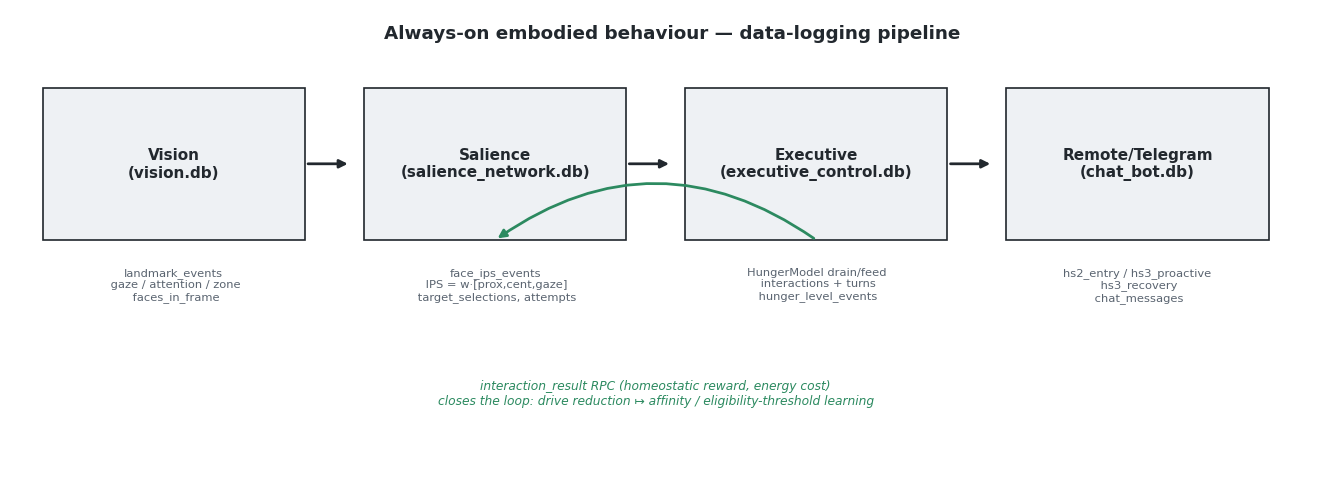

In [31]:

# Colour carries no data here (four stages, one flow), so the boxes are a single
# neutral surface and the ONE feedback edge — the point of the figure — is the only accent.
fig, ax = plt.subplots(figsize=(12, 4.2)); ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
stages = [
    ("Vision\n(vision.db)", "landmark_events\n gaze / attention / zone\n faces_in_frame"),
    ("Salience\n(salience_network.db)", "face_ips_events\n IPS = w·[prox,cent,gaze]\n target_selections, attempts"),
    ("Executive\n(executive_control.db)", "HungerModel drain/feed\n interactions + turns\n hunger_level_events"),
    ("Remote/Telegram\n(chat_bot.db)", "hs2_entry / hs3_proactive\n hs3_recovery\n chat_messages"),
]
x = 0.02; centers = []
for i,(name, sig) in enumerate(stages):
    ax.add_patch(plt.Rectangle((x,0.50),0.20,0.34, fc="#EEF1F4", ec=INK, lw=1.1))
    ax.text(x+0.10,0.67,name,ha="center",va="center",fontsize=10,fontweight="bold",color=INK)
    ax.text(x+0.10,0.44,sig,ha="center",va="top",fontsize=7.5,color=MUTED)
    centers.append(x+0.10)
    if i<3: ax.annotate("",(x+0.235,0.67),(x+0.20,0.67),arrowprops=dict(arrowstyle="-|>",lw=1.8,color=INK))
    x += 0.245
# The feedback edge (executive -> salience): the loop the study is about.
_acc = HS_ACCENT["HS1"]
ax.annotate("", (centers[1],0.50), (centers[2],0.50),
            arrowprops=dict(arrowstyle="-|>",lw=1.8,color=_acc,
                            connectionstyle="arc3,rad=0.35"))
ax.text((centers[1]+centers[2])/2, 0.135,
        "interaction_result RPC (homeostatic reward, energy cost)\n"
        "closes the loop: drive reduction ↦ affinity / eligibility-threshold learning",
        ha="center",fontsize=8,style="italic",color=_acc)
ax.text(0.5,0.95,"Always-on embodied behaviour — data-logging pipeline",ha="center",fontsize=12,fontweight="bold",color=INK)
savefig(fig,"fig01_architecture"); plt.show()

**Fig 2 — Drive timeline per day** *(unit: hunger-level event, n = 165,460 events across
12 monitored runs / 8 days)*: one panel per experiment day. The drive `run_id`/`monotonic` clock resets on every restart, so a day can
contain several runs (4 restarts on 2026-06-15, 2 on 2026-06-18); we stitch a day's runs
on the shared wall-clock (`timestamp_epoch`) and mark each restart with a dotted line.
HS bands + thresholds, feeding up-arrows sized by meal, Starving episodes shaded.

  saved figures/fig02_drive_timeline.png + .svg


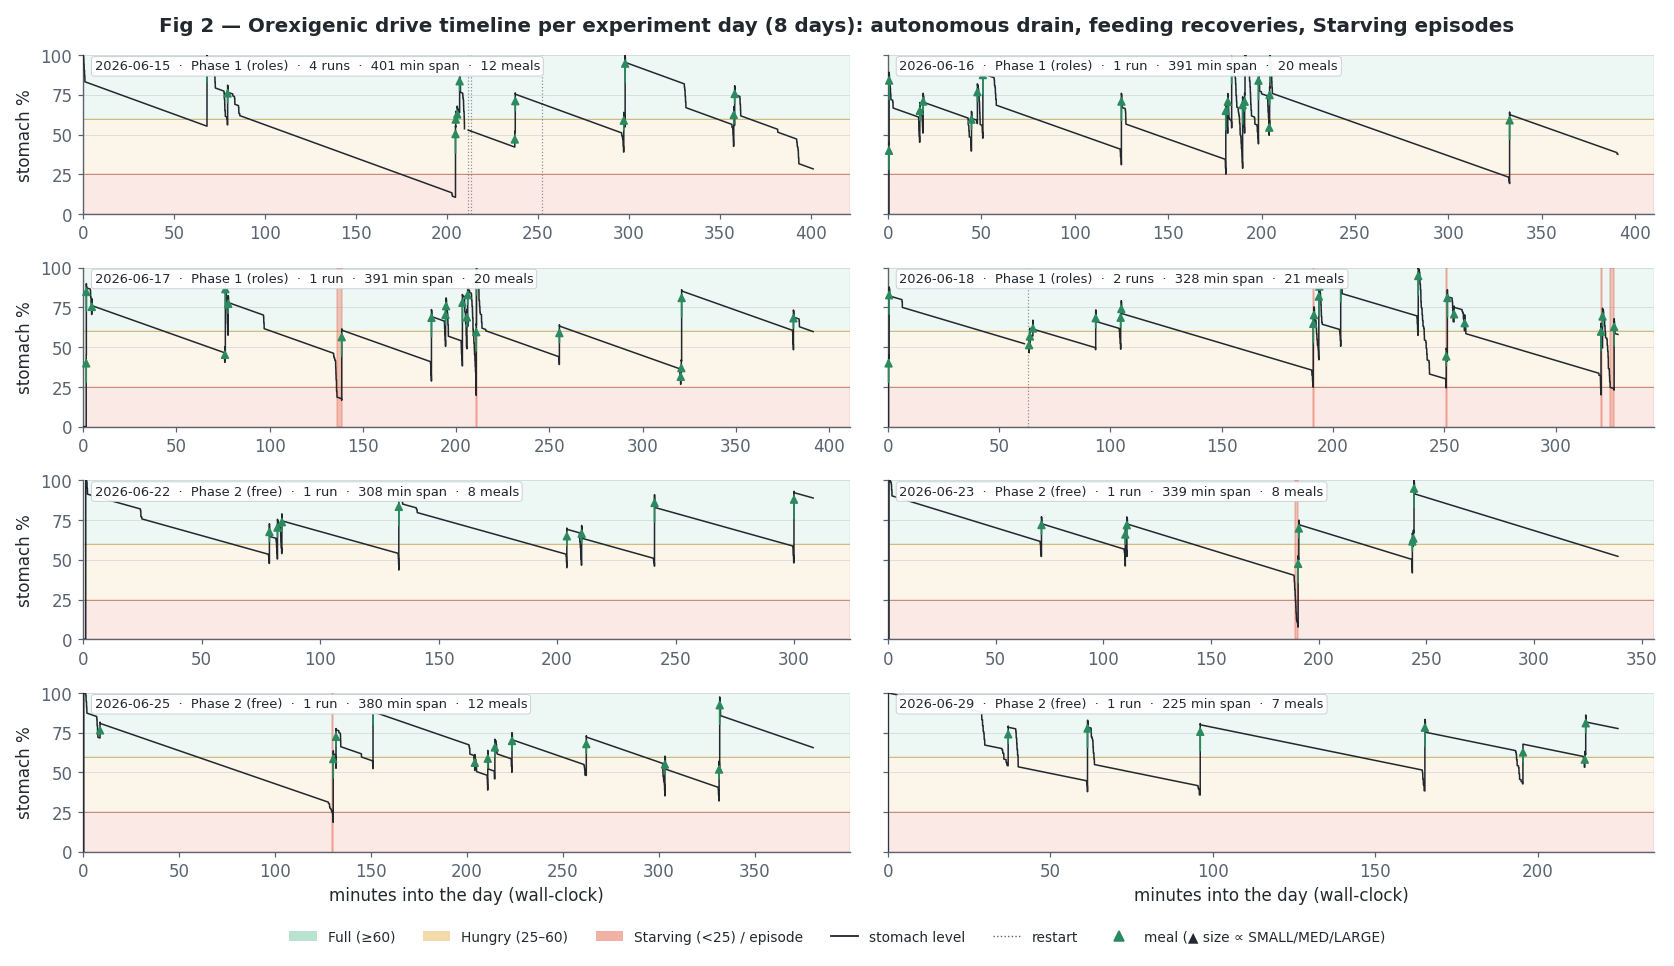

In [32]:

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# One timeline PER DAY (8 panels). run_id/monotonic are per-restart, so we place every
# sample on the day's absolute wall-clock and break the line at restarts / long gaps.
days = sorted(hunger_raw["day_rome"].dropna().unique())
nday=len(days); ncol=2; nrow=int(np.ceil(nday/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.05*nrow), sharey=True)
axes=np.atleast_1d(axes).ravel()
MEAL_SZ={"SMALL_MEAL":8,"MEDIUM_MEAL":13,"LARGE_MEAL":19}
for ax, day in zip(axes, days):
    dd=hunger_raw[hunger_raw["day_rome"]==day].sort_values(["timestamp_epoch","id"])
    t0=dd["timestamp_epoch"].min()
    ax.axhspan(60,100,color=HS_PALETTE["HS1"],alpha=0.10,zorder=0)
    ax.axhspan(25,60, color=HS_PALETTE["HS2"],alpha=0.10,zorder=0)
    ax.axhspan(0,25,  color=HS_PALETTE["HS3"],alpha=0.14,zorder=0)
    ax.axhline(60,color=HS_ACCENT["HS2"],lw=0.6,alpha=0.5); ax.axhline(25,color=HS_ACCENT["HS3"],lw=0.6,alpha=0.5)
    # HS3 episode shading (convert per-run monotonic to this day's wall-clock via the run offset)
    for _,e in hs3_episodes[hs3_episodes["day_rome"]==day].iterrows():
        off=e["entry_ts_epoch"]-e["entry_mono"]
        end_mono = e["escape_mono"] if pd.notna(e.get("escape_mono")) else e["exit_mono"]
        xe=(e["entry_ts_epoch"]-t0)/60; xx=((end_mono+off)-t0)/60
        ax.axvspan(xe,max(xx,xe+0.4),color=HS_PALETTE["HS3"],alpha=0.35,zorder=1)
    # break the line at restarts (run change) or gaps > 3 min (robot off between runs)
    x=(dd["timestamp_epoch"].values-t0)/60
    brk=(dd["run_id"].ne(dd["run_id"].shift()) | (pd.Series(x).diff().values>3.0))
    seg=np.cumsum(brk.astype(int))
    for si in np.unique(seg):
        m=seg==si
        ax.plot(x[m], dd["stomach_level_after"].values[m], color=INK, lw=1.0, zorder=3)
        if si>0: ax.axvline(x[m][0], color=MUTED, ls=":", lw=0.8, alpha=0.7, zorder=2)  # restart marker
    fd=dd[dd["event_type"]=="feeding"]
    for _,r in fd.iterrows():
        sz=MEAL_SZ.get(r["meal_payload"],9); xx=(r["timestamp_epoch"]-t0)/60
        ax.annotate("",(xx,r["stomach_level_after"]),(xx,r["stomach_level_after"]-sz),
                    arrowprops=dict(arrowstyle="-|>",color=HS_ACCENT["HS1"],lw=1.1),zorder=4)
    nruns=dd["run_id"].nunique(); span=(dd["timestamp_epoch"].max()-t0)/60
    rlabel=f"{nruns} runs" if nruns>1 else "1 run"
    _ph = "Phase 1 (roles)" if str(day) in globals().get("PHASE1_DAYS",set()) else "Phase 2 (free)"
    ax.text(0.015,0.97,f"{day}  ·  {_ph}  ·  {rlabel}  ·  {span:.0f} min span  ·  {len(fd)} meals",
            transform=ax.transAxes,fontsize=8.5,va="top",fontweight="medium",zorder=6,
            bbox=dict(boxstyle="round,pad=0.25",fc="white",ec=GRID,lw=0.6,alpha=0.95))
    ax.set_ylim(0,100); ax.set_xlim(left=0)
for j,ax in enumerate(axes):
    if j>=nday: ax.set_visible(False)
    if j%ncol==0: ax.set_ylabel("stomach %")
    if j>=nday-ncol: ax.set_xlabel("minutes into the day (wall-clock)")
handles=[Patch(fc=HS_PALETTE["HS1"],alpha=.4,label="Full (≥60)"),
         Patch(fc=HS_PALETTE["HS2"],alpha=.4,label="Hungry (25–60)"),
         Patch(fc=HS_PALETTE["HS3"],alpha=.5,label="Starving (<25) / episode"),
         Line2D([0],[0],color=INK,lw=1.2,label="stomach level"),
         Line2D([0],[0],color=MUTED,lw=0.9,ls=":",label="restart"),
         Line2D([0],[0],marker="^",color=HS_ACCENT["HS1"],lw=0,label="meal (▲ size ∝ SMALL/MED/LARGE)")]
fig.legend(handles=handles,loc="lower center",ncol=6,bbox_to_anchor=(0.5,-0.05),fontsize=9)
fig.suptitle("Fig 2 — Orexigenic drive timeline per experiment day (8 days): autonomous drain, feeding recoveries, Starving episodes",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig02_drive_timeline"); plt.show()

**Fig 3 — Thresholds / transitions** *(unit: hunger-state transition, n = 146 transitions)*: level-at-transition histograms vs 60/25 lines + HS state-transition diagram with observed counts.

  saved figures/fig03_thresholds_transitions.png + .svg


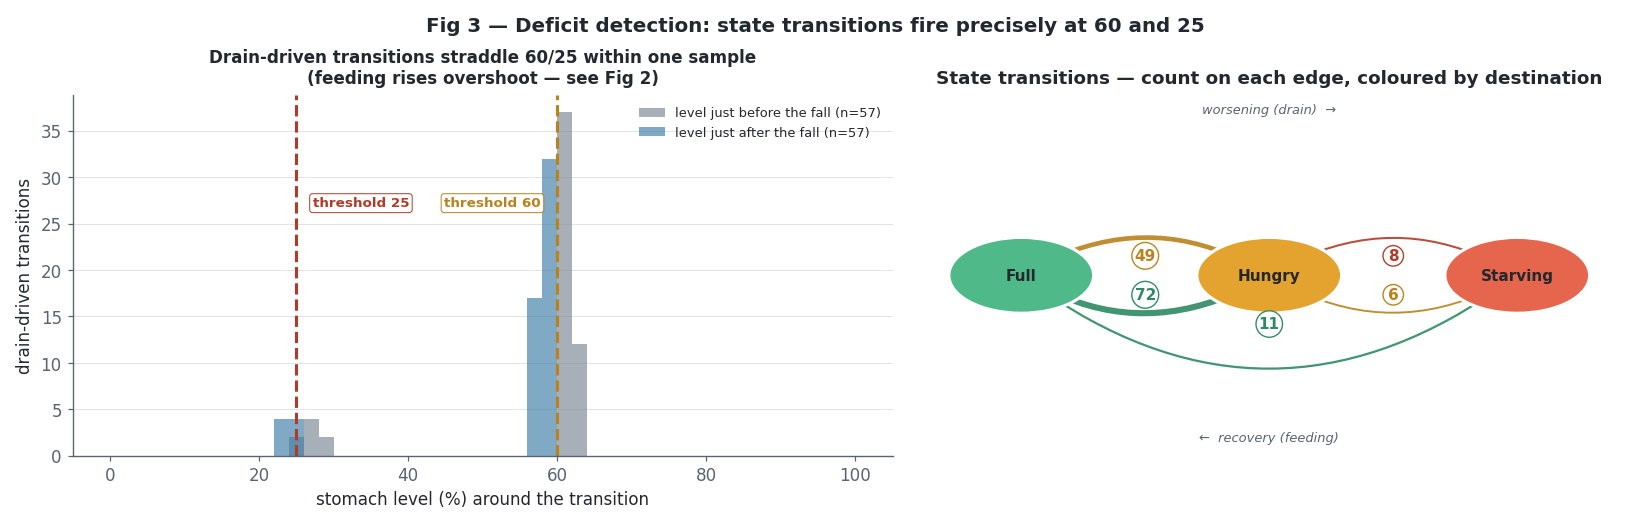

In [33]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14.6, 4.6), gridspec_kw={"width_ratios":[1.25,1.05]})
tr = hs_transitions
# Detection is exact for DRAIN-driven falls: they cross the threshold continuously, so
# the level straddles 60/25 within one sample. Feeding-driven RISES are discrete meals
# that overshoot the threshold (they are recoveries, not detection) — shown separately.
dn = tr[tr["level_delta"]<0]                                   # drain/cost-driven falls (detection)
up = tr[tr["level_delta"]>0]                                   # feeding-driven rises (recovery)
# For falls, plot the tight bracket [after, before] around the crossed threshold.
dn60 = dn[dn[["from_state","to_state"]].apply(lambda r:set(r)=={"HS1","HS2"},axis=1)]
dn25 = dn[dn[["from_state","to_state"]].apply(lambda r:set(r)=={"HS2","HS3"},axis=1)]
bins=np.linspace(0,100,51)
# Histogram colours are deliberately NEUTRAL (gray/blue) so the amber/red threshold
# lines are the only warm accents — data colour never collides with threshold colour.
ax1.hist(dn["stomach_level_before"],bins=bins,color="#8A94A0",alpha=0.75,
         label=f"level just before the fall (n={len(dn)})")
ax1.hist(dn["stomach_level_after"],bins=bins,color="#3A7CA5",alpha=0.65,
         label=f"level just after the fall (n={len(dn)})")
for lvl,txt,col,xoff in [(60,"threshold 60",HS_ACCENT["HS2"],-2.2),(25,"threshold 25",HS_ACCENT["HS3"],2.2)]:
    ax1.axvline(lvl,color=col,lw=2,ls="--")
    ax1.annotate(txt, xy=(lvl, ax1.get_ylim()[1]*0.70), xytext=(lvl+xoff, ax1.get_ylim()[1]*0.70),
                 ha="left" if xoff>0 else "right", va="center", fontsize=8.8, color=col,
                 fontweight="bold", bbox=dict(boxstyle="round,pad=0.22",fc="white",ec=col,lw=0.7,alpha=0.92))
ax1.set_xlabel("stomach level (%) around the transition"); ax1.set_ylabel("drain-driven transitions")
ax1.legend(loc="upper right",fontsize=8.5)   # x>65 is empty — no collision possible
ax1.set_title("Drain-driven transitions straddle 60/25 within one sample\n(feeding rises overshoot — see Fig 2)",fontsize=11)
# State-transition graph: states on ONE left->right deficit axis; worsening arcs above,
# recovery arcs below; each edge coloured by its DESTINATION state with the count ON the arc.
ax2.set_axis_off(); ax2.set_xlim(0,1); ax2.set_ylim(0.02,1.02)
pos={"HS1":(0.14,0.52),"HS2":(0.50,0.52),"HS3":(0.86,0.52)}
counts=tr.groupby(["from_state","to_state"]).size(); mx=counts.max()
# Empirically (matplotlib arc3 sign): NEGATIVE rad bows a rightward edge UP and a leftward
# edge DOWN — so one negative constant puts worsening arcs above the nodes and recovery
# arcs below. Long edges get extra curvature so they clear the middle node.
RAD=-0.30
for (a,b),c in counts.items():
    if a not in pos or b not in pos or a==b: continue
    (x1,y0),(x2,_)=pos[a],pos[b]; d=x2-x1
    rad_eff = RAD*(1.25 if abs(d)>0.5 else 1.0)
    ax2.annotate("",pos[b],pos[a],zorder=1,
        arrowprops=dict(arrowstyle="-|>",mutation_scale=16,lw=1+3*c/mx,
                        color=HS_ACCENT[b],alpha=0.9,
                        connectionstyle=f"arc3,rad={rad_eff}",shrinkA=20,shrinkB=20))
    apex_y = y0 - rad_eff*d/2                      # quadratic-Bezier midpoint of the drawn arc
    ax2.text((x1+x2)/2, apex_y, f"{int(c)}", fontsize=10, ha="center", va="center",
             color=HS_ACCENT[b], fontweight="bold", zorder=4,
             bbox=dict(boxstyle="circle,pad=0.18",fc="white",ec=HS_ACCENT[b],lw=0.9,alpha=0.98))
for s,(x,y) in pos.items():
    ax2.add_patch(plt.Circle((x,y),0.105,fc=HS_PALETTE[s],ec="white",lw=2,zorder=2))
    ax2.text(x,y,HS_NAME[s],ha="center",va="center",fontweight="bold",color=INK,zorder=3,fontsize=10)
ax2.text(0.50,0.97,"worsening (drain)  →",ha="center",fontsize=8.5,color=MUTED,style="italic")
ax2.text(0.50,0.06,"←  recovery (feeding)",ha="center",fontsize=8.5,color=MUTED,style="italic")
ax2.set_title("State transitions — count on each edge, coloured by destination")
fig.suptitle("Fig 3 — Deficit detection: state transitions fire precisely at 60 and 25",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig03_thresholds_transitions"); plt.show()

**Fig 4 — Deficit → action (RQ1-3)** *(units: 367 interaction turns, 710 chat messages,
217 co-present interactions, and 193 deficit-gated action events)*: the correct contrast,
**Full vs deficit (Hungry+Starving)**. Left: recovery-action rates with bootstrap CIs.
Right: the time distribution of deficit-gated actions across the deployment, rather than a
bar chart of corpus totals; the thin state-coloured trace is the continuous stomach level
context.

  saved figures/fig04_deficit_action.png + .svg


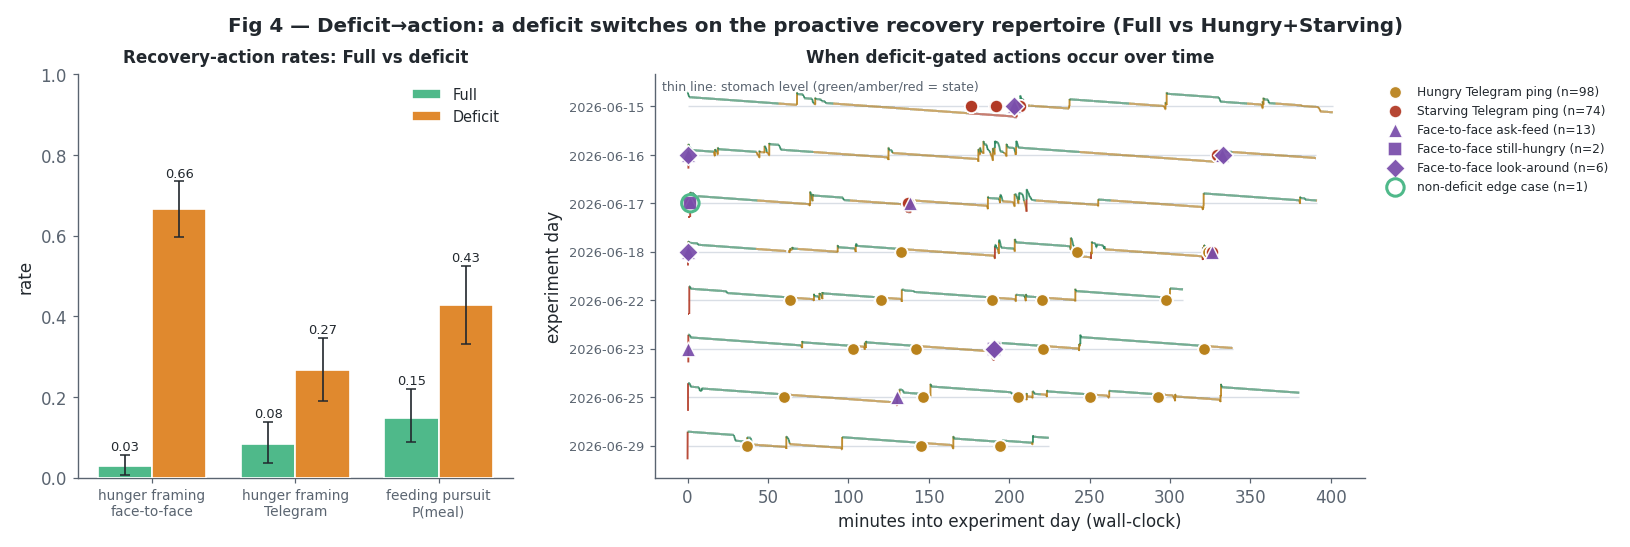

In [34]:

# Fig 4 — RQ1-3 visual: does a DEFICIT change what the robot does? Contrast no-deficit (Full)
# vs deficit (Hungry+Starving) across the coded state-gated recovery repertoire.
from matplotlib.collections import LineCollection

def _grp(h): return "Full" if h=="HS1" else ("Deficit" if h in ("HS2","HS3") else None)
FULL_C, DEF_C = HS_PALETTE["HS1"], "#E0892E"

_tt = turns_nlp.copy(); _tt["g"]=_tt["hunger_state"].map(_grp)
_tt["v"]=pd.to_numeric(_tt.get("hunger_mentioned",0),errors="coerce").fillna(0)
_am = chat_msgs.copy()
if "role" in _am.columns: _am=_am[_am["role"]=="assistant"]
_am["g"]=_am["hs"].map(_grp); _am["v"]=pd.to_numeric(_am.get("hunger_mentioned",0),errors="coerce").fillna(0)
_mm = master.copy(); _mm["g"]=_mm["hunger_state_start"].map(_grp)
_mm["fed"]=(pd.to_numeric(_mm["meals_eaten_count"],errors="coerce").fillna(0)>0).astype(float)
rate_specs=[("hunger framing\nface-to-face",_tt,"v"),
            ("hunger framing\nTelegram",_am,"v"),
            ("feeding pursuit\nP(meal)",_mm,"fed")]
def _ci(df,col,g):
    e,lo,hi=boot_ci(df[df["g"]==g][col]); return e,max(e-lo,0.0),max(hi-e,0.0)

fig,(axA,axB)=plt.subplots(1,2,figsize=(14.6,4.8),gridspec_kw={"width_ratios":[0.95,1.55]})
x=np.arange(len(rate_specs)); w=0.38
for gi,(g,c) in enumerate([("Full",FULL_C),("Deficit",DEF_C)]):
    es=[];los=[];his=[]
    for _,df,col in rate_specs:
        e,lo,hi=_ci(df,col,g); es.append(e);los.append(lo);his.append(hi)
    off=(-w/2 if gi==0 else w/2)
    axA.bar(x+off,es,w,color=c,edgecolor="white",linewidth=1.1,label=g,zorder=3)
    axA.errorbar(x+off,es,yerr=[los,his],fmt="none",ecolor=INK,elinewidth=1.1,capsize=3,zorder=4)
    for xi,e,hi in zip(x,es,his):
        # anchor above the errorbar whisker, never on it (small bars used to collide)
        axA.annotate(f"{e:.2f}",(xi+off,e+hi),textcoords="offset points",xytext=(0,3),
                     ha="center",fontsize=8.5,color=INK)
axA.set_xticks(x); axA.set_xticklabels([s[0] for s in rate_specs],fontsize=9)
axA.set_ylabel("rate"); axA.set_ylim(0,1.0); axA.grid(False); axA.legend(loc="upper right")
axA.set_title("Recovery-action rates: Full vs deficit",fontsize=11)

_ev=chat_events.copy(); _prov=_ev[_ev["event_type"].isin(["hs2_entry","hs3_proactive"])]
_prov = _prov.assign(action=_prov["event_type"].map({"hs2_entry":"Hungry Telegram ping",
                                                     "hs3_proactive":"Starving Telegram ping"}),
                     hs_state=_prov["hs"])
_ac=hunger_raw[hunger_raw["event_type"]=="active_cost"].copy()
_seek=_ac[_ac["stimulus_label"].isin(["hunger_ask_feed","hunger_still_hungry","hunger_look_around"])].copy()
_seek = _seek.assign(action=_seek["stimulus_label"].map({
                        "hunger_ask_feed":"Face-to-face ask-feed",
                        "hunger_still_hungry":"Face-to-face still-hungry",
                        "hunger_look_around":"Face-to-face look-around"}),
                     hs_state=_seek["hunger_state_before"].fillna(_seek["hunger_state_after"]))
_events = pd.concat([
    _prov[["timestamp_epoch","day_rome","action","hs_state"]],
    _seek[["timestamp_epoch","day_rome","action","hs_state"]]
], ignore_index=True).dropna(subset=["timestamp_epoch","day_rome"])
_events["hs_group"]=_events["hs_state"].map(_grp)
days=sorted(hunger_raw["day_rome"].dropna().unique())
day_to_y={d:i for i,d in enumerate(days)}
day_start=hunger_raw.groupby("day_rome")["timestamp_epoch"].min().to_dict()
_events["minute"]=_events.apply(lambda r:(r["timestamp_epoch"]-day_start.get(r["day_rome"],r["timestamp_epoch"]))/60.0,axis=1)
_events["y"]=_events["day_rome"].map(day_to_y)
styles={
    "Hungry Telegram ping":("o",HS_ACCENT["HS2"],64),
    "Starving Telegram ping":("o",HS_ACCENT["HS3"],72),
    "Face-to-face ask-feed":("^","#7A4EAB",92),
    "Face-to-face still-hungry":("s","#7A4EAB",84),
    "Face-to-face look-around":("D","#7A4EAB",84),
}
for day in days:
    dd=hunger_raw[hunger_raw["day_rome"]==day]
    span=(dd["timestamp_epoch"].max()-dd["timestamp_epoch"].min())/60.0
    axB.hlines(day_to_y[day],0,span,color="#D9DEE5",lw=0.9,zorder=0)
    # Mini-sparkline of the continuous stomach level for this day. It is scaled to
    # stay inside the day row; segment colour carries the current hunger state.
    dd=dd.sort_values(["timestamp_epoch","id"]).copy()
    if len(dd) >= 2:
        xx=(dd["timestamp_epoch"].values-dd["timestamp_epoch"].min())/60.0
        yy=day_to_y[day] + (50.0-dd["stomach_level_after"].astype(float).values)/175.0
        states=dd["hunger_state_after"].fillna(dd["hunger_state_before"]).astype(str).values
        run_ids=dd["run_id"].astype(str).values
        epochs=dd["timestamp_epoch"].astype(float).values
        segs=[]; cols=[]
        for i in range(len(dd)-1):
            if run_ids[i] != run_ids[i+1] or (epochs[i+1]-epochs[i]) > 180:
                continue
            segs.append([(xx[i],yy[i]),(xx[i+1],yy[i+1])])
            cols.append(HS_ACCENT.get(states[i], MUTED))
        if segs:
            axB.add_collection(LineCollection(segs, colors=cols, linewidths=1.25, alpha=0.90, zorder=1))
for action,(marker,color,size) in styles.items():
    sub=_events[_events["action"]==action]
    if len(sub):
        axB.scatter(sub["minute"],sub["y"],s=size,marker=marker,color=color,
                    edgecolor="white",linewidth=1.0,alpha=0.94,label=f"{action} (n={len(sub)})",zorder=3)
_nondef=_events[_events["hs_group"]!="Deficit"]
if len(_nondef):
    axB.scatter(_nondef["minute"],_nondef["y"],s=130,facecolors="none",edgecolors=HS_PALETTE["HS1"],
                linewidth=2.0,label=f"non-deficit edge case (n={len(_nondef)})",zorder=4)
axB.set_yticks(range(len(days))); axB.set_yticklabels(days,fontsize=8.5)
axB.set_xlabel("minutes into experiment day (wall-clock)")
axB.set_ylabel("experiment day")
axB.grid(False)
axB.invert_yaxis()
axB.legend(loc="upper left",bbox_to_anchor=(1.01,1.0),fontsize=8,frameon=False)
axB.text(0.01,0.985,"thin line: stomach level (green/amber/red = state)",
         transform=axB.transAxes,ha="left",va="top",fontsize=8.2,color=MUTED)
axB.set_title("When deficit-gated actions occur over time",fontsize=11)
fig.suptitle("Fig 4 — Deficit→action: a deficit switches on the proactive recovery repertoire (Full vs Hungry+Starving)",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig04_deficit_action"); plt.show()

**Fig 5 — State×Hunger prioritisation heatmap** *(unit: interaction, n = 217; Starving column n = 13)*: grid coloured by Engaged-completion and by avg turns (Starving override should pop out).

  saved figures/fig05_prioritisation_heatmap.png + .svg


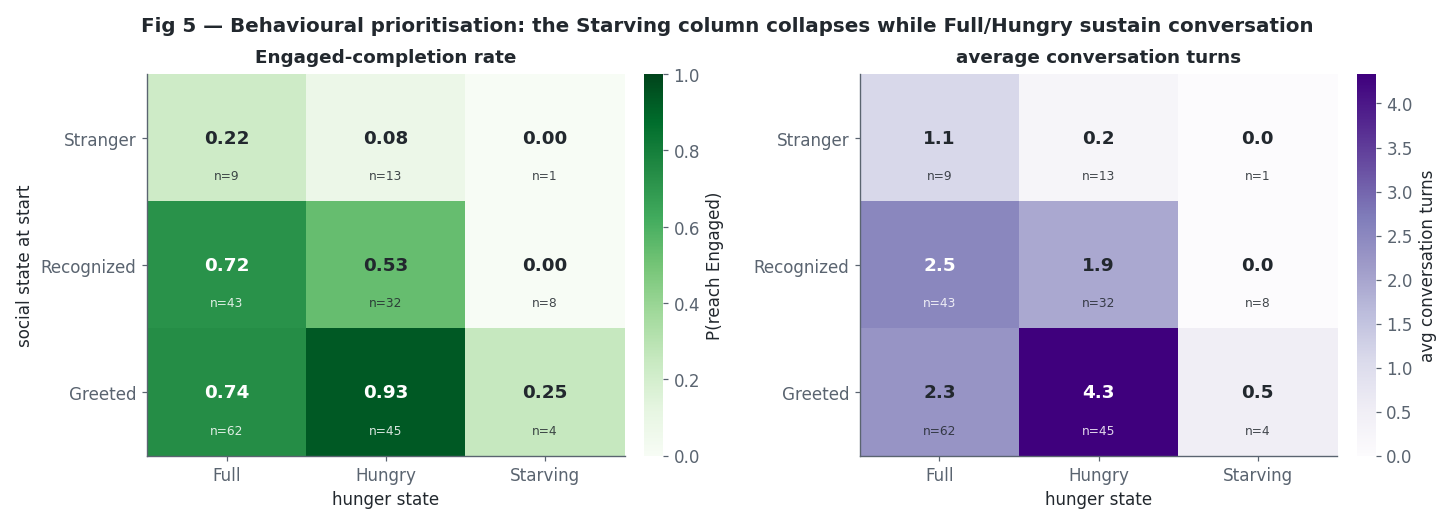

In [35]:

# Sequential single-hue (magnitude), NOT a red-green rainbow: CVD-safe, and every cell
# is annotated with value + n so small cells (esp. the HS3 column) are not over-read.
import matplotlib.colors as mcolors
d=master.copy(); d["reached_ss4"]=(d["final_state"]=="ss4").astype(int)
d["n_turns"]=pd.to_numeric(d["n_turns"],errors="coerce").fillna(0)
d=d.dropna(subset=["hunger_state_start"])
ss_ord=["ss1","ss2","ss3"]
def grid(val): return d.pivot_table(index="initial_state",columns="hunger_state_start",
        values=val,aggfunc="mean").reindex(index=ss_ord,columns=HS_ORDER)
def ngrid(): return d.pivot_table(index="initial_state",columns="hunger_state_start",
        values="interaction_id",aggfunc="count").reindex(index=ss_ord,columns=HS_ORDER)
def draw(ax,M,N,cmap,vmax,label,fmt):
    im=ax.imshow(M.values,cmap=cmap,vmin=0,vmax=vmax,aspect="auto")
    ax.set_xticks(range(3)); ax.set_xticklabels(HS_NAMES); ax.set_yticks(range(3)); ax.set_yticklabels([SS_NAME[s] for s in ss_ord])
    ax.set_xlabel("hunger state"); ax.grid(False)
    for i in range(3):
        for j in range(3):
            v=M.values[i,j]; n=N.values[i,j]
            if np.isnan(v):
                ax.text(j,i,"—",ha="center",va="center",color=MUTED); continue
            frac=v/vmax
            tc="white" if frac>0.55 else INK
            ax.text(j,i,fmt.format(v),ha="center",va="center",color=tc,fontweight="bold",fontsize=12)
            ax.text(j,i+0.30,f"n={0 if np.isnan(n) else int(n)}",ha="center",va="center",color=tc,fontsize=8,alpha=0.85)
    cb=fig.colorbar(im,ax=ax,fraction=0.046,pad=0.04); cb.set_label(label); cb.outline.set_visible(False)
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.6))
N=ngrid()
draw(a1,grid("reached_ss4"),N,"Greens",1.0,"P(reach Engaged)","{:.2f}")
a1.set_ylabel("social state at start"); a1.set_title("Engaged-completion rate")
draw(a2,grid("n_turns"),N,"Purples",grid("n_turns").max().max(),"avg conversation turns","{:.1f}")
a2.set_title("average conversation turns")
fig.suptitle("Fig 5 — Behavioural prioritisation: the Starving column collapses while Full/Hungry sustain conversation",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig05_prioritisation_heatmap"); plt.show()

**Fig 6 — IPS decomposition** *(unit: salience target/face IPS rows, n = 5,142 target selections and 216,940 face-IPS events; mechanism context, not a drive result)*: weighted prox/cent/gaze composition of IPS; IPS vs effective threshold.

  saved figures/fig06_ips_decomposition.png + .svg


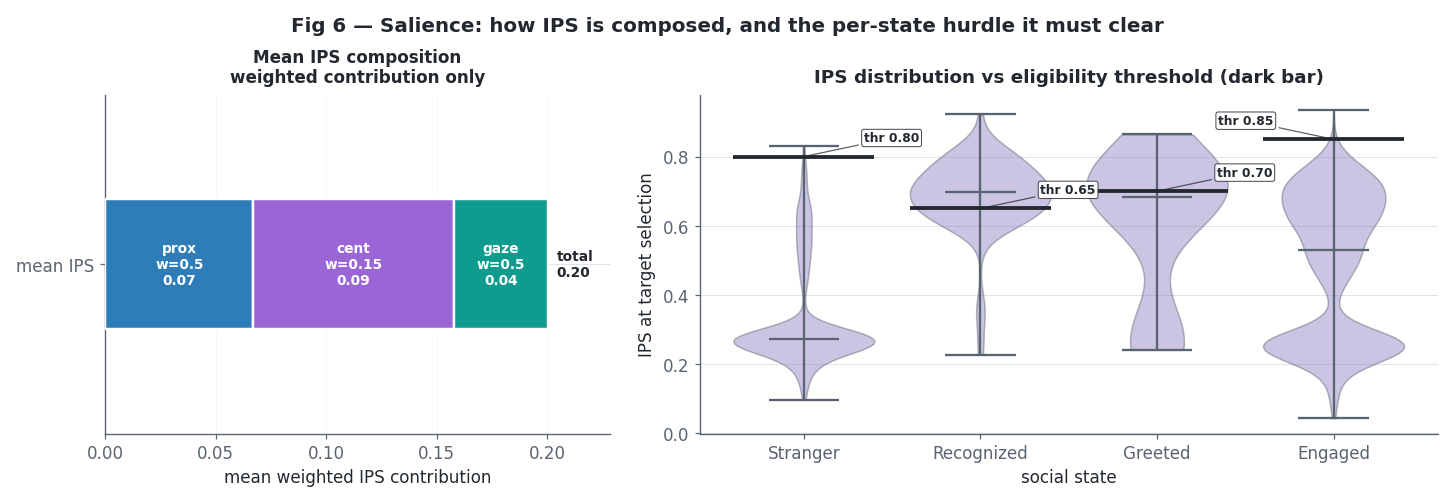

In [36]:

w=CONST["BASELINE_WEIGHTS"]; SUB=["prox","cent","gaze"]
# cool triple (validated): none of these collide with the reserved HS status colours
SUBCOL={"prox":"#2E7DB8","cent":"#9A66D6","gaze":"#0F9B8E"}
s=ips.dropna(subset=[f"{k}_score" for k in SUB]).copy()
contrib={k:(s[f"{k}_score"]*w[k]).mean() for k in SUB}
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.4),gridspec_kw={"width_ratios":[0.82,1.2]})
left=0.0
total=sum(contrib.values())
for k in SUB:
    v=contrib[k]
    a1.barh(["mean IPS"],[v],left=left,color=SUBCOL[k],edgecolor="white",linewidth=1.6,height=0.46,zorder=3)
    label=f"{k}\nw={w[k]}\n{v:.2f}"
    a1.text(left+v/2,0,label,ha="center",va="center",color="white",fontsize=9,fontweight="bold")
    left+=v
a1.set_xlabel("mean weighted IPS contribution")
a1.set_xlim(0,total*1.14)
a1.set_ylim(-0.6,0.6)
a1.grid(axis="x",alpha=0.16)
a1.set_title("Mean IPS composition\nweighted contribution only",fontsize=11)
a1.text(total*1.02,0,f"total\n{total:.2f}",ha="left",va="center",fontsize=9,color=INK,fontweight="bold")
# IPS distribution by social state vs thresholds (violin + threshold marks)
tsel=load_view("salience","v_target_selections_clean")
ss_list=["ss1","ss2","ss3","ss4"]
data=[tsel[tsel["ss"]==ss]["ips"].dropna().values for ss in ss_list]
parts=a2.violinplot([d for d in data if len(d)],positions=[i for i,d in enumerate(data) if len(d)],
                    showmedians=True,widths=0.8)
for pc in parts["bodies"]: pc.set_facecolor("#8E7CC3"); pc.set_alpha(0.45); pc.set_edgecolor(MUTED)
for key in ["cmedians","cmaxes","cmins","cbars"]:
    if key in parts: parts[key].set_edgecolor(MUTED)
for i,ss in enumerate(ss_list):
    thr=CONST["SS_THRESHOLDS"].get(ss)
    if thr is not None:
        # threshold marks in neutral INK — red is reserved for Starving in this report
        a2.hlines(thr,i-0.4,i+0.4,color=INK,lw=2.5,zorder=5)
        ha = "right" if i == len(ss_list)-1 else "left"
        x_text = i-0.34 if i == len(ss_list)-1 else i+0.34
        a2.annotate(f"thr {thr:.2f}", xy=(i,thr), xytext=(x_text,thr+0.035),
                    ha=ha, va="bottom", fontsize=8, color=INK, fontweight="bold",
                    arrowprops=dict(arrowstyle="-",color=INK,lw=0.8,alpha=0.75),
                    bbox=dict(boxstyle="round,pad=0.18",fc="white",ec=INK,lw=0.6,alpha=0.92),
                    zorder=6)
a2.set_xticks(range(4)); a2.set_xticklabels([SS_NAME[s] for s in ss_list])
a2.set_ylabel("IPS at target selection"); a2.set_xlabel("social state")
a2.set_title("IPS distribution vs eligibility threshold (dark bar)")
fig.suptitle("Fig 6 — Salience: how IPS is composed, and the per-state hurdle it must clear",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig06_ips_decomposition"); plt.show()

**Fig 7 — Starving recovery** *(unit: Starving episode, n = 8 episodes across 4 runs; exploratory)*: cumulative first-feed probability, with recovery status summarized in-plot. Thin n — read as directional, not a rate estimate.

  saved figures/fig07_hs3_funnel.png + .svg


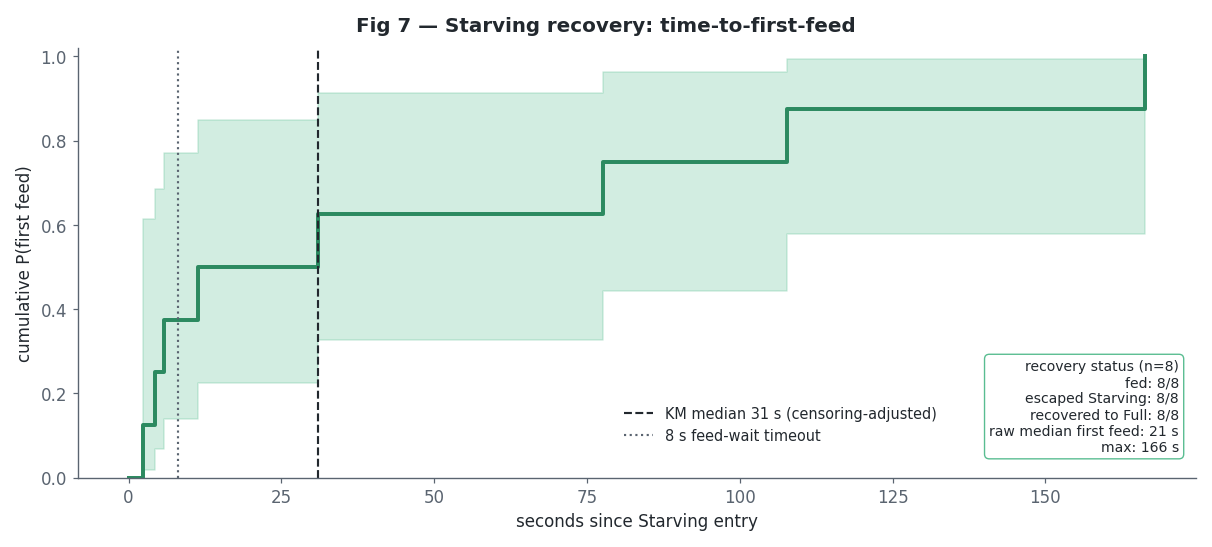

In [37]:

ep=hs3_episodes.copy(); n=len(ep)
n_feed=int(ep["received_feed"].sum())
n_escape=int(ep["escaped_starving_by_feeding"].sum())
n_full=int(ep["recovered_to_full_by_feeding"].sum())
fig,ax=plt.subplots(1,1,figsize=(10.8,4.8))
ttf=ep["time_to_first_feed_sec"].dropna()
try:
    from lifelines import KaplanMeierFitter
    km = ep.copy()
    km["dur"] = km["time_to_first_feed_sec"].fillna(km["episode_duration_sec"])
    km["event"] = km["received_feed"].astype(int)
    km = km[km["dur"] > 0]
    kmf = KaplanMeierFitter().fit(km["dur"], km["event"], label="first feed")
    sf = kmf.survival_function_["first feed"]
    ci = kmf.confidence_interval_
    ax.step(sf.index, 1 - sf.values, where="post", color=HS_ACCENT["HS1"], lw=2.6)
    lo = 1 - ci.iloc[:,1].values; hi = 1 - ci.iloc[:,0].values
    ax.fill_between(ci.index, lo, hi, step="post", color=HS_PALETTE["HS1"], alpha=0.25)
    if np.isfinite(kmf.median_survival_time_):
        ax.axvline(kmf.median_survival_time_, color=INK, ls="--", lw=1.4,
                   label=f"KM median {kmf.median_survival_time_:.0f} s (censoring-adjusted)")
except Exception:
    vals_ecdf = np.sort(ttf.values)
    if len(vals_ecdf):
        ax.step(vals_ecdf, np.arange(1, len(vals_ecdf)+1)/len(vals_ecdf),
                where="post", color=HS_ACCENT["HS1"], lw=2.2)
ax.axvline(CONST["FEED_WAIT_TIMEOUT_SEC"], color=MUTED, ls=":", lw=1.4,
           label="8 s feed-wait timeout")
if len(ep):
    ttf_med=ttf.median() if len(ttf) else np.nan
    ttf_max=ttf.max() if len(ttf) else np.nan
    status = (
        f"recovery status (n={n})\n"
        f"fed: {n_feed}/{n}\n"
        f"escaped Starving: {n_escape}/{n}\n"
        f"recovered to Full: {n_full}/{n}\n"
        f"raw median first feed: {ttf_med:.0f} s\n"
        f"max: {ttf_max:.0f} s"
    )
    ax.text(0.985,0.055,status,transform=ax.transAxes,ha="right",va="bottom",
            fontsize=9.2,color=INK,
            bbox=dict(boxstyle="round,pad=0.34",fc="white",ec=HS_PALETTE["HS1"],lw=0.9,alpha=0.94))
ax.set_xlabel("seconds since Starving entry"); ax.set_ylabel("cumulative P(first feed)")
ax.set_ylim(0,1.02); ax.grid(False); ax.legend(loc="lower right", bbox_to_anchor=(0.78,0.05))
fig.suptitle("Fig 7 — Starving recovery: time-to-first-feed",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig07_hs3_funnel"); plt.show()

**Fig 8 — Remote-channel loop** *(unit: proactive Telegram ping, n = 234 pings across 12 subscribers; response window = 1 h)*: response-to-ping rate by ping type (bootstrap 95% CI; n on each bar). A separate counts panel would repeat the n labels, so there isn't one.

  saved figures/fig08_remote_loop.png + .svg


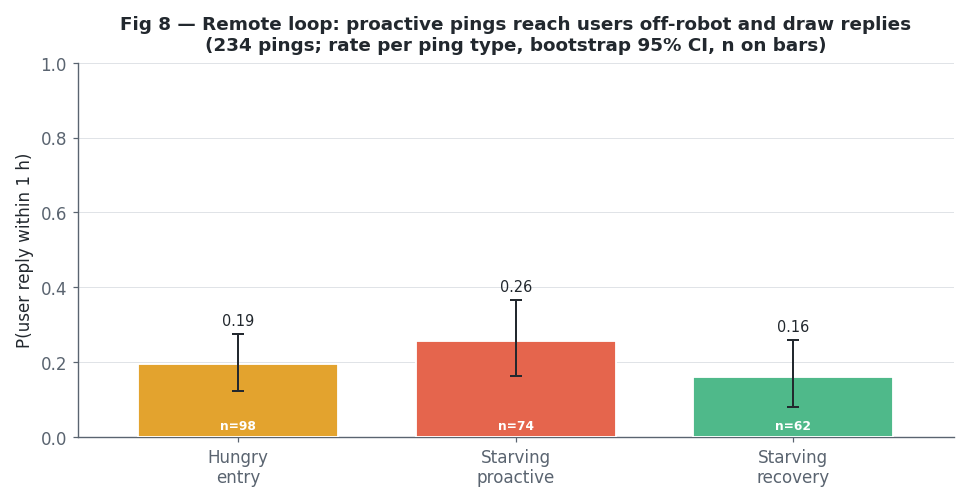

In [38]:

ev=chat_events.copy().sort_values(["run_id","chat_id","timestamp_epoch"])
kinds=["hs2_entry","hs3_proactive","hs3_recovery"]
kcol={"hs2_entry":HS_PALETTE["HS2"],"hs3_proactive":HS_PALETTE["HS3"],"hs3_recovery":HS_PALETTE["HS1"]}
def resp(kind,win=3600.0):
    p=ev[ev["event_type"]==kind]; hits=[]
    for _,row in p.iterrows():
        later=ev[(ev["chat_id"]==row["chat_id"])&(ev["event_type"]=="user_message")&
                 (ev["timestamp_epoch"]>row["timestamp_epoch"])&(ev["timestamp_epoch"]<=row["timestamp_epoch"]+win)]
        hits.append(int(len(later)>0))
    return hits
# Display labels use the state names; the underlying event_type values are unchanged.
# Single panel: the per-type ping counts appear as the n= label on each bar, so a
# separate "pings sent" panel would be pure redundancy.
klabel={"hs2_entry":"Hungry\nentry","hs3_proactive":"Starving\nproactive","hs3_recovery":"Starving\nrecovery"}
fig,ax=plt.subplots(figsize=(8.6,4.4))
es=[];los=[];his=[];ns=[]
for k in kinds:
    h=resp(k); e,lo,hi=boot_ci(h) if len(h) else (0,0,0)
    es.append(e); los.append(e-lo); his.append(hi-e); ns.append(len(h))
bars_with_ci(ax,[klabel[k] for k in kinds],es,los,his,[kcol[k] for k in kinds],
             n_labels=ns,small_flag=[x<20 for x in ns])
ax.set_ylim(0,1); ax.set_ylabel("P(user reply within 1 h)")
ax.set_title(f"Fig 8 — Remote loop: proactive pings reach users off-robot and draw replies\n"
             f"({sum(ns)} pings; rate per ping type, bootstrap 95% CI, n on bars)",fontsize=12)
savefig(fig,"fig08_remote_loop"); plt.show()

**Fig 9 — Steady-state occupancy** *(unit: CTMC state sojourn/transition reconstructed from 165,460 hunger events; n = 12 monitored runs)*: modelled stationary distribution vs empirical.

  saved figures/fig09_steady_state.png + .svg


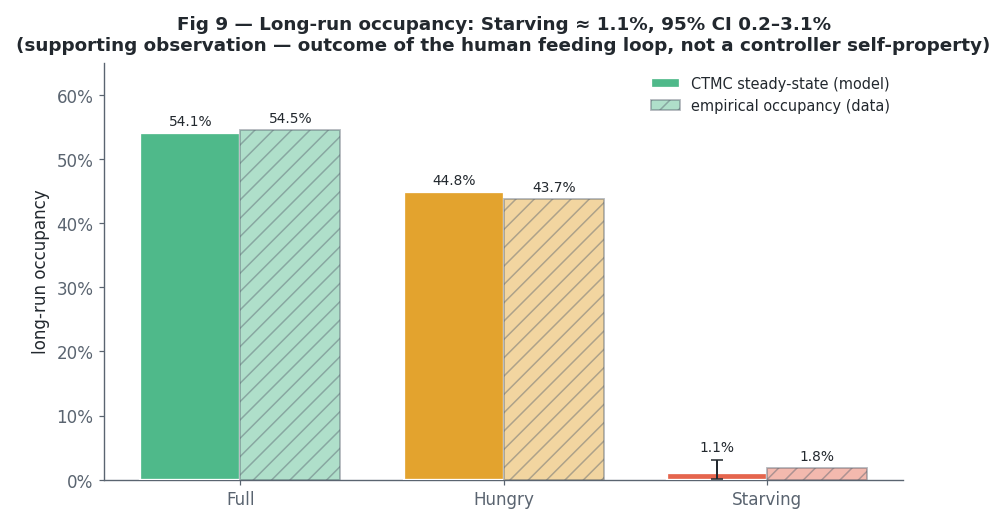

In [39]:

pi=globals().get("_ctmc_pi",{})
fig,ax=plt.subplots(figsize=(8,4.6))
if pi:
    states=["HS1","HS2","HS3"]
    seq=state_sequence(hunger_raw); seq=seq[(seq["state"].isin(states))&(seq["dwell"]>0)]
    ti=seq.groupby("state")["dwell"].sum().reindex(states).fillna(0); emp=ti/ti.sum()
    x=np.arange(3); wbar=0.38
    b1=ax.bar(x-wbar/2,[pi[s] for s in states],wbar,label="CTMC steady-state (model)",
              color=[HS_PALETTE[s] for s in states],edgecolor="white",linewidth=1.5,zorder=3)
    b2=ax.bar(x+wbar/2,[emp[s] for s in states],wbar,label="empirical occupancy (data)",
              color=[HS_PALETTE[s] for s in states],alpha=0.45,edgecolor=MUTED,linewidth=1.2,hatch="//",zorder=3)
    # One decimal so the labels track the (small) model-vs-empirical differences instead of
    # both rounding to the same integer (e.g. Full 54.1% model vs 54.5% empirical).
    # The report leads with the run-level block-bootstrap interval, so the Starving model
    # bar carries that 95% CI as a whisker — the one uncertain quantity in this figure.
    _ci9 = globals().get("_b7_starve_ci_block", globals().get("_b7_starve_ci"))
    _ttl_ci = ""
    if _ci9 and np.isfinite(_ci9[0]):
        ax.errorbar([2-wbar/2],[pi["HS3"]],yerr=[[max(pi["HS3"]-_ci9[0],0)],[max(_ci9[2]-pi["HS3"],0)]],
                    fmt="none",ecolor=INK,elinewidth=1.3,capsize=4,zorder=5)
        _ttl_ci = f", 95% CI {_ci9[0]*100:.1f}–{_ci9[2]*100:.1f}%"
    for bars,vals in [(b1,[pi[s] for s in states]),(b2,[emp[s] for s in states])]:
        for r,v in zip(bars,vals):
            _ytxt=v+0.012
            # the Starving model bar carries a CI whisker: sit its label above the whisker cap
            if _ci9 and np.isfinite(_ci9[0]) and bars is b1 and abs(r.get_x()+r.get_width()/2-(2-wbar/2))<1e-9:
                _ytxt=max(_ytxt,_ci9[2]+0.014)
            ax.text(r.get_x()+r.get_width()/2,_ytxt,f"{v*100:.1f}%",ha="center",fontsize=9,fontweight="medium")
    ax.set_xticks(x); ax.set_xticklabels([HS_NAME[s] for s in states])
    from matplotlib.ticker import PercentFormatter
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.set_ylabel("long-run occupancy"); ax.set_ylim(0,0.65); ax.grid(False); ax.legend()
    ax.set_title(f"Fig 9 — Long-run occupancy: Starving ≈ {pi['HS3']*100:.1f}%{_ttl_ci}\n"
                 f"(supporting observation — outcome of the human feeding loop, not a controller self-property)",
                 fontsize=12)
savefig(fig,"fig09_steady_state"); plt.show()

**Fig 10 — Per-person affinity trajectories** *(unit: learning update event, n = 239 raw updates / 205 learning-eligible RQ3 events over 14 named people plus unknown)*: per-person affinity trajectories across the whole experiment.

  saved figures/fig10_affinity_trajectories.png + .svg


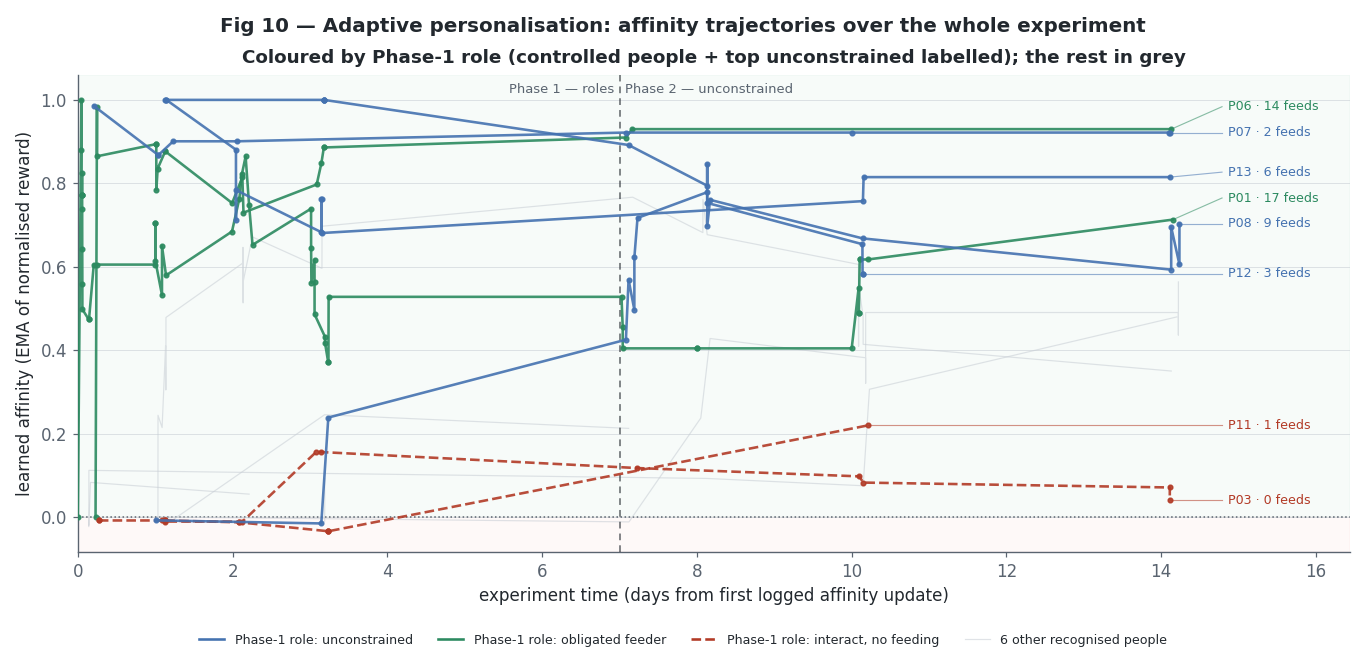

In [40]:

# Use B9's re-threaded affinity (merged identities get a single coherent EMA, not the stale
# last-label value) rather than reloading the raw per-label log.
hlc=globals()["_b9_hlc"].copy()
fig,ax=plt.subplots(figsize=(12.2,5.8))

# --- 1-D label declutter: spread label y-positions so names never overlap ---
def declutter(ys, gap, ymin, ymax):
    if len(ys)==0: return np.asarray([])
    order=np.argsort(ys); s=np.sort(np.asarray(ys,float))
    for i in range(1,len(s)):                       # push apart upward
        if s[i]-s[i-1]<gap: s[i]=s[i-1]+gap
    if s[-1]>ymax:                                  # then slide the whole stack to fit
        s-=(s[-1]-ymax)
        for i in range(len(s)-2,-1,-1):
            if s[i+1]-s[i]<gap: s[i]=s[i+1]-gap
    s=np.clip(s,ymin,ymax); out=np.empty_like(s); out[order]=s; return out

meals_by=(master.assign(fed=pd.to_numeric(master["meals_eaten_count"],errors="coerce").fillna(0))
                .groupby("user_key")["fed"].sum())
if len(hlc) and "affinity_after" in hlc.columns:
    hlc=hlc.sort_values(["person_id","timestamp_epoch"])
    # named people only: "unknown" is the unrecognised-face placeholder (no stable affinity).
    named=hlc[(hlc["person_id"]!="unknown") & hlc["affinity_after"].notna()].copy()
    named["experiment_day"]=(named["timestamp_epoch"]-named["timestamp_epoch"].min())/86400.0
    term=(named.groupby("person_id").tail(1)[["person_id","affinity_after","experiment_day"]]
          .rename(columns={"affinity_after":"terminal_affinity"}))
    order=(term.assign(meals=term["person_id"].map(meals_by).fillna(0))
              .sort_values(["terminal_affinity","meals"],ascending=[False,False])["person_id"].tolist())
    # Colour = Phase-1 ROLE (the design variable, B10), not an arbitrary rainbow.
    # Highlighted (labelled) trajectories: all controlled people + the top unconstrained
    # people by terminal affinity; remaining unconstrained people form a grey backdrop.
    named["role"]=named["person_id"].map(role_of)
    controlled=[p for p in order if named[named.person_id==p]["role"].iloc[0]!="normal"]
    top_norm=[p for p in order if p not in controlled][:4]
    highlight=controlled+top_norm; context=[p for p in order if p not in highlight]
    for pid in context:                              # backdrop: thin grey, no markers, no labels
        g=named[named["person_id"]==pid]
        ax.plot(g["experiment_day"].values,g["affinity_after"].values,
                lw=0.8,color=GRID,alpha=0.55,zorder=2)
    ends=[]                                          # (name, colour, x_end, y_end, terminal_affinity)
    for pid in highlight:
        g=named[named["person_id"]==pid]
        c=ROLE_COLOR[g["role"].iloc[0]]
        xv=g["experiment_day"].values; yv=g["affinity_after"].values
        ls="-" if g["role"].iloc[0]!="no_feed" else "--"
        ax.plot(xv,yv,marker="o",ms=3.0,lw=1.7,color=c,alpha=0.9,ls=ls,zorder=4)
        ends.append([str(pid), c, xv[-1], yv[-1], yv[-1]])
    xmax=float(named["experiment_day"].max())
    # Phase boundary: first Phase-2 learning event on the experiment-day axis.
    _p2=named[~named["day_rome"].astype(str).isin(PHASE1_DAYS)]
    if len(_p2):
        _xb=float(_p2["experiment_day"].min())-0.02
        ax.axvline(_xb,color=INK,lw=1.1,ls=(0,(4,3)),alpha=0.65,zorder=3)
        ax.text(_xb-0.07,1.01,"Phase 1 — roles",ha="right",va="bottom",fontsize=8.6,color=MUTED)
        ax.text(_xb+0.07,1.01,"Phase 2 — unconstrained",ha="left",va="bottom",fontsize=8.6,color=MUTED)
    ax.axhline(0,color=MUTED,ls=":",lw=1,zorder=1)
    # y-limits follow the DATA (affinity never went much below 0 in this deployment);
    # the old fixed [-1,1] range left the whole lower half of the figure empty.
    _ymin=min(-0.08, float(named["affinity_after"].min())-0.05)
    ax.axhspan(0,1.06,color=HS_PALETTE["HS1"],alpha=0.045,zorder=0)
    ax.axhspan(_ymin,0,color=HS_PALETTE["HS3"],alpha=0.035,zorder=0)
    # place de-collided terminal name+meal labels in a right-margin column, with leader lines
    lab_y=declutter([e[3] for e in ends], gap=0.062, ymin=_ymin+0.03, ymax=1.0)
    lx=xmax+0.55
    for (name,c,xe,ye,_),ly in zip(ends,lab_y):
        mk=int(meals_by.get(name,0))
        ax.plot([xe,lx],[ye,ly],color=c,lw=0.75,alpha=0.55,zorder=2)         # leader
        ax.text(lx+0.08,ly,f"{name} · {mk:g} feeds",va="center",ha="left",
                fontsize=8.3,color=c,fontweight="medium")
    for r in ROLE_ORDER:
        ax.plot([],[],lw=1.7,color=ROLE_COLOR[r],ls="--" if r=="no_feed" else "-",
                label=f"Phase-1 role: {ROLE_LABEL[r]}")
    if len(context):
        ax.plot([],[],lw=0.8,color=GRID,alpha=0.55,
                label=f"{len(context)} other recognised people")
    # legend outside (below): with the tightened y-range every inside corner has data
    fig.legend(loc="outside lower center",ncol=4,frameon=False,fontsize=8.3)
    ax.set_xlim(0,lx+1.65)
    ax.set_ylim(_ymin,1.06)
    ax.set_xlabel("experiment time (days from first logged affinity update)")
    ax.set_ylabel("learned affinity (EMA of normalised reward)")
    ax.set_title("Coloured by Phase-1 role (controlled people + top unconstrained labelled); the rest in grey",fontsize=12)
    ax.grid(True,axis="y")
else:
    ax.text(0.5,0.5,"no affinity trajectory data",ha="center")
fig.suptitle("Fig 10 — Adaptive personalisation: affinity trajectories over the whole experiment",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig10_affinity_trajectories"); plt.show()

**Fig 12 — Role manipulation validation (B10.1)** *(units: interaction and person-day;
217 interactions, 14 named people, 8 days; controlled roles = 2 feeders + 2 no-feed in
Phase 1)*: did the Phase-1 experimental labels produce the intended feeding behaviour, and
did it relax in Phase 2? Left: feed probability per interaction with exact 95% CIs. Right:
meals per person-day with the feeder-vs-normal Poisson-GEE rate ratios. Roles are external
experiment metadata, not robot software inputs.

  saved figures/fig12_role_validation.png + .svg


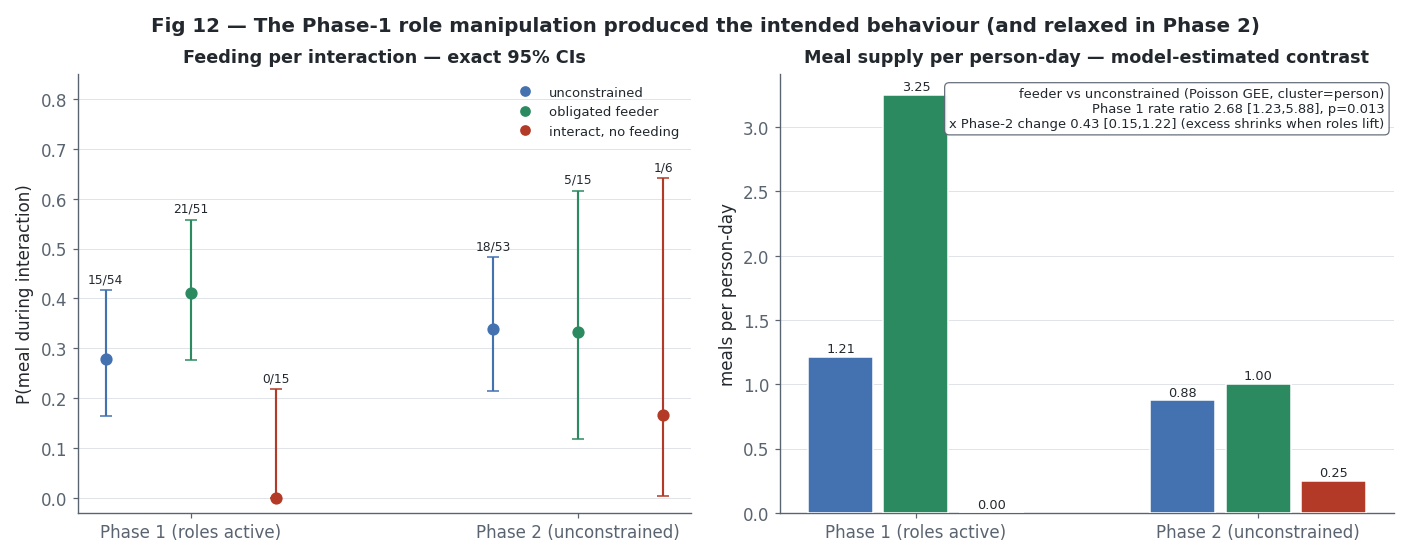

In [41]:

fig,(axL,axR)=plt.subplots(1,2,figsize=(12.6,4.9))
_d=_b10_m10[_b10_m10["role"]!="unknown"]
_x0={"P1":0.0,"P2":1.0}; _off={"normal":-0.22,"feeder":0.0,"no_feed":0.22}
for (role,ph),g in _d.groupby(["role","phase"], observed=True):
    k,n=int(g["fed"].sum()),len(g)
    lo,hi=proportion_confint(k,n,method="beta")
    x=_x0[ph]+_off[role]
    axL.errorbar(x,k/n,yerr=[[k/n-lo],[hi-k/n]],fmt="o",ms=7,color=ROLE_COLOR[role],
                 ecolor=ROLE_COLOR[role],elinewidth=1.4,capsize=4,zorder=4)
    axL.annotate(f"{k}/{n}",(x,hi),textcoords="offset points",xytext=(0,5),
                 ha="center",fontsize=8,color=INK)
axL.set_xticks([0,1]); axL.set_xticklabels(["Phase 1 (roles active)","Phase 2 (unconstrained)"])
axL.set_ylabel("P(meal during interaction)"); axL.set_ylim(-0.03,0.85)
for r in ROLE_ORDER:
    axL.plot([],[],"o",color=ROLE_COLOR[r],label=ROLE_LABEL[r])
axL.legend(loc="upper right",fontsize=8.6)
axL.set_title("Feeding per interaction — exact 95% CIs",fontsize=11.5)

_pdm=(_d.groupby(["person_id","day_rome","phase","role"],observed=True)
        .agg(meals=("meals_eaten_count","sum")).reset_index())
_bars=_pdm.groupby(["role","phase"],observed=True)["meals"].mean()
for role in ROLE_ORDER:
    for ph in ("P1","P2"):
        v=float(_bars.get((role,ph),0.0)); x=_x0[ph]+_off[role]
        axR.bar(x,v,width=0.19,color=ROLE_COLOR[role],edgecolor="white",linewidth=1.0,zorder=3)
        axR.annotate(f"{v:.2f}",(x,v),textcoords="offset points",xytext=(0,3),
                     ha="center",fontsize=8.4,color=INK)
_mg=globals()["_b10_meal_gee"]
axR.text(0.985,0.97,(f"feeder vs unconstrained (Poisson GEE, cluster=person)\n"
        f"Phase 1 rate ratio {_mg['rr']:.2f} [{_mg['ci'][0]:.2f},{_mg['ci'][1]:.2f}], p={_mg['p']:.3f}\n"
        f"x Phase-2 change {_mg['rr_p2']:.2f} [{_mg['ci_p2'][0]:.2f},{_mg['ci_p2'][1]:.2f}] "
        f"(excess shrinks when roles lift)"),
        transform=axR.transAxes,va="top",ha="right",fontsize=8.6,
        bbox=dict(boxstyle="round,pad=0.35",fc="white",ec=MUTED,lw=0.8,alpha=0.94))
axR.set_xticks([0,1]); axR.set_xticklabels(["Phase 1 (roles active)","Phase 2 (unconstrained)"])
axR.set_ylabel("meals per person-day")
axR.set_title("Meal supply per person-day — model-estimated contrast",fontsize=11.5)
fig.suptitle("Fig 12 — The Phase-1 role manipulation produced the intended behaviour (and relaxed in Phase 2)",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig12_role_validation"); plt.show()

**Fig 13 — The core RQ3 model (B10.2)** *(unit: learning update event; duration-linked
subset n ≈ 97, fully observed dose checks use all learning-eligible events n = 205)*:
engagement dose → learned affinity, moderated by external experiment role labels and phase.
Left: the raw duration-linked learning events with per-group fitted trends (descriptive).
Right: the mixed-model coefficients with 95% CIs — the inference actually reported.

  saved figures/fig13_affinity_dose.png + .svg


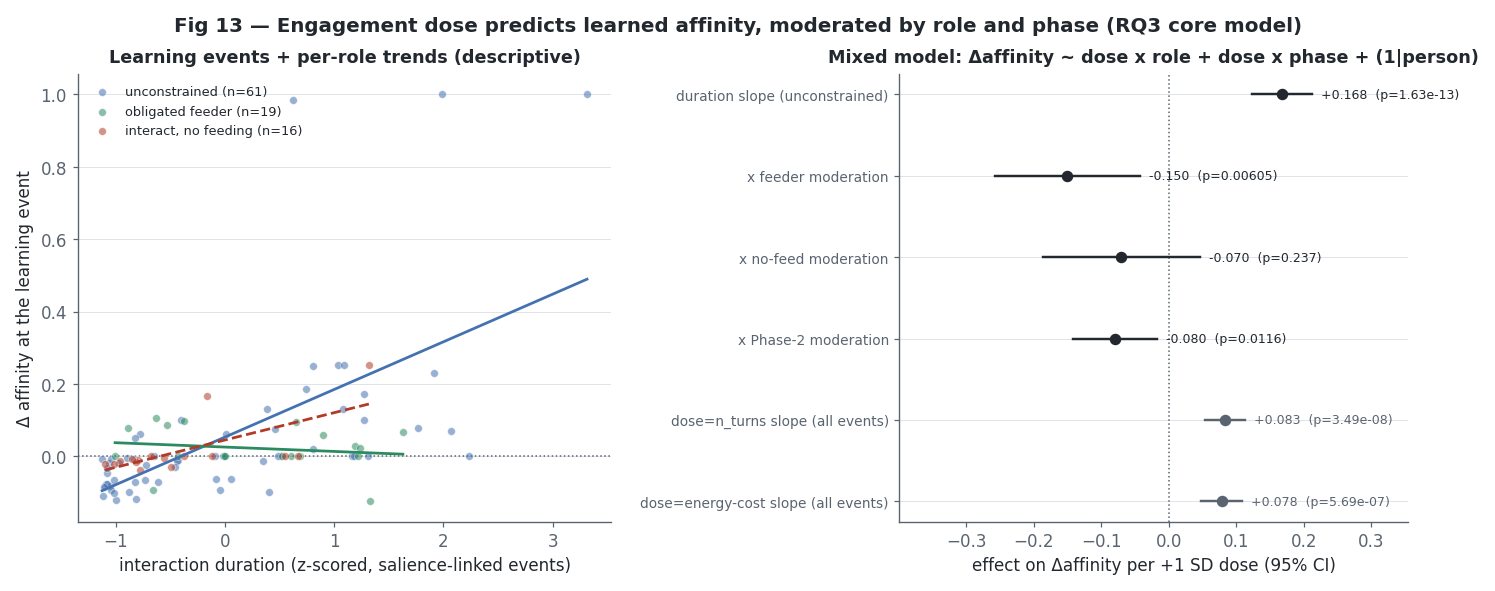

In [42]:

fig,(axL,axR)=plt.subplots(1,2,figsize=(13.2,5.2),width_ratios=[1.05,1])
_h=_b10_h10.dropna(subset=["z_duration_sec"]).copy()
for role in ROLE_ORDER:
    g=_h[_h["role"]==role]
    if not len(g): continue
    axL.scatter(g["z_duration_sec"],g["d_aff"],s=26,alpha=0.55,color=ROLE_COLOR[role],
                edgecolor="white",linewidth=0.5,zorder=3,label=f"{ROLE_LABEL[role]} (n={len(g)})")
    if len(g)>=6 and g["z_duration_sec"].std()>0:      # descriptive per-role trend line
        b1,b0=np.polyfit(g["z_duration_sec"],g["d_aff"],1)
        xs=np.linspace(g["z_duration_sec"].min(),g["z_duration_sec"].max(),20)
        axL.plot(xs,b0+b1*xs,color=ROLE_COLOR[role],lw=1.8,
                 ls="--" if role=="no_feed" else "-",zorder=4)
axL.axhline(0,color=MUTED,ls=":",lw=1)
axL.set_xlabel("interaction duration (z-scored, salience-linked events)")
axL.set_ylabel("Δ affinity at the learning event")
axL.legend(loc="upper left",fontsize=8.4)
axL.set_title("Learning events + per-role trends (descriptive)",fontsize=11.5)

# Right: MixedLM coefficients (primary model) + dose-agreement slopes.
_t=_b10_R["dur_pooled"]["table"]
_terms=[("z_duration_sec","duration slope (unconstrained)"),
        ("z_duration_sec:C(role)[T.feeder]","x feeder moderation"),
        ("z_duration_sec:C(role)[T.no_feed]","x no-feed moderation"),
        ("z_duration_sec:C(phase)[T.P2]","x Phase-2 moderation")]
_rows=[(lab,)+tuple(_t.loc[k,["coef","lo","hi","p"]]) for k,lab in _terms if k in _t.index]
for _k,_dz,_lab in [("turns_pooled","z_n_turns","dose=n_turns slope (all events)"),
                    ("cost_pooled","z_active_energy_cost","dose=energy-cost slope (all events)")]:
    _ta=_b10_R[_k]["table"]
    if _ta is not None and _dz in _ta.index:
        _rows.append((_lab,)+tuple(_ta.loc[_dz,["coef","lo","hi","p"]]))
_y=np.arange(len(_rows))[::-1]
for (lab,co,lo,hi,p),yy in zip(_rows,_y):
    _c=INK if not lab.startswith("dose=") else MUTED
    axR.plot([lo,hi],[yy,yy],color=_c,lw=1.6,zorder=3)
    axR.plot([co],[yy],"o",ms=6.5,color=_c,zorder=4)
    axR.annotate(f"{co:+.3f}  (p={p:.3g})",(hi,yy),textcoords="offset points",
                 xytext=(6,0),va="center",fontsize=8.2,color=_c)
axR.axvline(0,color=MUTED,ls=":",lw=1)
axR.set_yticks(_y); axR.set_yticklabels([r[0] for r in _rows],fontsize=9)
axR.set_xlabel("effect on Δaffinity per +1 SD dose (95% CI)")
axR.set_title("Mixed model: Δaffinity ~ dose x role + dose x phase + (1|person)",fontsize=11.5)
axR.margins(x=0.30)
fig.suptitle("Fig 13 — Engagement dose predicts learned affinity, moderated by role and phase (RQ3 core model)",
             fontsize=13,fontweight="semibold")
savefig(fig,"fig13_affinity_dose"); plt.show()

## Phase D — Machine learning (interpretive, sized to n≈200 interactions)

Regularised models with **group-aware CV** (leave-one-run-out / leave-one-person-out).
No deep learning. ML is **descriptive**; confirmatory weight sits in Phase B.

### D1 — What drives engagement (group-CV sensitivity, not full-fit explanations)

In [43]:

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.base import clone

d = master.copy()
d["replied_any"]=pd.to_numeric(d["replied_any"],errors="coerce").fillna(0).astype(int)
d["reached_ss4"]=(d["final_state"]=="ss4").astype(int)
# Phase D is scoped to the two state variables the controller actually reasons over:
# the orexigenic drive (hunger state) and the social state. The raw perceptual signals
# (IPS mean, proximity, centrality, gaze, co-presence, attention, hour, ...) are excluded.
d["hs_rank"]=d["hunger_state_start"].map({"HS1":1,"HS2":2,"HS3":3})
d["ss_rank"]=d["initial_state"].map({"ss1":1,"ss2":2,"ss3":3,"ss4":4})
HUNGER_FEATS=["hs_rank"]
SOCIAL_FEATS=["ss_rank"]
X_cols=SOCIAL_FEATS+HUNGER_FEATS
d=d.dropna(subset=["hs_rank","ss_rank"])
X=d[X_cols].fillna(d[X_cols].median())

def group_cv_oof(model, X, y, groups):
    "Out-of-fold predictions under leave-one-group-out, preserving row index."
    X = pd.DataFrame(X).copy()
    y = pd.Series(y, index=X.index).astype(int)
    groups = pd.Series(groups, index=X.index)
    oof = pd.Series(np.nan, index=X.index, dtype=float)
    n_fit = 0
    n_skip = 0
    for train_idx, test_idx in LeaveOneGroupOut().split(X, y, groups):
        if y.iloc[train_idx].nunique() < 2:
            n_skip += 1
            continue
        m = clone(model)
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        oof.iloc[test_idx] = m.predict_proba(X.iloc[test_idx])[:, 1]
        n_fit += 1
    return oof, n_fit, n_skip

def score_oof(y, oof):
    y = pd.Series(y, index=oof.index).astype(int)
    ok = oof.notna()
    if ok.sum() == 0 or y.loc[ok].nunique() < 2:
        return np.nan, np.nan
    return roc_auc_score(y.loc[ok], oof.loc[ok]), average_precision_score(y.loc[ok], oof.loc[ok])

def group_cv_scores(model, X, y, groups):
    "Out-of-fold predictions under leave-one-group-out; return AUC and PR-AUC."
    try:
        oof, _, _ = group_cv_oof(model, X, y, groups)
        return score_oof(y, oof)
    except Exception as e:
        return np.nan, np.nan

def make_models():
    return {"logit(L2)":make_pipeline(StandardScaler(),
                LogisticRegression(penalty="l2",C=0.5,max_iter=2000,class_weight="balanced")),
            "gbm":GradientBoostingClassifier(random_state=SEED)}

metric_rows=[]
for target in ["replied_any","reached_ss4"]:
    y=d[target]; base_rate=y.mean()
    print(f"\n=== target: {target}  (n={len(y)}, positives={int(y.sum())}, base rate={base_rate:.2f}) ===")
    for gname,groups in [("leave-one-run-out",d["run_id"]),("leave-one-person-out",d["user_key"])]:
        for mname,model in make_models().items():
            auc,ap=group_cv_scores(model,X,y,groups)
            lift=ap/base_rate if base_rate>0 else np.nan
            print(f"  {gname:22s} {mname:10s} AUC={auc:.2f}  PR-AUC={ap:.2f} (baseline {base_rate:.2f}, lift x{lift:.2f})")
            metric_rows.append(dict(target=target,cv=gname,model=mname,auc=auc,pr_auc=ap,
                                    baseline_pr=base_rate,n=len(y),pos=int(y.sum())))
    # majority-class baseline (AUC=0.5 by construction; PR-AUC = base rate)
    print(f"  {'majority baseline':22s} {'dummy':10s} AUC=0.50  PR-AUC={base_rate:.2f} (no signal)")

metrics_df=pd.DataFrame(metric_rows); metrics_df.to_csv(OUT_DIR/"ml_model_metrics.csv",index=False)

# --- ABLATION: does hunger_state add signal beyond the social state? ---
print("\n--- Ablation (leave-one-run-out AUC/PR-AUC): social-only vs social+hunger ---")
abl_rows=[]
for target in ["replied_any","reached_ss4"]:
    y=d[target]
    for label,cols in [("social-only",SOCIAL_FEATS),("social+hunger",X_cols)]:
        auc,ap=group_cv_scores(GradientBoostingClassifier(random_state=SEED),
                               d[cols].fillna(d[cols].median()),y,d["run_id"])
        abl_rows.append(dict(target=target,feature_set=label,auc=auc,pr_auc=ap))
        print(f"  {target:12s} {label:14s} AUC={auc:.3f}  PR-AUC={ap:.3f}")
abl=pd.DataFrame(abl_rows); abl.to_csv(OUT_DIR/"ml_ablation.csv",index=False)
delta_rows=[]
for target in ["replied_any","reached_ss4"]:
    aa=abl[abl.target==target].set_index("feature_set")
    if {"social-only","social+hunger"}.issubset(aa.index):
        delta_rows.append(dict(
            target=target,
            auc_social_only=float(aa.loc["social-only","auc"]),
            auc_social_hunger=float(aa.loc["social+hunger","auc"]),
            auc_delta=float(aa.loc["social+hunger","auc"]-aa.loc["social-only","auc"]),
            pr_auc_social_only=float(aa.loc["social-only","pr_auc"]),
            pr_auc_social_hunger=float(aa.loc["social+hunger","pr_auc"]),
            pr_auc_delta=float(aa.loc["social+hunger","pr_auc"]-aa.loc["social-only","pr_auc"]),
        ))
abl_delta=pd.DataFrame(delta_rows); abl_delta.to_csv(OUT_DIR/"ml_ablation_delta.csv",index=False)
d_auc=(abl[(abl.target=='reached_ss4')&(abl.feature_set=='social+hunger')]['auc'].iloc[0]
       - abl[(abl.target=='reached_ss4')&(abl.feature_set=='social-only')]['auc'].iloc[0])
d_ap=(abl[(abl.target=='reached_ss4')&(abl.feature_set=='social+hunger')]['pr_auc'].iloc[0]
      - abl[(abl.target=='reached_ss4')&(abl.feature_set=='social-only')]['pr_auc'].iloc[0])
print(f"  -> adding hunger_state changes Engaged AUC by {d_auc:+.3f} and PR-AUC by {d_ap:+.3f}")


=== target: replied_any  (n=217, positives=167, base rate=0.77) ===
  leave-one-run-out      logit(L2)  AUC=0.62  PR-AUC=0.79 (baseline 0.77, lift x1.03)


  leave-one-run-out      gbm        AUC=0.71  PR-AUC=0.84 (baseline 0.77, lift x1.09)
  leave-one-person-out   logit(L2)  AUC=0.63  PR-AUC=0.80 (baseline 0.77, lift x1.04)


  leave-one-person-out   gbm        AUC=0.72  PR-AUC=0.84 (baseline 0.77, lift x1.09)
  majority baseline      dummy      AUC=0.50  PR-AUC=0.77 (no signal)

=== target: reached_ss4  (n=217, positives=140, base rate=0.65) ===
  leave-one-run-out      logit(L2)  AUC=0.72  PR-AUC=0.75 (baseline 0.65, lift x1.17)


  leave-one-run-out      gbm        AUC=0.76  PR-AUC=0.81 (baseline 0.65, lift x1.26)
  leave-one-person-out   logit(L2)  AUC=0.72  PR-AUC=0.76 (baseline 0.65, lift x1.18)


  leave-one-person-out   gbm        AUC=0.74  PR-AUC=0.80 (baseline 0.65, lift x1.24)
  majority baseline      dummy      AUC=0.50  PR-AUC=0.65 (no signal)

--- Ablation (leave-one-run-out AUC/PR-AUC): social-only vs social+hunger ---


  replied_any  social-only    AUC=0.586  PR-AUC=0.782


  replied_any  social+hunger  AUC=0.711  PR-AUC=0.838


  reached_ss4  social-only    AUC=0.669  PR-AUC=0.742


  reached_ss4  social+hunger  AUC=0.757  PR-AUC=0.810
  -> adding hunger_state changes Engaged AUC by +0.088 and PR-AUC by +0.068


**Fig D1 — ML sensitivity** *(unit: interaction, n = 217; grouped CV leaves out runs/persons)*: state-rank ablation showing the additional held-out signal from hunger state beyond social state. Interpretive only, not a confirmatory mechanism test.

Out-of-fold Engaged model: AUC=0.757, PR-AUC=0.810 (10 run-held-out folds, skipped=0)



Drop-column importance (leave-one-run-out AUC/PR-AUC loss):
feature  auc_without  pr_auc_without  auc_loss  pr_auc_loss
ss_rank       0.4865          0.6312    0.2706       0.1793
hs_rank       0.6687          0.7424    0.0884       0.0681


  saved figures/figD1_ml_sensitivity.png + .svg


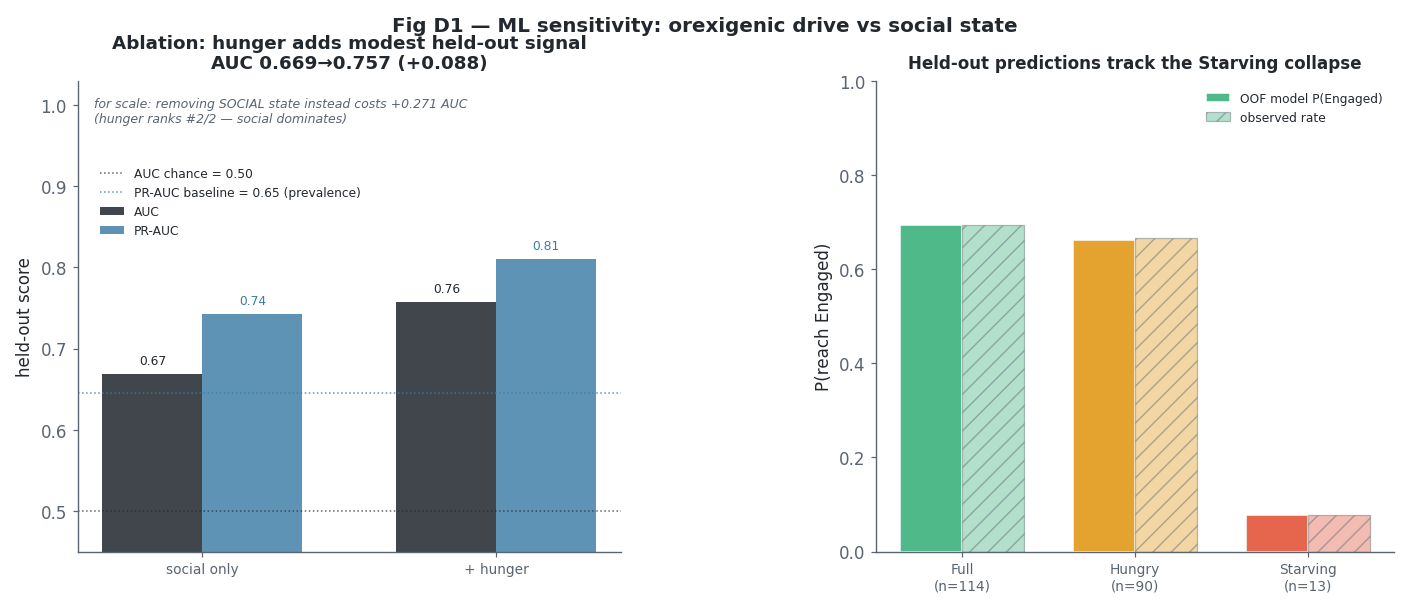

In [44]:

# --- Cross-validated sensitivity checks: no full-fit SHAP/permutation claims. ---
y=d["reached_ss4"].astype(int)
gb=GradientBoostingClassifier(random_state=SEED)
oof, n_folds, n_skip = group_cv_oof(gb, X, y, d["run_id"])
base_auc, base_ap = score_oof(y, oof)
print(f"Out-of-fold Engaged model: AUC={base_auc:.3f}, PR-AUC={base_ap:.3f} "
      f"({n_folds} run-held-out folds, skipped={n_skip})")

drop_rows=[]
for feat in X_cols:
    cols=[c for c in X_cols if c != feat]
    X_drop=d[cols].fillna(d[cols].median())
    auc_i, ap_i=group_cv_scores(gb, X_drop, y, d["run_id"])
    drop_rows.append(dict(feature=feat, auc_without=auc_i, pr_auc_without=ap_i,
                          auc_loss=base_auc-auc_i, pr_auc_loss=base_ap-ap_i))
drop_df=pd.DataFrame(drop_rows).sort_values("auc_loss",ascending=False)
drop_df.to_csv(OUT_DIR/"ml_dropcolumn_importance.csv",index=False)
hs_rank_pos=int(drop_df.reset_index(drop=True).index[drop_df["feature"].eq("hs_rank")][0]+1)
hs_auc_loss=float(drop_df.loc[drop_df.feature=="hs_rank","auc_loss"].iloc[0])
hs_ap_loss=float(drop_df.loc[drop_df.feature=="hs_rank","pr_auc_loss"].iloc[0])
print("\nDrop-column importance (leave-one-run-out AUC/PR-AUC loss):")
print(drop_df.round(4).to_string(index=False))

# Two panels. With only two features (social, hunger), the drop-column chart repeats the
# ablation numbers, so it is not drawn: its one non-redundant quantity (the AUC cost of
# removing SOCIAL state) is reported as a sentence inside the ablation panel instead.
fig=plt.figure(figsize=(12.6,5.2))
gs=fig.add_gridspec(1,2,width_ratios=[1.05,1.0],wspace=0.28)
a1=fig.add_subplot(gs[0,0]); a3=fig.add_subplot(gs[0,1])

# (1) Ablation: social state with and without hunger_state.
ab=abl[abl.target=="reached_ss4"].set_index("feature_set").loc[["social-only","social+hunger"]]
_pr_base=float(d["reached_ss4"].mean())         # PR-AUC baseline = prevalence, NOT 0.5
x=np.arange(len(ab)); w=0.34
a1.bar(x-w/2,ab["auc"],w,label="AUC",color=INK,alpha=0.86)
a1.bar(x+w/2,ab["pr_auc"],w,label="PR-AUC",color="#3A7CA5",alpha=0.82)
a1.axhline(0.5,color=INK,lw=1,ls=":",alpha=0.7,label="AUC chance = 0.50")
a1.axhline(_pr_base,color="#3A7CA5",lw=1,ls=":",alpha=0.8,label=f"PR-AUC baseline = {_pr_base:.2f} (prevalence)")
a1.set_xticks(x); a1.set_xticklabels(["social only","+ hunger"],fontsize=9)
a1.set_ylim(0.45,1.03); a1.set_ylabel("held-out score"); a1.grid(False)
a1.set_title(f"Ablation: hunger adds modest held-out signal\nAUC {ab['auc'].iloc[0]:.3f}→{ab['auc'].iloc[1]:.3f} ({d_auc:+.3f})")
a1.legend(frameon=False,fontsize=8,loc="upper left",bbox_to_anchor=(0.02,0.84))  # clear of both dotted baselines and the bars
for i,row in enumerate(ab.itertuples()):
    a1.text(i-w/2,row.auc+0.012,f"{row.auc:.2f}",ha="center",fontsize=8)
    a1.text(i+w/2,row.pr_auc+0.012,f"{row.pr_auc:.2f}",ha="center",fontsize=8,color="#3A7CA5")
ss_auc_loss=float(drop_df.loc[drop_df.feature=="ss_rank","auc_loss"].iloc[0])
a1.text(0.03,0.965,f"for scale: removing SOCIAL state instead costs {ss_auc_loss:+.3f} AUC\n"
        f"(hunger ranks #{hs_rank_pos}/{len(X_cols)} — social dominates)",
        transform=a1.transAxes,ha="left",va="top",fontsize=8.2,color=MUTED,style="italic")

# (2) Calibration-style readout by hunger state using only out-of-fold predictions.
d2=d.copy(); d2["p_ss4_oof"]=oof; d2=d2[d2["p_ss4_oof"].notna()]
by=d2.groupby("hunger_state_start").agg(
    pred=("p_ss4_oof","mean"), obs=("reached_ss4","mean"), n=("reached_ss4","size")
).reindex(HS_ORDER)
x=np.arange(len(HS_ORDER)); w=0.36
a3.bar(x-w/2,by["pred"],w,label="OOF model P(Engaged)",
       color=[HS_PALETTE[h] for h in HS_ORDER],edgecolor="white",linewidth=1.0)
a3.bar(x+w/2,by["obs"],w,label="observed rate",color=[HS_PALETTE[h] for h in HS_ORDER],
       alpha=0.43,hatch="//",edgecolor=MUTED,linewidth=0.8)
a3.set_xticks(x); a3.set_xticklabels([f"{n}\n(n={int(by.loc[h,'n']) if pd.notna(by.loc[h,'n']) else 0})"
                                      for h,n in zip(HS_ORDER,HS_NAMES)],fontsize=9)
a3.set_ylim(0,1.0); a3.set_ylabel("P(reach Engaged)"); a3.grid(False)
a3.legend(frameon=False,fontsize=8,loc="upper right")
a3.set_title("Held-out predictions track the Starving collapse",fontsize=11,pad=8)
fig.suptitle("Fig D1 — ML sensitivity: orexigenic drive vs social state",
             fontsize=13,fontweight="semibold",y=1.02)
savefig(fig,"figD1_ml_sensitivity"); plt.show()
RESULTS["D1"]={"verdict":f"adding hunger changes Engaged AUC by {d_auc:+.3f} and PR-AUC by {d_ap:+.3f}; "
               f"drop-column CV ranks hunger_state #{hs_rank_pos}/{len(X_cols)} "
               f"(AUC loss {hs_auc_loss:+.3f}, PR-AUC loss {hs_ap_loss:+.3f}). "
               f"Social state dominates, so ML is treated as sensitivity evidence, "
               f"not a confirmatory mechanism test."}

### D4 — Feeding concentration (robustness of RQ2-c)

The robustness question for RQ2-c is *does replenishment depend on a few feeders?* The
**concentration metrics (Gini, top-3 share)** answer this directly and are the whole point of
this cell. *(An earlier exploratory KMeans over per-user behaviour was dropped: its silhouette
was too low to define meaningful user types, so it added no research-grade signal.)*

In [45]:

d=master.copy()
d["fed_here"]=pd.to_numeric(d["meals_eaten_count"],errors="coerce").fillna(0)

# Feeding concentration over named users. "unknown" is an unrecognised-face placeholder,
# not a stable person, so excluding it keeps the robustness caveat interpretable.
all_meals=d[(d["user_key"]!="") & (d["user_key"]!="unknown")].groupby("user_key")["fed_here"].sum().sort_values(ascending=False)
m=np.sort(all_meals.values.astype(float)); nP=len(m)
gini=(2*np.sum(np.arange(1,nP+1)*m)/(nP*m.sum())-(nP+1)/nP) if m.sum()>0 else np.nan
top3=all_meals.head(3).sum()/max(all_meals.sum(),1)
print(f"Total meal energy into the drive = {int(all_meals.sum())} (stomach %), across {nP} named users.")
print(f"Feeding concentration: Gini={gini:.2f}; top-3 users ({', '.join(all_meals.head(3).index)}) "
      f"supply {top3*100:.0f}% of meals.")
conc = "concentrated in a few feeders (fragile)" if (top3>0.75 or gini>0.75) else \
       ("moderate concentration (a mild robustness caveat — replenishment leans on a few feeders)"
        if (top3>=0.45 or gini>=0.5) else "well spread across users (robust)")
RESULTS["D4"]={"verdict":f"Feeding Gini={gini:.2f} over {nP} named users; top-3 supply {top3*100:.0f}% "
               f"of meals — {conc}."}

Total meal energy into the drive = 76 (stomach %), across 14 named users.
Feeding concentration: Gini=0.57; top-3 users (P01, P10, P06) supply 62% of meals.


## Synthesis — success criteria, findings, checklist

### Success-criteria table (filled with Supported / Weakened / Inconclusive)

In [46]:

# Fill the outcome column from the RESULTS collected across Phase B.
def outcome_of(key):
    r = RESULTS.get(key, {})
    v = r.get("verdict","(not run)")
    tag = "Inconclusive"
    for t in ("Supported (exploratory)","Supported (directional)","Supported","Weakened","Inconclusive"):
        if v.startswith(t): tag=t; break
    return tag, v

rows = [
 ("RQ1-1","Internal monitoring continuous & autonomous","B1"),
 ("RQ1-2","Deficit detection correct (60/25 thresholds)","B2"),
 ("RQ1-3","Deficit→action conversion is real, not cosmetic","B3"),
 ("RQ1-4","Behavioural prioritisation (drive outranks social agenda)","B4"),
 ("RQ2-a","Deficit expression elicits recovery behaviour","B5"),
 ("RQ2-b","Observed Starving episodes resolve by feeding","B6"),
 ("RQ2-c","Replenishment reliable (always-on, long-run)","B7"),
 ("RQ3","Adaptive affinity reflects real behaviour (role manipulation, dose, downstream use)","B10"),
]
sc = []
for cid, claim, key in rows:
    tag, v = outcome_of(key)
    sc.append(dict(id=cid, claim=claim, source=key, outcome=tag, detail=v))
sc_df = pd.DataFrame(sc)
sc_df.to_csv(OUT_DIR / "success_criteria.csv", index=False)
print(sc_df[["id","claim","outcome"]].to_string(index=False))
print("\nDetails:")
for _, r in sc_df.iterrows():
    print(f"  [{r['outcome']:12s}] {r['id']}: {r['detail']}")

   id                                                                               claim                 outcome
RQ1-1                                         Internal monitoring continuous & autonomous               Supported
RQ1-2                                        Deficit detection correct (60/25 thresholds)               Supported
RQ1-3                                     Deficit→action conversion is real, not cosmetic               Supported
RQ1-4                           Behavioural prioritisation (drive outranks social agenda)               Supported
RQ2-a                                       Deficit expression elicits recovery behaviour               Supported
RQ2-b                                       Observed Starving episodes resolve by feeding Supported (exploratory)
RQ2-c                                        Replenishment reliable (always-on, long-run)               Supported
  RQ3 Adaptive affinity reflects real behaviour (role manipulation, dose, downstream use

### Consolidated results summary → `outputs/results_summary.md`

In [47]:

# One human-readable report tying every claim to its number, with the caveats.
L=["# Orexigenic drive — results summary", "",
   f"_Generated {datetime.now():%Y-%m-%d %H:%M}. Single always-on condition. "
   f"Unit = run (10 runs, 8 days, {len(interactions)} interactions). "
   f"Two-phase participant design: Phase 1 (first 4 days) had assigned roles "
   f"(2 obligated feeders, 2 interact-no-feed, rest unconstrained); Phase 2 (last 4 days) "
   f"unconstrained — used by B10/RQ3._",""]
L+=["## Verification gate", "", "All V1–V5 checks passed (see `verification_report.md`). "
    f"Per-action energy costs match source constants exactly; corpus energy balance "
    f"active-out {hunger_raw[hunger_raw.event_type=='active_cost'].active_energy_cost.sum():.0f} "
    f"vs meal-in {hunger_raw[hunger_raw.event_type=='feeding'].meal_delta.sum():.0f}.",""]
L+=["## Success criteria", "", "| id | claim | outcome |", "|---|---|---|"]
for _,r in sc_df.iterrows(): L.append(f"| {r['id']} | {r['claim']} | **{r['outcome']}** |")
L+=["", "## Per-analysis verdicts", ""]
for k in ["B1","B2","B3","B4","B5","B6","B7","B9","B10","D1","D4"]:
    v=RESULTS.get(k,{}).get("verdict")
    if v: L.append(f"- **{k}** — {v}")
try:
    _bh = pd.read_csv(OUT_DIR / "bh_corrected_pvalues.csv")
    _surv = _bh[_bh["sig_0.05"]]["metric"].tolist()
    _bh_line = (f"P-values come from cluster-aware models (person-clustered GEE / mixed models) and are "
                f"Benjamini–Hochberg-corrected **within two pre-declared families** (RQ1/2 behaviour; "
                f"RQ3 adaptation). **{len(_surv)}/{len(_bh)}** metrics survive at q<0.05: "
                f"{', '.join(_surv) if _surv else 'none'}. Every p-value used as evidence is inside "
                f"a declared family — including the small-n B4 Starving override, which is added to the "
                f"RQ1/2 family for honest multiplicity book-keeping but is still LED by its effect size "
                f"+ CI + bootstrap rather than by NHST. Implementation checks (B1/B2) carry no "
                f"inferential p-values by design (see `bh_corrected_pvalues.csv`).")
except Exception:
    _bh_line = "See `bh_corrected_pvalues.csv` for the Benjamini–Hochberg-corrected metric families."
L+=["", "## Multiple-comparison note", "", _bh_line, ""]
_ci=globals().get("_b7_starve_ci_block", globals().get("_b7_starve_ci",(np.nan,np.nan,np.nan)))
try:
    _d1_base = float(abl[(abl.target=="reached_ss4")&(abl.feature_set=="social-only")]["auc"].iloc[0])
    _d1_hung = float(abl[(abl.target=="reached_ss4")&(abl.feature_set=="social+hunger")]["auc"].iloc[0])
    _d1_delta = _d1_hung - _d1_base
    _d1_pr_base = float(abl[(abl.target=="reached_ss4")&(abl.feature_set=="social-only")]["pr_auc"].iloc[0])
    _d1_pr_hung = float(abl[(abl.target=="reached_ss4")&(abl.feature_set=="social+hunger")]["pr_auc"].iloc[0])
    _d1_pr_delta = _d1_pr_hung - _d1_pr_base
    _d1_line = (f"- D1 grouped-CV ablation: adding hunger changes Engaged-prediction AUC "
                f"{_d1_base:.3f}→{_d1_hung:.3f} ({_d1_delta:+.3f}) and PR-AUC "
                f"{_d1_pr_base:.3f}→{_d1_pr_hung:.3f} ({_d1_pr_delta:+.3f}); B9: affinity "
                f"learning converges and gates Hungry-state proactive pings to feeders.")
except Exception:
    _d1_line = "- D1 grouped-CV ablation: see `ml_ablation.csv`; B9: affinity learning converges and gates Hungry-state proactive pings to feeders."
_n_feed = int(hs3_episodes["received_feed"].sum())
_n_escape = int(hs3_episodes["escaped_starving_by_feeding"].sum())
_n_full = int(hs3_episodes["recovered_to_full_by_feeding"].sum())
try:
    _meal_by_hs = hunger_raw[hunger_raw["event_type"]=="feeding"].copy()
    _meal_by_hs["hs_before"] = _meal_by_hs["hunger_state_before"].fillna(_meal_by_hs["hunger_state_after"])
    _meal_means = _meal_by_hs.groupby("hs_before")["meal_delta"].mean().reindex(HS_ORDER)
    _meal_line = (f"- Meal size by deficit: Full {_meal_means.loc['HS1']:.0f} / "
                  f"Hungry {_meal_means.loc['HS2']:.0f} / Starving {_meal_means.loc['HS3']:.0f} "
                  f"(graded expression).")
except Exception:
    _meal_line = "- Meal size by deficit: see B5 feeding table (graded expression)."
L+=["## Reading of the four homeostatic functions", "",
    "- **RQ1-1 monitoring & RQ1-2 detection** are *faithful-implementation* results, not empirical "
    "measurements: the stomach level is a software integrator and the HS labels are derived from it "
    "by the same thresholds, so drain=nominal (zero-width CI) and 1.00/1.00 bracketing hold by "
    "construction. The non-trivial parts are the dense autonomous sampling and near-zero flapping.",
    "- **The drive is a two-threshold controller, not a ramp** (B3+B4 read together). At the deficit "
    "line (60, entering Hungry) the recovery repertoire turns ON (B3): being in a deficit vs Full flips "
    "hunger framing 3%->67%, activates feed-seeking acts and proactive Telegram pings (0 at Full -> 172 "
    "in deficit), and raises feeding pursuit 0.15->0.43 and meal size 21->31 — a large categorical change "
    "in what the robot does across face-to-face and remote channels. "
    "At the starving line (25) the social agenda is OVERRIDDEN (B4): conversation collapses (turns "
    "2.5->0.2, Engaged 0.68->0.08). The empirical weight is here, in RQ2-c, the D1 ablation, and B9 — "
    "not in RQ1-1/1-2.",
    "- **RQ2 — the HRI loop closes.** Across the deployment the people "
    "kept the robot fed in response to its hunger signalling, so its energy stayed in homeostasis and it "
    "was out of starvation ~99% of the time (B7). That low occupancy is the *outcome* of human engagement, "
    "not a self-property of the controller — the solution works to keep an always-on robot's energy "
    "regulated. Caveat: single condition (the drive's exact causal share in the feeding is not isolated) "
    "and feeding concentrated among a few users (D4).",""]
L+=["## Key quantities", "",
    f"- Passive drain: exactly 1.00x nominal (software integrator); dense sampling (median gap 2.3 s) "
    f"across {hunger_raw['run_id'].nunique()} monitored runs, {interactions['run_id'].nunique()} with visitors.",
    f"- Long-run Starving occupancy (RQ2-c, supporting observation): bootstrap median {_ci[1]*100:.1f}% "
    f"[95% {_ci[0]*100:.1f}, {_ci[2]*100:.1f}%] — the people kept the robot's energy in homeostasis, out "
    f"of starvation ~{100-_ci[2]*100:.0f}%+ of the time (outcome of the working HRI loop, not a controller self-property). "
    f"Stationarity caveat: a time-homogeneous CTMC pools visited/idle runs and both phases, so read this "
    f"as a conservative order-of-magnitude ceiling, not a calibrated rate (idle drain-only runs push it up).",
    f"- Observed Starving episodes: {_n_feed}/{len(hs3_episodes)} received a feed, "
    f"{_n_escape}/{len(hs3_episodes)} escaped Starving via feeding, and "
    f"{_n_full}/{len(hs3_episodes)} recovered to Full via feeding. This is exploratory; reliability is "
    f"carried by the low occupancy above (human engagement keeping the robot fed), not by these episodes "
    f"or the modest 21% ping-response rate.",
    _meal_line,
    _d1_line,]
try:
    _mg=globals()["_b10_meal_gee"]; _pr=globals()["_b10_prior"]
    _sl=globals()["_b10_R"]["dur_pooled"]["table"].loc["z_duration_sec"]
    L.append(f"- RQ3 (B10): Phase-1 manipulation validated (feeders {_mg['rr']:.1f}x meal rate "
             f"[{_mg['ci'][0]:.1f},{_mg['ci'][1]:.1f}]; no-feed pair 0 feeds); +1 SD interaction "
             f"duration -> Δaffinity {_sl['coef']:+.2f} [{_sl['lo']:+.2f},{_sl['hi']:+.2f}] "
             f"(role/phase-moderated, dose-definitions agree); prior affinity raises next-day "
             f"proactive approaches {_pr['rr']:.2f}x [{_pr['ci'][0]:.2f},{_pr['ci'][1]:.2f}] — "
             f"the adaptation reflects real behaviour and changes robot behaviour (2 people per "
             f"controlled role: validation, not population inference).")
except Exception:
    L.append("- RQ3 (B10): see notebook B10 for the role/phase validation of affinity learning.")
try:
    _scope_runs = hunger_raw['run_id'].nunique()
    _scope_people = int(hlc['person_id'].nunique()) if 'hlc' in globals() else globals().get('_b9_hlc', pd.DataFrame()).get('person_id', pd.Series(dtype=object)).nunique()
    _scope_days = hunger_raw['day_rome'].nunique() if 'day_rome' in hunger_raw.columns else 8
except Exception:
    _scope_runs, _scope_people, _scope_days = "?", "?", 8
L+=["", "## Scope & next steps", "",
    f"- **Scope of generalization.** One robot, one site, {_scope_days} session-days, "
    f"{_scope_runs} runs, {_scope_people} named people (convenience sample). Every result is a "
    f"within-deployment characterization of *this* HRI loop; none of it is a population estimate "
    f"across robots, sites, or user cohorts. Read the effect sizes as existence-and-magnitude "
    f"evidence for this system, not as calibrated rates that transfer.",
    "- **Next steps.** More people per controlled role (RQ3 currently rests on 2/role) and a "
    "multi-site replication to probe generalization."]
(OUT_DIR/"results_summary.md").write_text("\n".join(L))
print("wrote outputs/results_summary.md")

wrote outputs/results_summary.md


### Final findings vs RQ1 / RQ2 / RQ3

In [48]:

print("="*78)
print("FINDINGS — single-condition, always-on drive.")
print("="*78)
def g(k,default="(n/a)"): return RESULTS.get(k,{}).get("verdict",default)
print("\nRQ1 — Four functions of homeostasis:")
print("  (1) internal monitoring :", g("B1"))
print("  (2) deficit detection   :", g("B2"))
print("  (3) deficit→action      :", g("B3"))
print("      + active-cost table shows graded metabolic price scales with action")
print("        (conversation 3.6 >> greeting 0.8) — evidence for behavioural coupling, not a label-only effect.")
print("  (4) prioritisation      :", g("B4"))
print("\nAdaptive personalization mechanism (B9):", g("B9"))
print("\nRQ2 — Deficit expression → reliable replenishment:")
print("  (a) elicits recovery    :", g("B5"))
print("  (b) observed recovery   :", g("B6"))
print("  (c) reliability         :", g("B7"))
print("\nRQ3 — Adaptation reflects real behaviour (B10):", g("B10"))
print("\nSmall-n caveats: Starving episodes and proactive Starving interactions are single-digit;")
print("those results are DIRECTIONAL evidence, reported with n and bootstrap CIs, not proof.")

FINDINGS — single-condition, always-on drive.

RQ1 — Four functions of homeostasis:
  (1) internal monitoring : Supported (faithful implementation, not a measurement): the drive is a software integrator that self-drains at exactly 1.00x nominal (zero-width CI — the tell) and samples every 2.3s across 12 runs / 46 h, autonomously — incl. 2 runs with no visitors.
  (2) deficit detection   : Supported (faithful implementation, not a measurement): labels are derived from level by the coded 60/25 thresholds, so transitions bracket them by construction (acc 1.00/1.00); the non-trivial result is near-zero flapping (0 reversals) around the boundaries.
  (3) deficit→action      : Supported: being in a deficit categorically changes what the robot does — it switches on a proactive recovery repertoire that is silent at Full. Face-to-face hunger framing jumps 3% -> 66% (x24); feed-seeking speech acts go 1 -> 20 (deficit-only); co-present feeding pursuit 0.15 -> 0.43 with larger meals (21 -> 31); an

### Final output checklist

In [49]:

def exists(p): return "done" if (OUT_DIR/p).exists() or (FIG_DIR/p).exists() else "MISSING"
def fig_exists(n): return "done" if (FIG_DIR/f"{n}.png").exists() else "MISSING"
items = [
 ("verification_report.md", exists("verification_report.md")),
 ("quality_report.md", exists("quality_report.md")),
 ("master_interactions.parquet", exists("master_interactions.parquet")),
 ("hs3_episodes.parquet", exists("hs3_episodes.parquet")),
 ("hs_transitions.parquet", exists("hs_transitions.parquet")),
 ("active_cost_table.csv", exists("active_cost_table.csv")),
 ("success_criteria.csv", exists("success_criteria.csv")),
 ("results_summary.md", exists("results_summary.md")),
	 ("bh_corrected_pvalues.csv", exists("bh_corrected_pvalues.csv")),
	 ("small_cluster_sensitivity.csv", exists("small_cluster_sensitivity.csv")),
	 ("rq3_model_results.csv", exists("rq3_model_results.csv")),
	 ("rq3_missingness.csv", exists("rq3_missingness.csv")),
	 ("rq3_affinity_repair_robustness.csv", exists("rq3_affinity_repair_robustness.csv")),
	 ("rq3_memory_crosscheck.csv", exists("rq3_memory_crosscheck.csv")),
	 ("ml_model_metrics.csv", exists("ml_model_metrics.csv")),
	 ("ml_ablation.csv", exists("ml_ablation.csv")),
	 ("ml_ablation_delta.csv", exists("ml_ablation_delta.csv")),
	 ("ml_dropcolumn_importance.csv", exists("ml_dropcolumn_importance.csv")),
	]
for n in ["fig01_architecture","fig02_drive_timeline","fig03_thresholds_transitions",
          "fig04_deficit_action","fig05_prioritisation_heatmap",
          "fig06_ips_decomposition","fig07_hs3_funnel","fig08_remote_loop","fig09_steady_state",
          "fig10_affinity_trajectories","fig12_role_validation",
          "fig13_affinity_dose","figD1_ml_sensitivity"]:
    items.append((n, fig_exists(n)))
print("FINAL OUTPUT CHECKLIST")
for name, st in items:
    print(f"  [{'x' if st=='done' else ' '}] {name}  ({st})")
n_done=sum(1 for _,s in items if s=="done")
print(f"\n{n_done}/{len(items)} deliverables present.")
print("\nAnalyses run:", ", ".join(sorted(RESULTS.keys())))
print("Cache files:", len(list(CACHE_DIR.glob('*.parquet'))), "parquet frames in analysis/cache/")

FINAL OUTPUT CHECKLIST
  [x] verification_report.md  (done)
  [x] quality_report.md  (done)
  [x] master_interactions.parquet  (done)
  [x] hs3_episodes.parquet  (done)
  [x] hs_transitions.parquet  (done)
  [x] active_cost_table.csv  (done)
  [x] success_criteria.csv  (done)
  [x] results_summary.md  (done)
  [x] bh_corrected_pvalues.csv  (done)
  [x] small_cluster_sensitivity.csv  (done)
  [x] rq3_model_results.csv  (done)
  [x] rq3_missingness.csv  (done)
  [x] rq3_affinity_repair_robustness.csv  (done)
  [x] rq3_memory_crosscheck.csv  (done)
  [x] ml_model_metrics.csv  (done)
  [x] ml_ablation.csv  (done)
  [x] ml_ablation_delta.csv  (done)
  [x] ml_dropcolumn_importance.csv  (done)
  [x] fig01_architecture  (done)
  [x] fig02_drive_timeline  (done)
  [x] fig03_thresholds_transitions  (done)
  [x] fig04_deficit_action  (done)
  [x] fig05_prioritisation_heatmap  (done)
  [x] fig06_ips_decomposition  (done)
  [x] fig07_hs3_funnel  (done)
  [x] fig08_remote_loop  (done)
  [x] fig09_st

### Reproducibility note

Set a global seed (`SEED=42`); read-only immutable DB access; deterministic re-runs from
the parquet cache in `analysis/cache/`. Pinned dependencies are written to
`analysis/requirements.txt`. Re-running top-to-bottom regenerates every artifact under
`analysis/outputs/` and `analysis/figures/`.